In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import random
import timeit
pi = 3.1415926535898

# load coarse solutions from MC
X_train1 = np.loadtxt('FKE_X_train1.txt', dtype = np.float32, delimiter = ',')
Y_train1 = np.loadtxt('FKE_Y_train1.txt', dtype = np.float32, delimiter = ',')
X_train1_t = tf.convert_to_tensor(X_train1, dtype=tf.float32)
Y_train1_t = tf.convert_to_tensor(Y_train1, dtype=tf.float32)
Y_train1_t = tf.reshape(Y_train1_t, [len(Y_train1_t),1])

# load random grid points for PDE

X_train_no_Y = np.loadtxt('FKE_X_train_noY.txt', dtype = np.float32, delimiter = ',')
X_train_no_Y_t = tf.convert_to_tensor(X_train_no_Y, dtype=tf.float32)

# load exterior collocation points
X_train3 = np.loadtxt('FKE_X_train3.txt', dtype = np.float32, delimiter = ',')
Y_train3 = np.loadtxt('FKE_Y_train3.txt', dtype = np.float32, delimiter = ',')
X_train3_t = tf.convert_to_tensor(X_train3, dtype=tf.float32)
Y_train3_t = tf.convert_to_tensor(Y_train3, dtype=tf.float32)
Y_train3_t = tf.reshape(Y_train3_t, [len(Y_train3_t),1])

# load collocation points in between
X_train4 = np.loadtxt('FKE_X_train4.txt', dtype = np.float32, delimiter = ',')
X_train4_t = tf.convert_to_tensor(X_train4, dtype=tf.float32)

opt4 = tf.keras.optimizers.Adam(learning_rate=0.0001)

X_test = np.loadtxt('FKE_X_test1.txt', dtype = np.float32, delimiter = ',')
X_test_t = tf.convert_to_tensor(X_test, dtype=tf.float32)

# # combine inner and boundary points
# X_train_t = tf.concat([X_train_t,X_train_bd_t], axis=0)
# Y_train_t = tf.concat([Y_train_t,Y_train_bd_t], axis=0)

print(X_train1_t.shape)
print(Y_train1_t.shape)


Metal device set to: Apple M1 Max
(30000, 4)
(30000, 1)


2026-03-26 21:40:53.245317: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-26 21:40:53.245425: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [2]:
from matplotlib import pyplot as plt
from numpy import linalg as LA

pi = 3.1415926535898
gam = 0.4
T1 = 2.0
T3 = 8.0
nu = 0.2

pi = np.float32(pi)
T1 = np.float32(T1)
T3 = np.float32(T3)
nu = np.float32(nu)
gam = np.float32(gam)

def f(x):
    I1, I3, theta1, theta3 = x[...,0], x[...,1], x[...,2], x[...,3]
    g1 = gam*(T1-tf.math.pow(I1,3))
    g2 = gam*(T3-tf.math.pow(I3,3))
    g3 = tf.multiply(-I1,1+2*tf.math.cos(theta1)) - tf.multiply(2*I3,tf.math.cos(theta3))
    g4 = tf.multiply(-I3,1+2*tf.math.cos(theta3)) - tf.multiply(2*I1,tf.math.cos(theta1))
    return g1, g2, g3, g4
    
def c(x):
    I1, I3, theta1, theta3 = x[...,0], x[...,1], x[...,2], x[...,3]
    return tf.multiply(nu*I1, tf.math.sin(theta1)) + tf.multiply(nu*I3,tf.math.sin(theta3))


training_epochs = 100
batch_size = 32

#print(batches)

n_neuron_in_h1 = 16
n_neuron_in_h2 = 256
n_neuron_in_h3 = 256
n_neuron_in_h4 = 128
n_neuron_in_h5 = 32
n_neuron_in_h6 = 8
n_input = 4
n_output = 1

initializer = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)
input = tf.keras.layers.Input(shape=(n_input, ), name = 'input')
hd1 = tf.keras.layers.Dense(n_neuron_in_h1,activation=tf.keras.activations.sigmoid, kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(0.001))(input)
hd2 = tf.keras.layers.Dense(n_neuron_in_h2,activation=tf.keras.activations.sigmoid, kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(0.001))(hd1)
hd3 = tf.keras.layers.Dense(n_neuron_in_h3,activation=tf.keras.activations.sigmoid, kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(0.001))(hd2)
hd4 = tf.keras.layers.Dense(n_neuron_in_h4,activation=tf.keras.activations.sigmoid, kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(0.001))(hd3)
hd5 = tf.keras.layers.Dense(n_neuron_in_h5,activation=tf.keras.activations.sigmoid, kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(0.001))(hd4)
hd6 = tf.keras.layers.Dense(n_neuron_in_h6,activation=tf.keras.activations.sigmoid, kernel_initializer=initializer, kernel_regularizer=tf.keras.regularizers.l2(0.001))(hd5)
output = tf.keras.layers.Dense(n_output, name = 'output')(hd6)

model = tf.keras.models.Model(input,output)
opt1 = tf.keras.optimizers.Adam(learning_rate=0.001)
opt2 = tf.keras.optimizers.Adam(learning_rate=0.0002)
opt3 = tf.keras.optimizers.Adam(learning_rate=0.0004)

In [3]:
weight1 = 1
weight2 = 1
weight_total = weight1 + weight2

opt1.learning_rate.assign(0.001)

@tf.function
def pre_train(X_b, Y_b, X_e, Y_e):
    
    with tf.GradientTape() as weight_tape:
        y_pred = model(X_b, training=True)
        loss_1 = tf.reduce_mean(tf.square(Y_b - y_pred)) + 5*tf.reduce_mean(tf.math.maximum(0.0, - y_pred))

    

    
        with tf.GradientTape(persistent=True) as tape_e:
        
            tape_e.watch(X_e)
            y_pred = model(X_e, training=True)
            y_pred_t = tf.transpose(y_pred)                      
            grad_u = tape_e.gradient(y_pred_t, X_e)
            row_norms = tf.norm(grad_u, axis=1)
        loss_3 = tf.reduce_mean(tf.square(Y_e - y_pred)) + tf.reduce_mean(row_norms) 
    


        Loss = (weight1/weight_total)*loss_1 + (weight2/weight_total)*loss_3
    grads = weight_tape.gradient(Loss, model.trainable_weights)
    opt1.apply_gradients(zip(grads, model.trainable_weights))
    

    
    return Loss



2026-03-23 22:12:25.620198: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


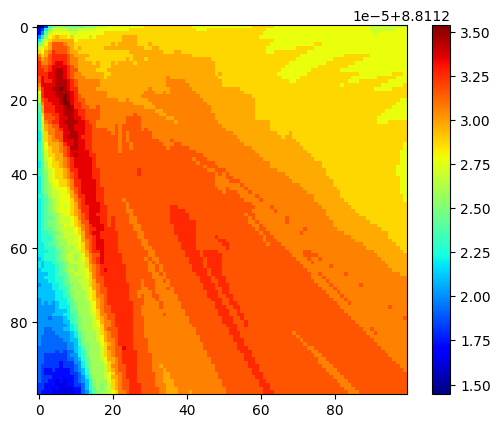

Epoch 0000  loss over 1250  batches  Loss = 263.87664795


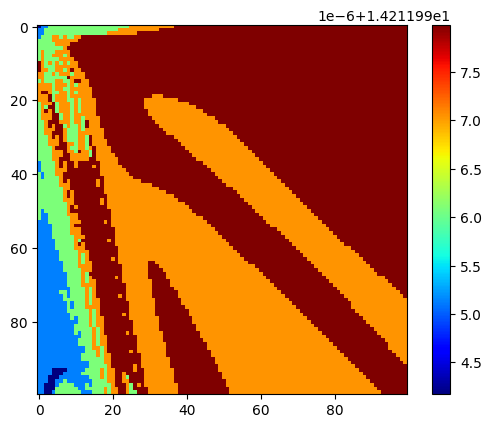

Epoch 0001  loss over 1250  batches  Loss = 117.58563995


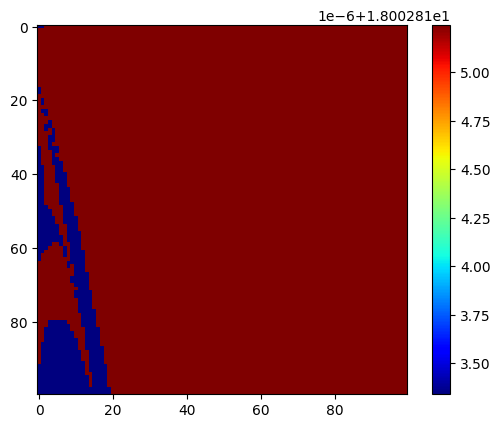

Epoch 0002  loss over 1250  batches  Loss = 57.23403549


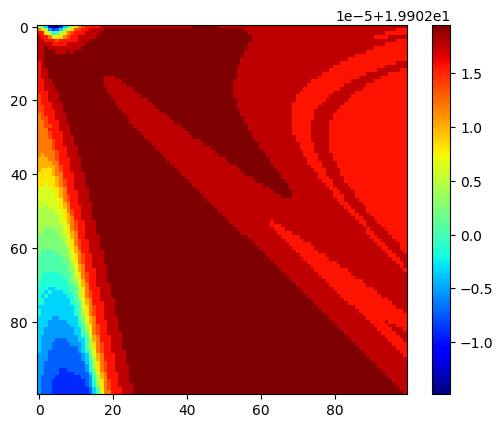

Epoch 0003  loss over 1250  batches  Loss = 41.24654388


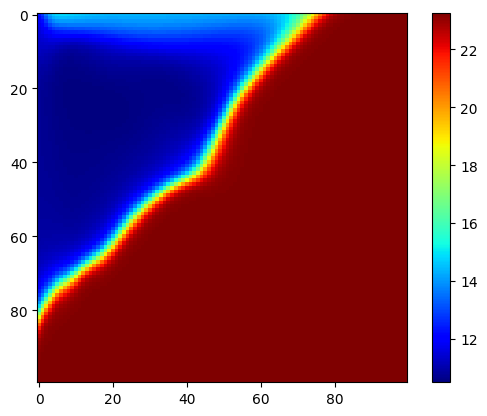

Epoch 0004  loss over 1250  batches  Loss = 26.04839516


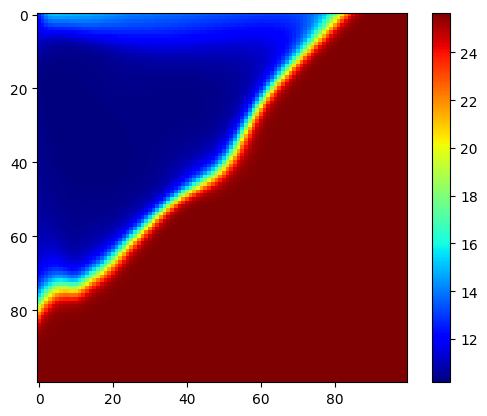

Epoch 0005  loss over 1250  batches  Loss = 2.02886915


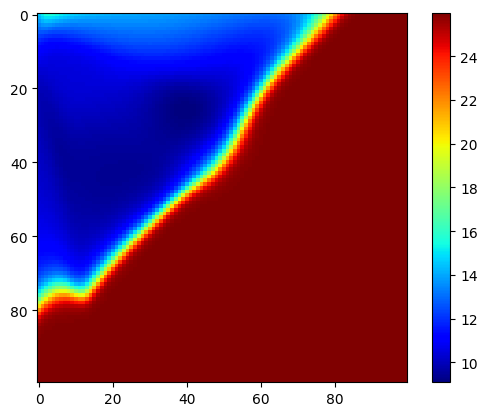

Epoch 0006  loss over 1250  batches  Loss = 0.54198444


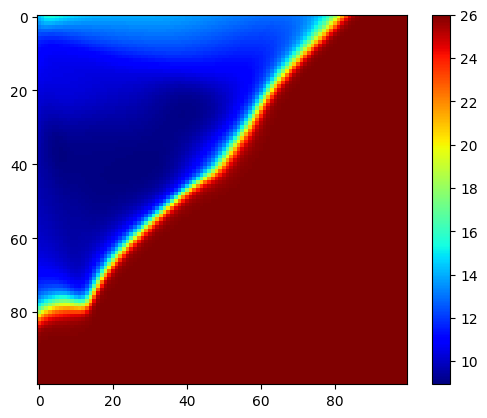

Epoch 0007  loss over 1250  batches  Loss = 0.33579448


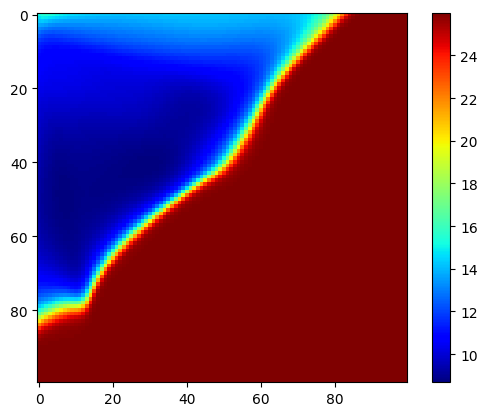

Epoch 0008  loss over 1250  batches  Loss = 0.24371932


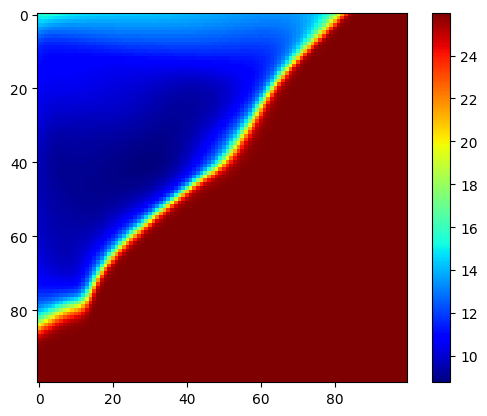

Epoch 0009  loss over 1250  batches  Loss = 0.19143844


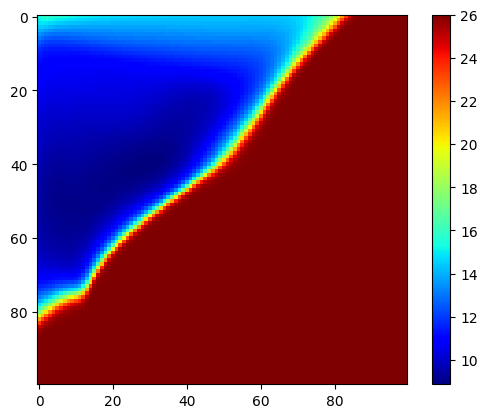

Epoch 0010  loss over 1250  batches  Loss = 0.16287395


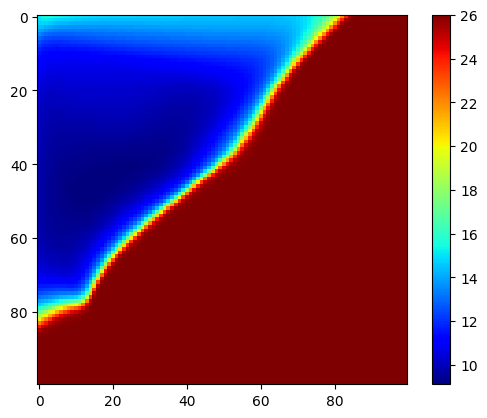

Epoch 0011  loss over 1250  batches  Loss = 0.13057317


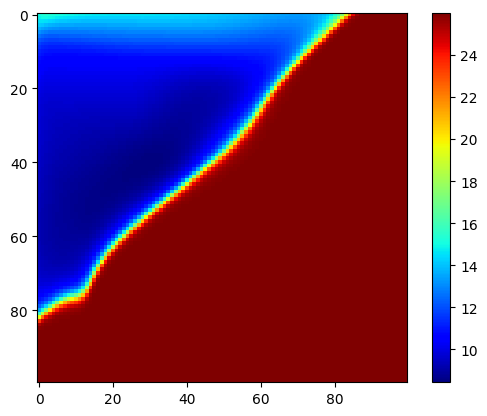

Epoch 0012  loss over 1250  batches  Loss = 0.11640151


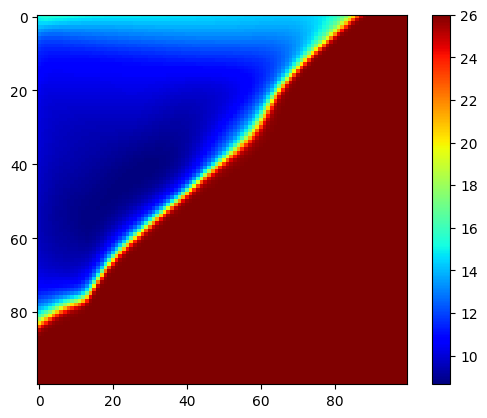

Epoch 0013  loss over 1250  batches  Loss = 0.10146429


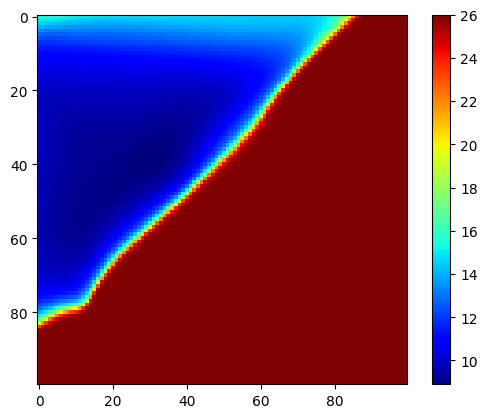

Epoch 0014  loss over 1250  batches  Loss = 0.08409253


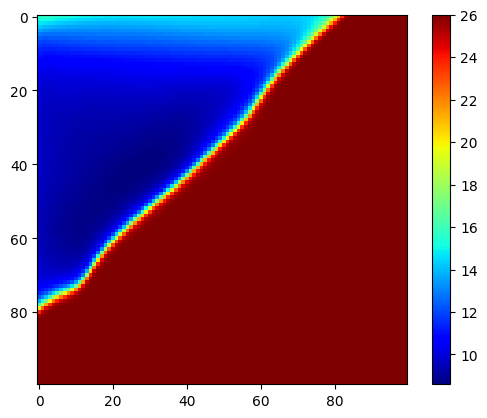

Epoch 0015  loss over 1250  batches  Loss = 0.08244153


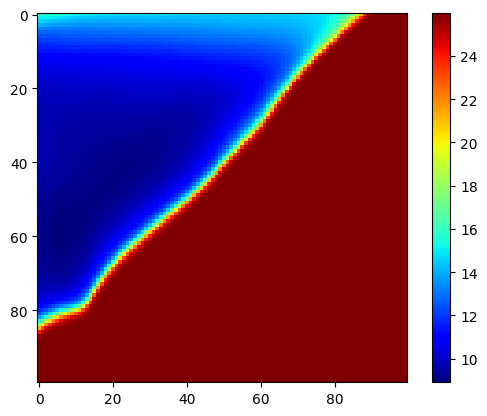

Epoch 0016  loss over 1250  batches  Loss = 0.07277502


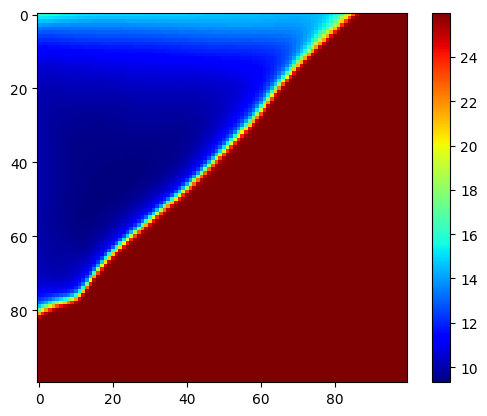

Epoch 0017  loss over 1250  batches  Loss = 0.08147831


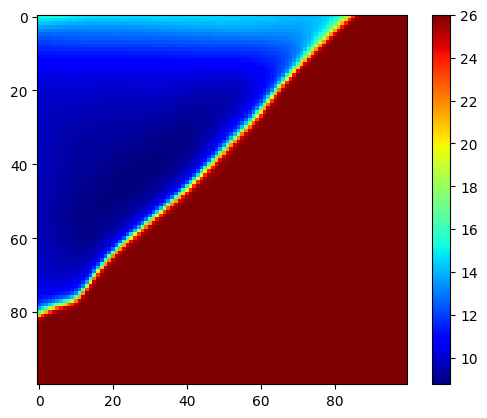

Epoch 0018  loss over 1250  batches  Loss = 0.06167220


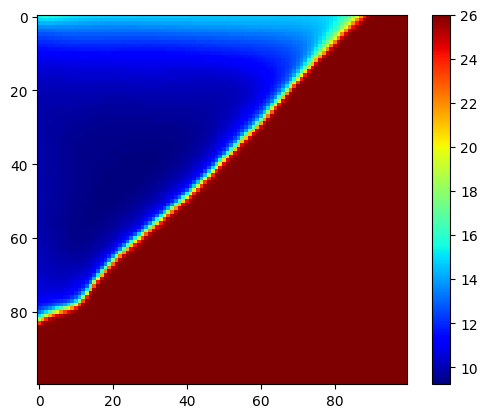

Epoch 0019  loss over 1250  batches  Loss = 0.06292721


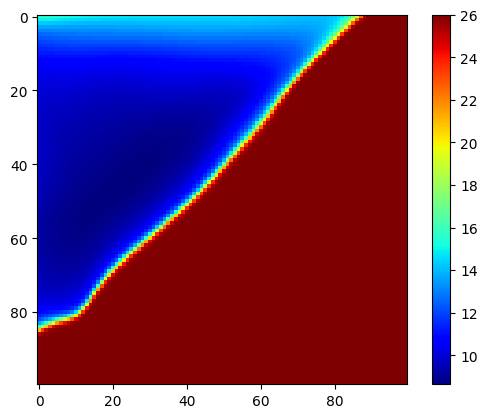

Epoch 0020  loss over 1250  batches  Loss = 0.05365255


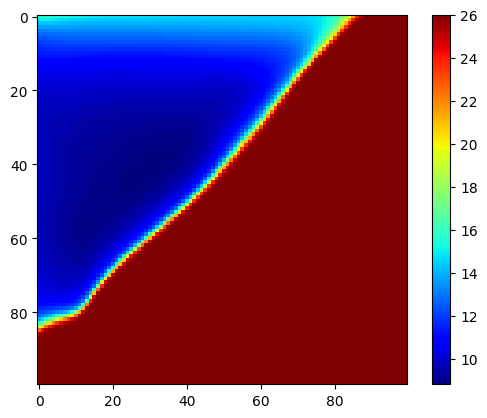

Epoch 0021  loss over 1250  batches  Loss = 0.05001007


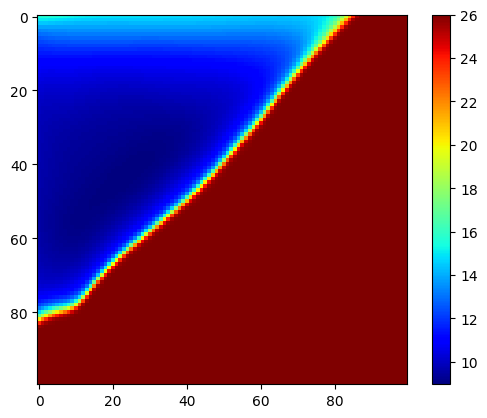

Epoch 0022  loss over 1250  batches  Loss = 0.05934235


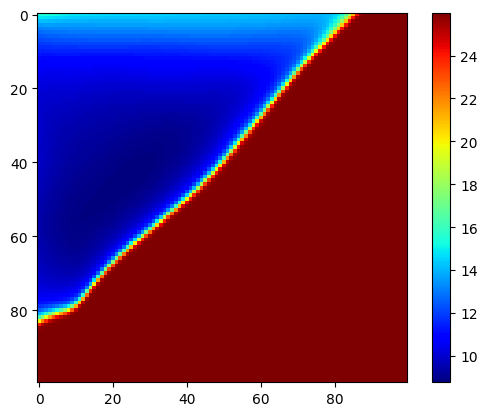

Epoch 0023  loss over 1250  batches  Loss = 0.04606880


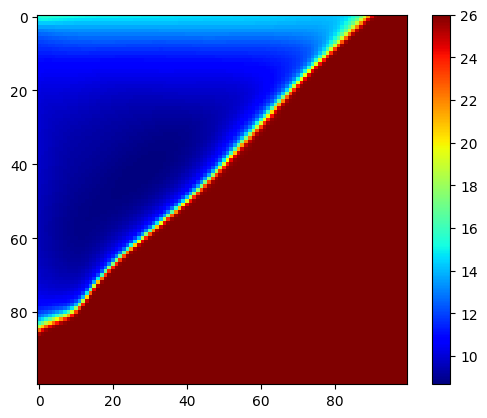

Epoch 0024  loss over 1250  batches  Loss = 0.04898426


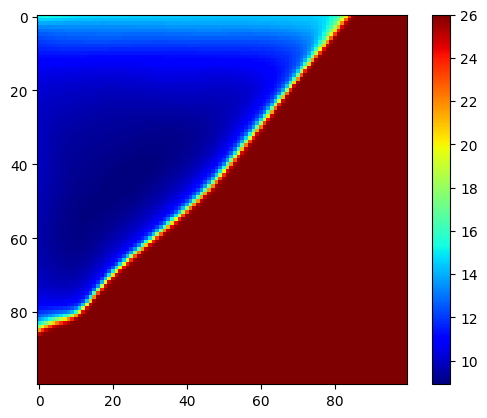

Epoch 0025  loss over 1250  batches  Loss = 0.04199433


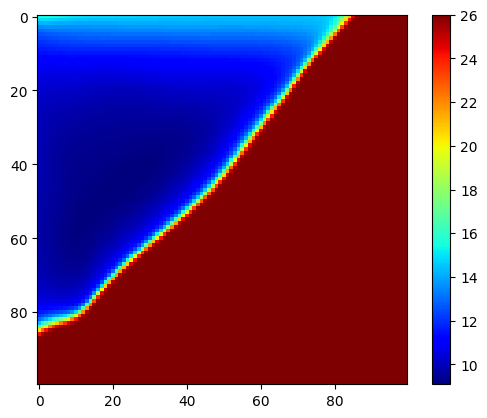

Epoch 0026  loss over 1250  batches  Loss = 0.04166882


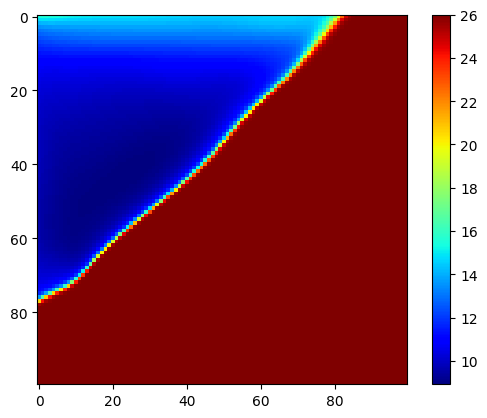

Epoch 0027  loss over 1250  batches  Loss = 0.06709955


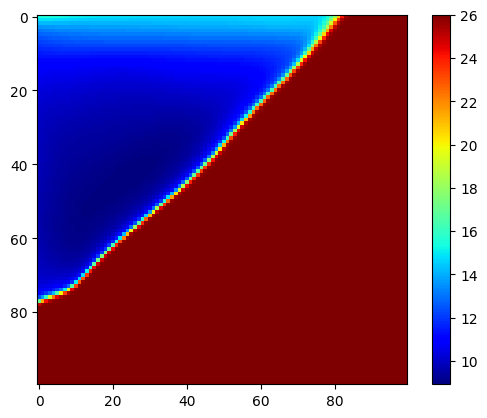

Epoch 0028  loss over 1250  batches  Loss = 0.03516481


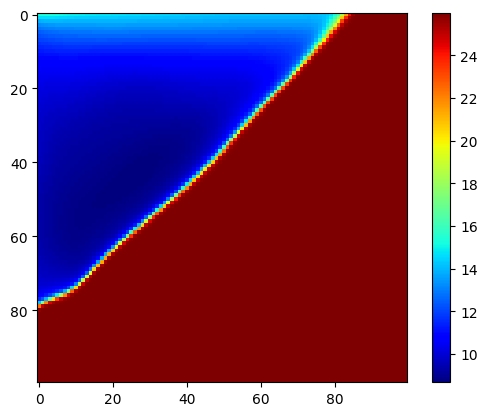

Epoch 0029  loss over 1250  batches  Loss = 0.03898454


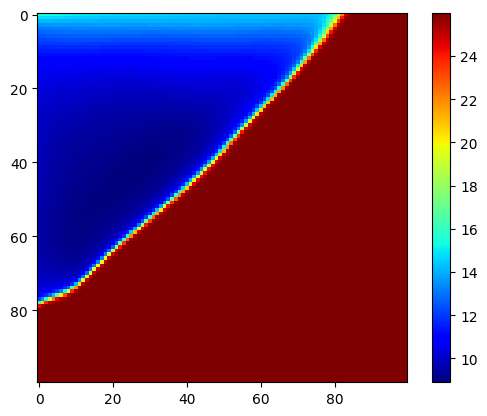

Epoch 0030  loss over 1250  batches  Loss = 0.03734654


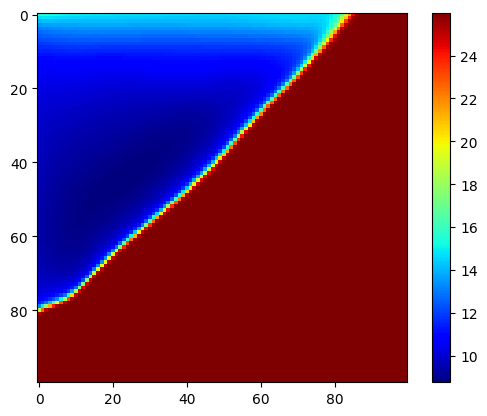

Epoch 0031  loss over 1250  batches  Loss = 0.03457887


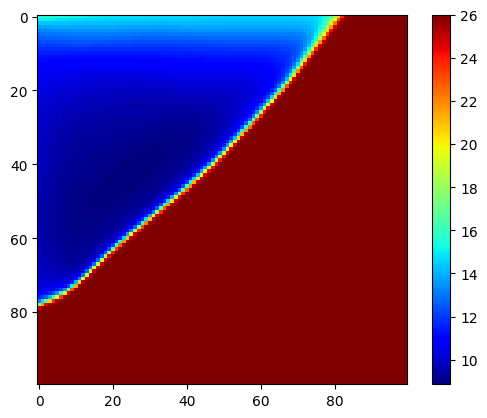

Epoch 0032  loss over 1250  batches  Loss = 0.03607863


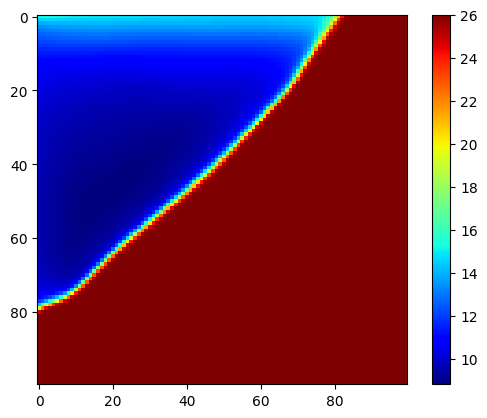

Epoch 0033  loss over 1250  batches  Loss = 0.03589899


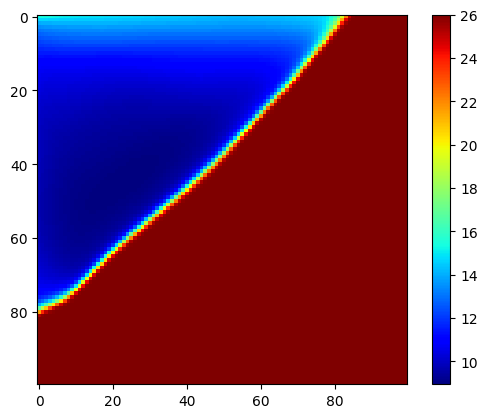

Epoch 0034  loss over 1250  batches  Loss = 0.03295889


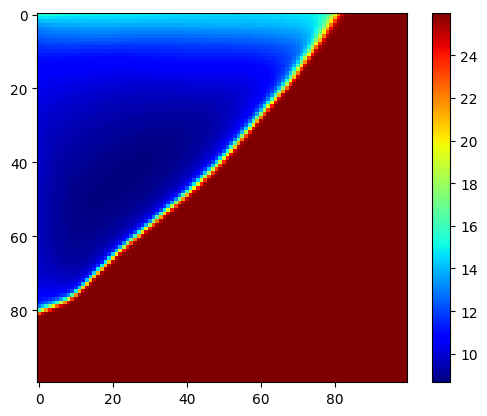

Epoch 0035  loss over 1250  batches  Loss = 0.03357764


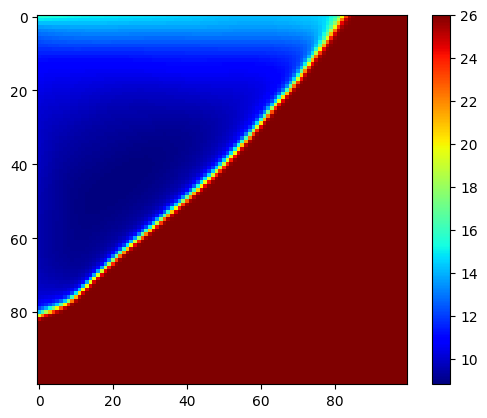

Epoch 0036  loss over 1250  batches  Loss = 0.03044177


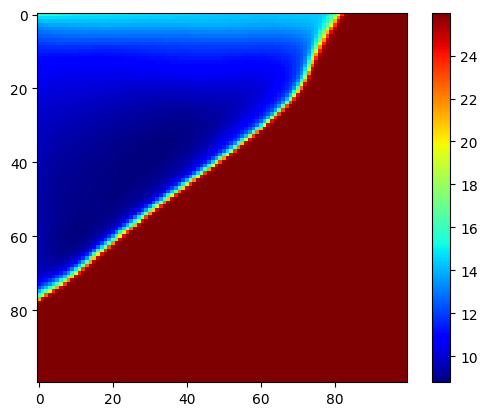

Epoch 0037  loss over 1250  batches  Loss = 0.07102665


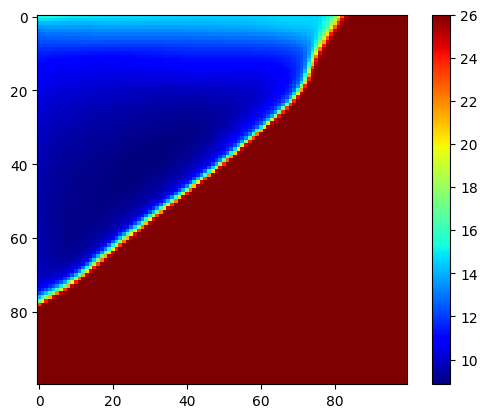

Epoch 0038  loss over 1250  batches  Loss = 0.02399291


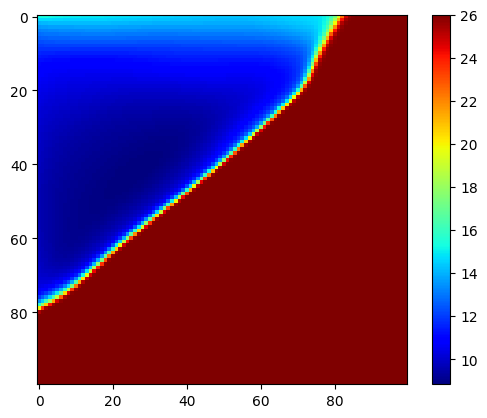

Epoch 0039  loss over 1250  batches  Loss = 0.02833697


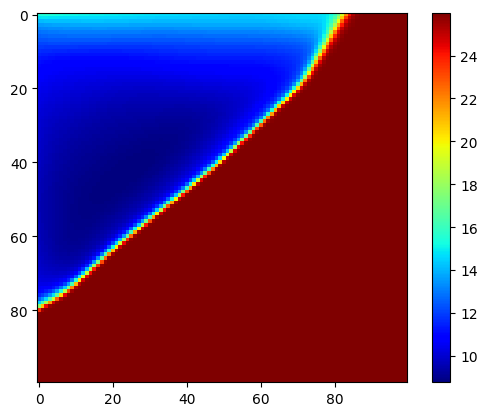

Epoch 0040  loss over 1250  batches  Loss = 0.03231450


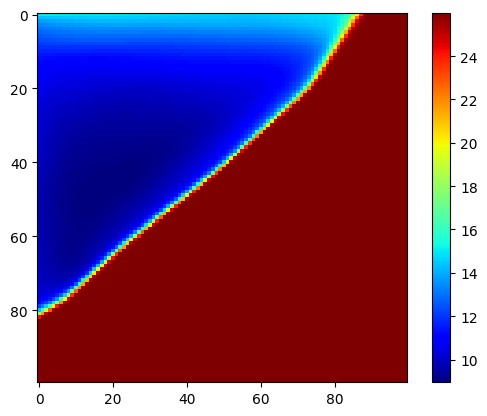

Epoch 0041  loss over 1250  batches  Loss = 0.02991179


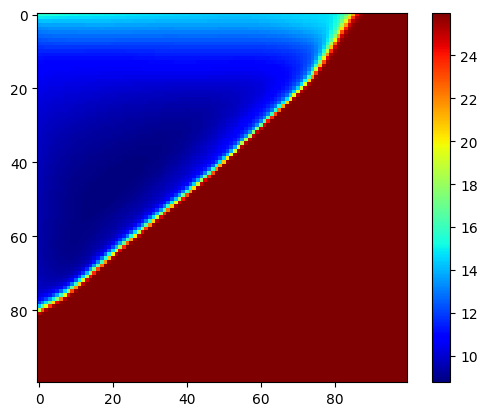

Epoch 0042  loss over 1250  batches  Loss = 0.03007597


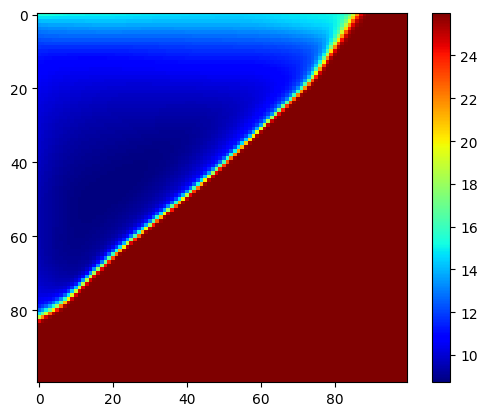

Epoch 0043  loss over 1250  batches  Loss = 0.02563813


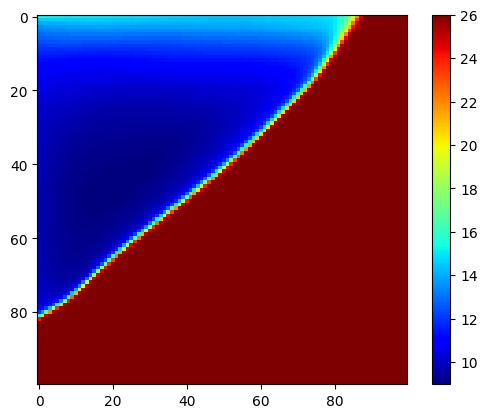

Epoch 0044  loss over 1250  batches  Loss = 0.03103911


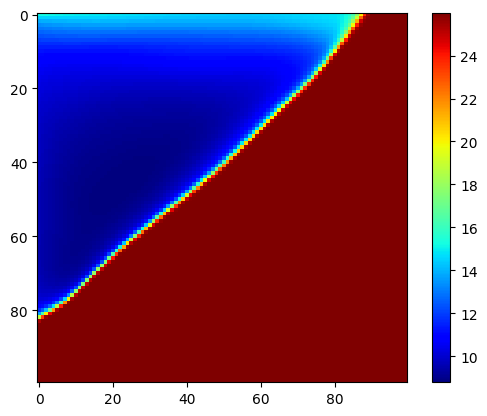

Epoch 0045  loss over 1250  batches  Loss = 0.02586111


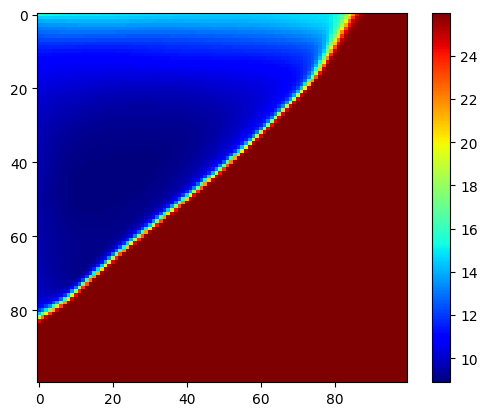

Epoch 0046  loss over 1250  batches  Loss = 0.02910884


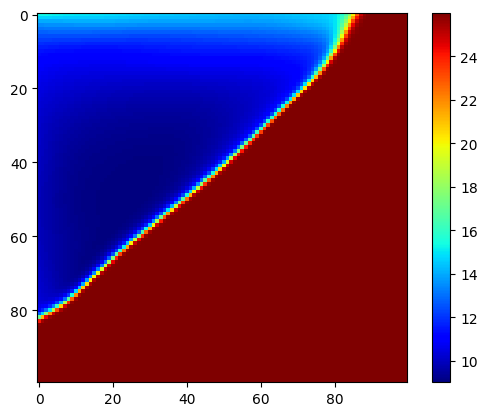

Epoch 0047  loss over 1250  batches  Loss = 0.02641391


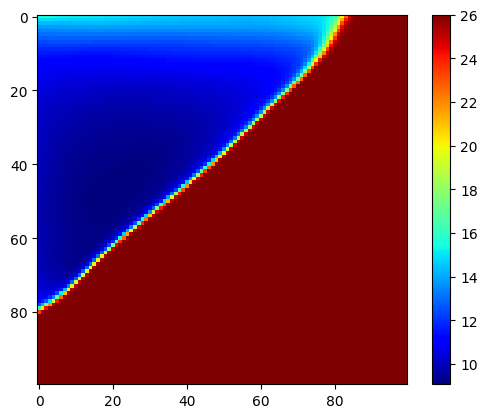

Epoch 0048  loss over 1250  batches  Loss = 0.02679282


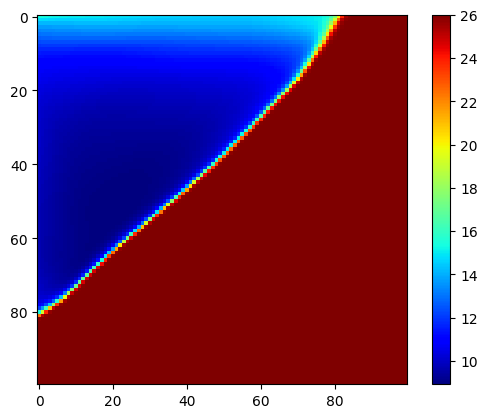

Epoch 0049  loss over 1250  batches  Loss = 0.02687863


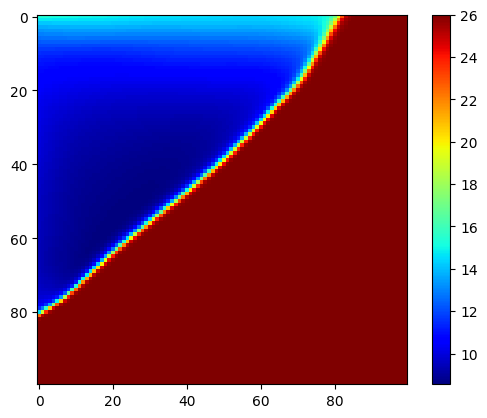

Epoch 0050  loss over 1250  batches  Loss = 0.02402392


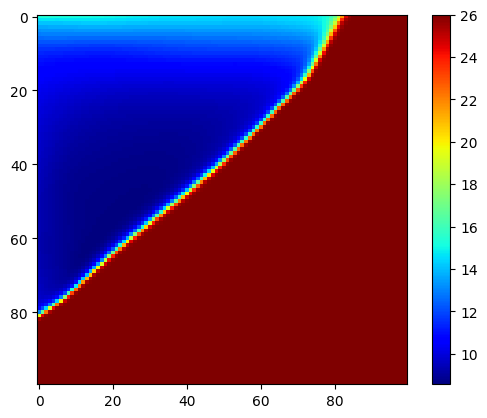

Epoch 0051  loss over 1250  batches  Loss = 0.02778268


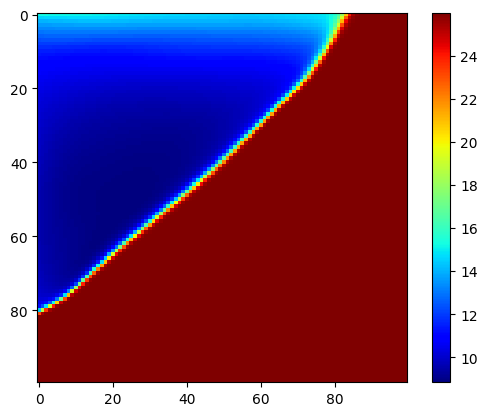

Epoch 0052  loss over 1250  batches  Loss = 0.02238194


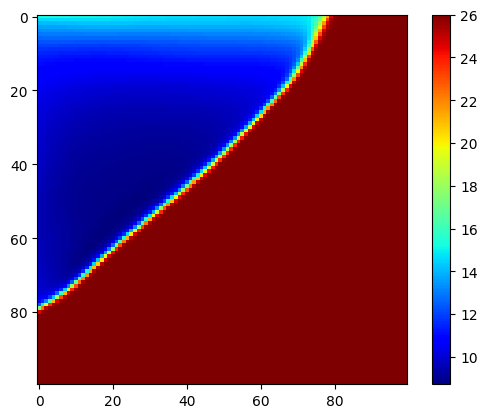

Epoch 0053  loss over 1250  batches  Loss = 0.02570939


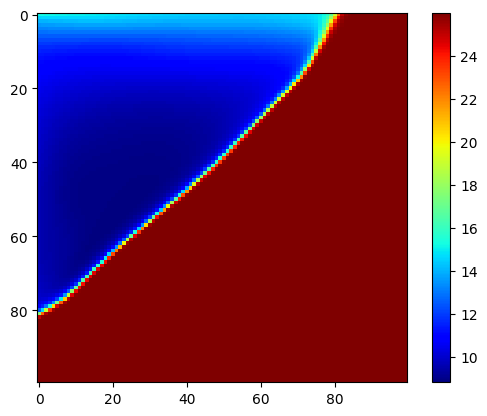

Epoch 0054  loss over 1250  batches  Loss = 0.02360470


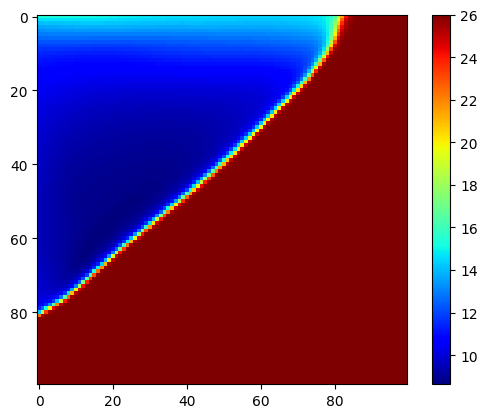

Epoch 0055  loss over 1250  batches  Loss = 0.02172820


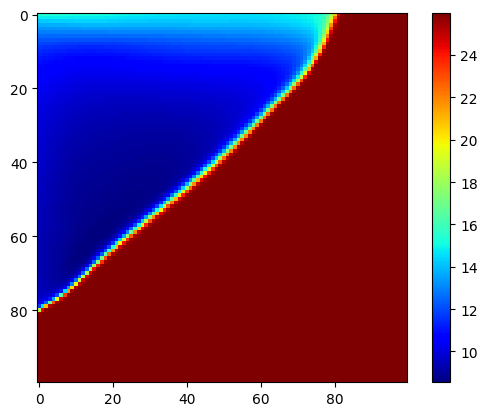

Epoch 0056  loss over 1250  batches  Loss = 0.02622046


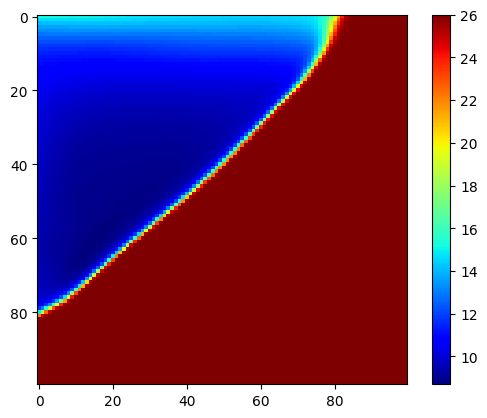

Epoch 0057  loss over 1250  batches  Loss = 0.02167491


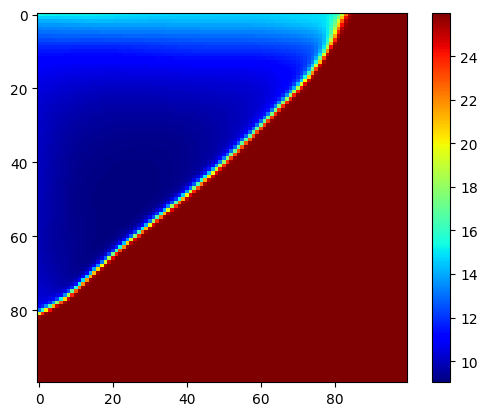

Epoch 0058  loss over 1250  batches  Loss = 0.02375695


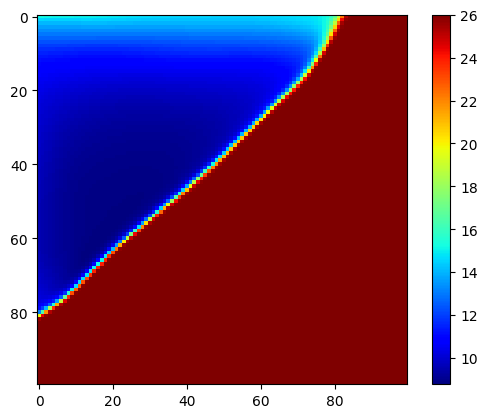

Epoch 0059  loss over 1250  batches  Loss = 0.02047883


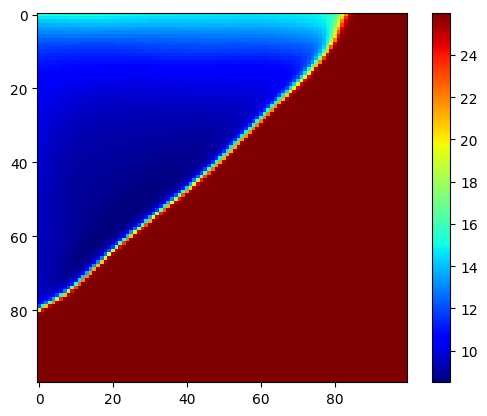

Epoch 0060  loss over 1250  batches  Loss = 0.02229070


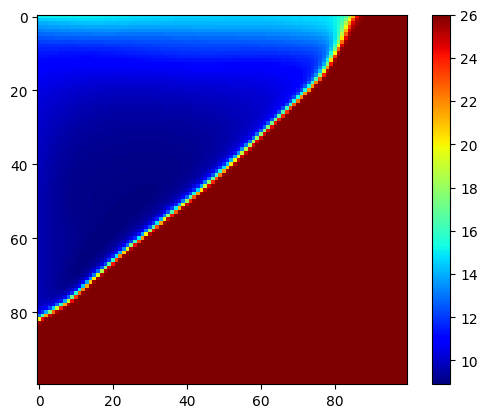

Epoch 0061  loss over 1250  batches  Loss = 0.02033726


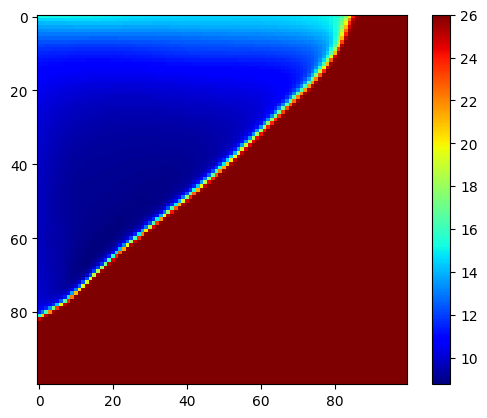

Epoch 0062  loss over 1250  batches  Loss = 0.02213653


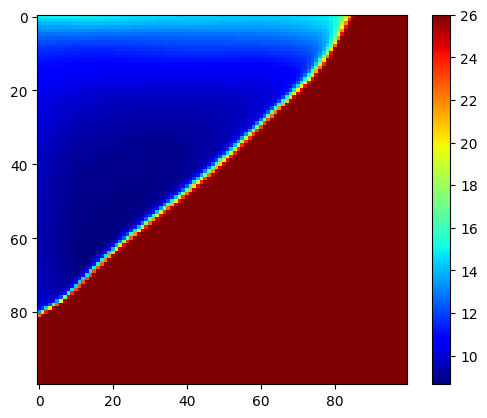

Epoch 0063  loss over 1250  batches  Loss = 0.02033509


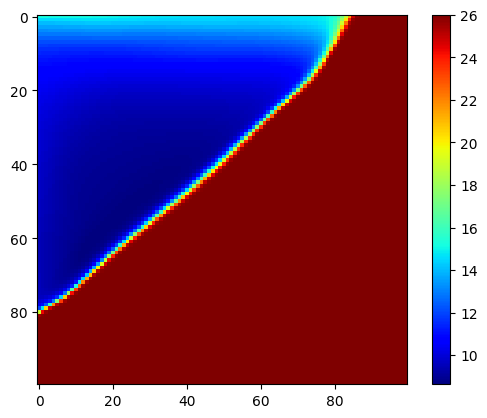

Epoch 0064  loss over 1250  batches  Loss = 0.02098828


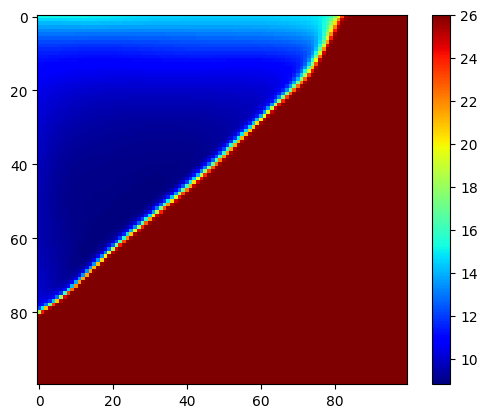

Epoch 0065  loss over 1250  batches  Loss = 0.02187803


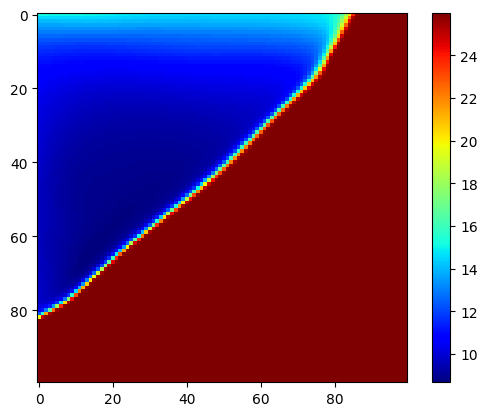

Epoch 0066  loss over 1250  batches  Loss = 0.02033944


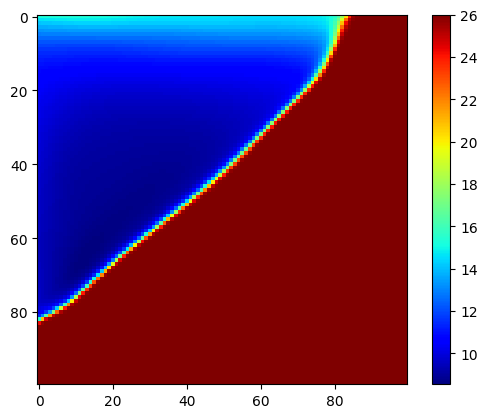

Epoch 0067  loss over 1250  batches  Loss = 0.01917466


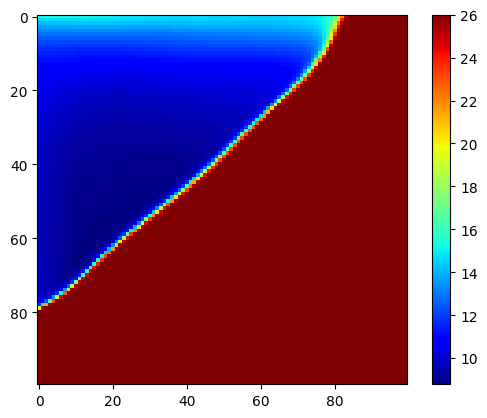

Epoch 0068  loss over 1250  batches  Loss = 0.02039493


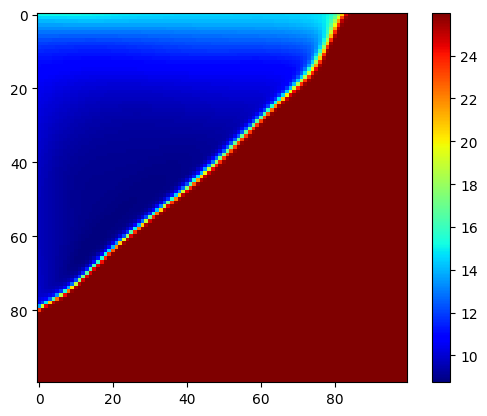

Epoch 0069  loss over 1250  batches  Loss = 0.02254192


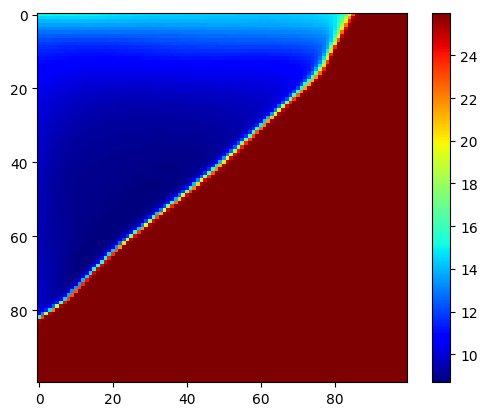

Epoch 0070  loss over 1250  batches  Loss = 0.01808417


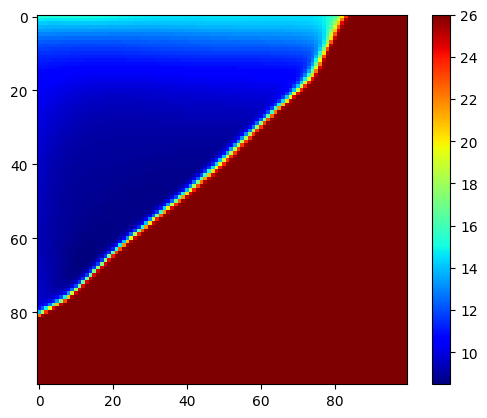

Epoch 0071  loss over 1250  batches  Loss = 0.02075210


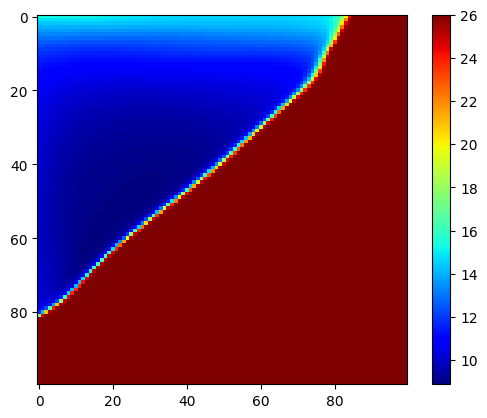

Epoch 0072  loss over 1250  batches  Loss = 0.02067168


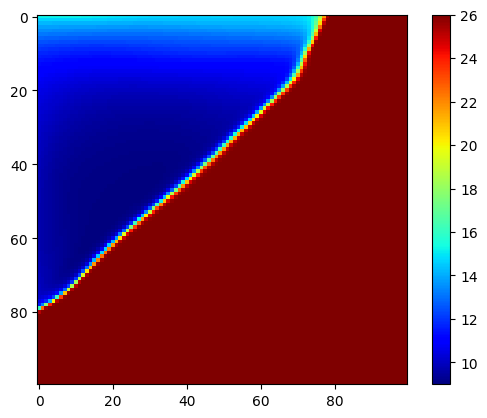

Epoch 0073  loss over 1250  batches  Loss = 0.02013421


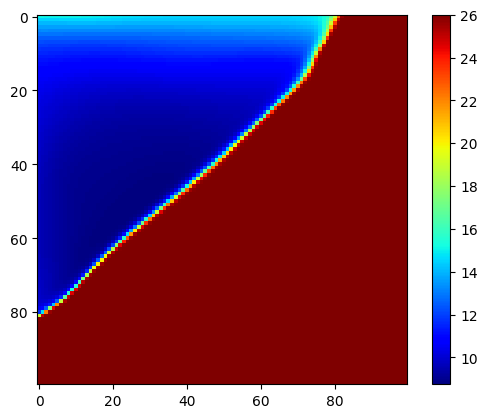

Epoch 0074  loss over 1250  batches  Loss = 0.01864119


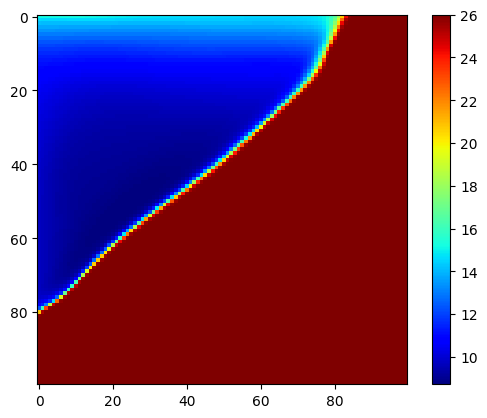

Epoch 0075  loss over 1250  batches  Loss = 0.02118634


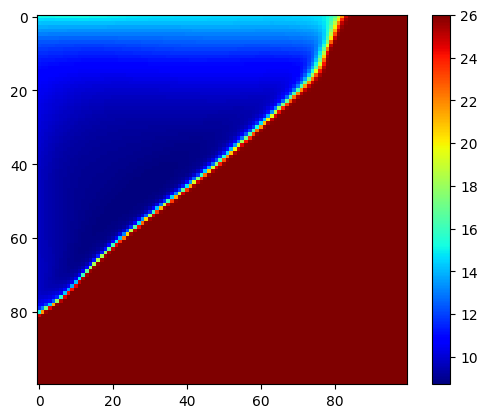

Epoch 0076  loss over 1250  batches  Loss = 0.01782631


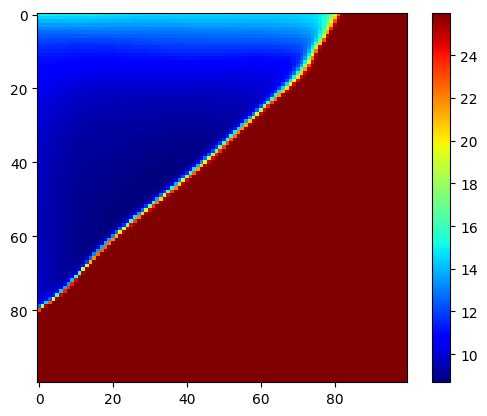

Epoch 0077  loss over 1250  batches  Loss = 0.01836635


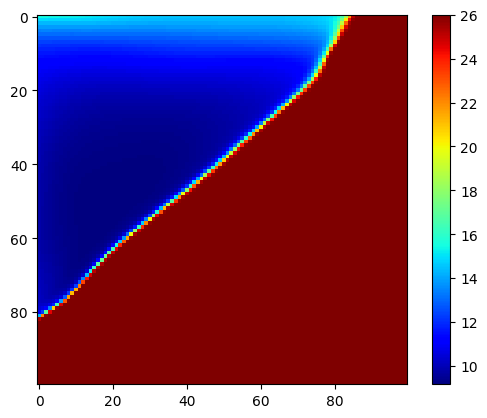

Epoch 0078  loss over 1250  batches  Loss = 0.02045788


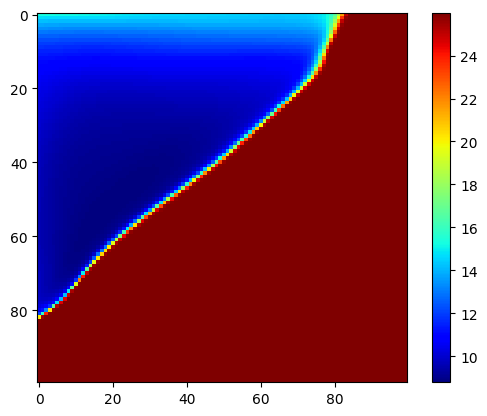

Epoch 0079  loss over 1250  batches  Loss = 0.01759152


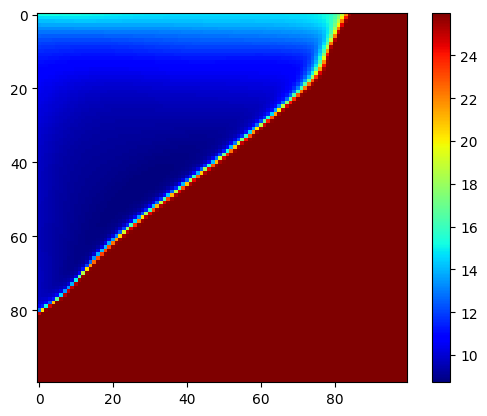

Epoch 0080  loss over 1250  batches  Loss = 0.01680830


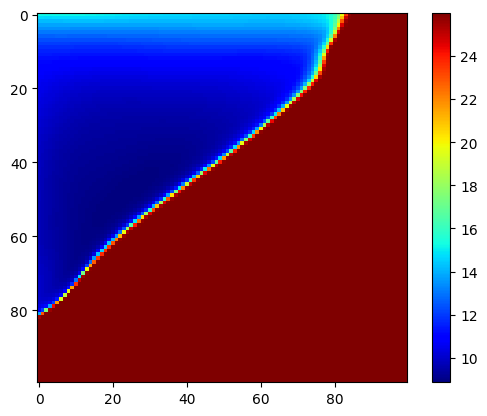

Epoch 0081  loss over 1250  batches  Loss = 0.01921801


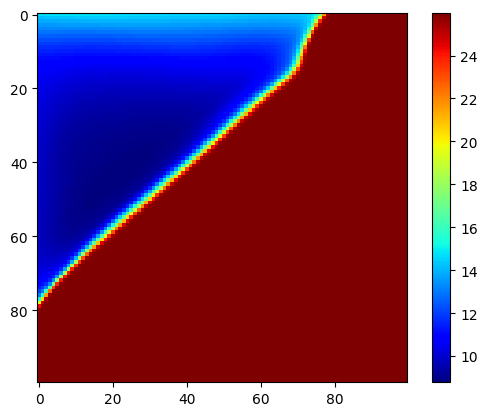

Epoch 0082  loss over 1250  batches  Loss = 0.08073382


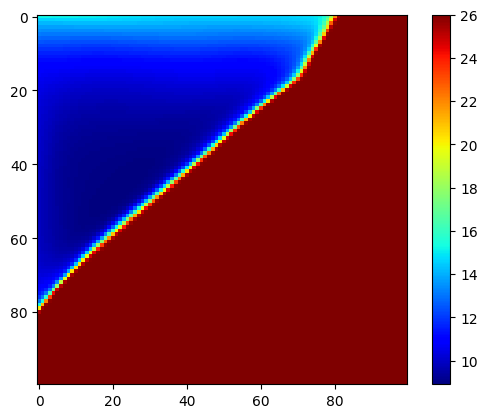

Epoch 0083  loss over 1250  batches  Loss = 0.02230519


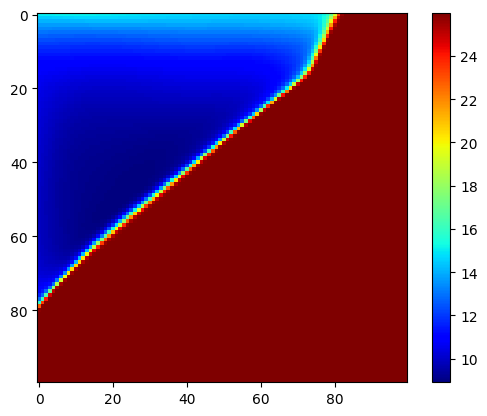

Epoch 0084  loss over 1250  batches  Loss = 0.02051102


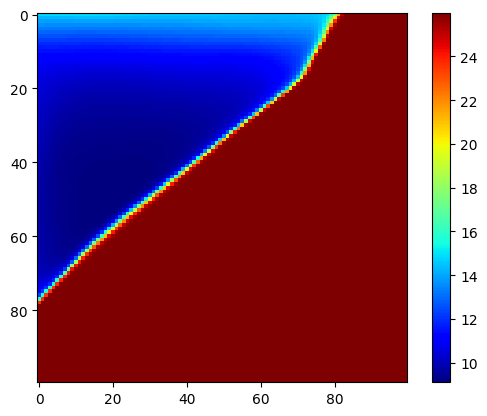

Epoch 0085  loss over 1250  batches  Loss = 0.01855913


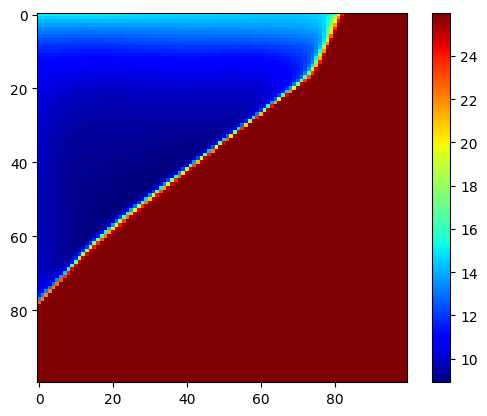

Epoch 0086  loss over 1250  batches  Loss = 0.02042924


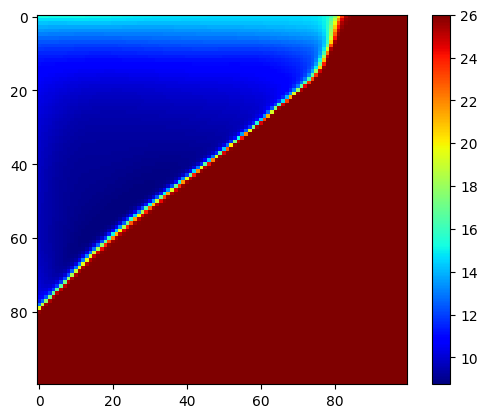

Epoch 0087  loss over 1250  batches  Loss = 0.01841653


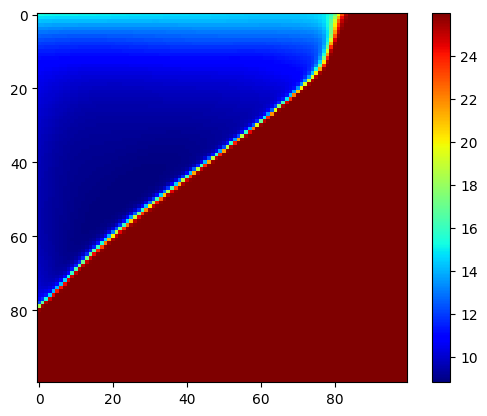

Epoch 0088  loss over 1250  batches  Loss = 0.01894779


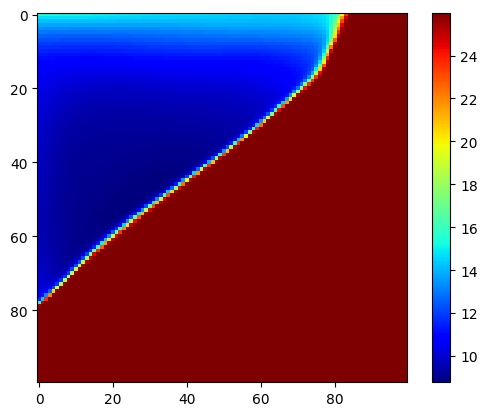

Epoch 0089  loss over 1250  batches  Loss = 0.01792873


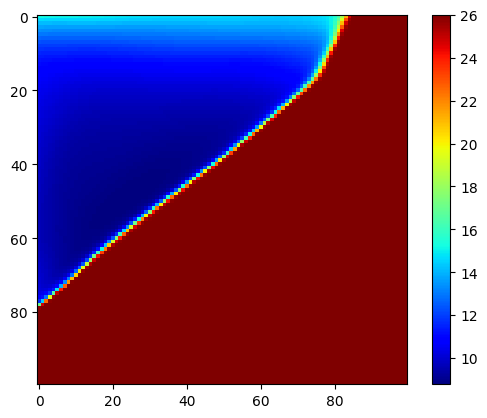

Epoch 0090  loss over 1250  batches  Loss = 0.01899741


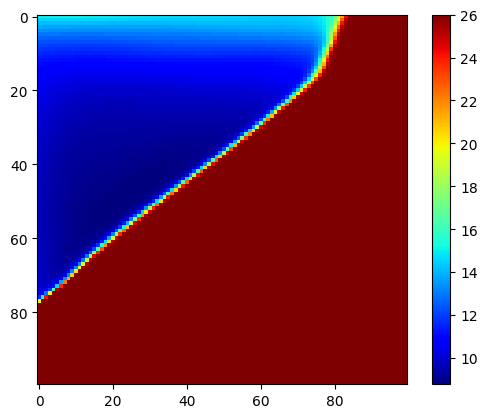

Epoch 0091  loss over 1250  batches  Loss = 0.01748285


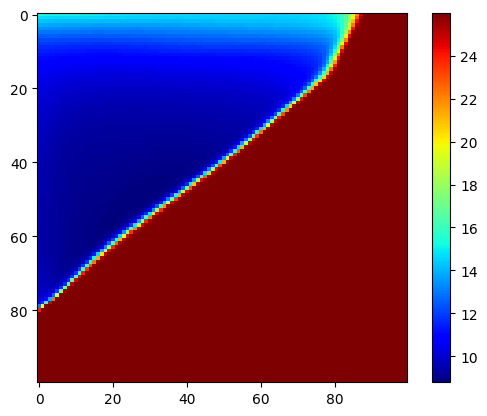

Epoch 0092  loss over 1250  batches  Loss = 0.01823083


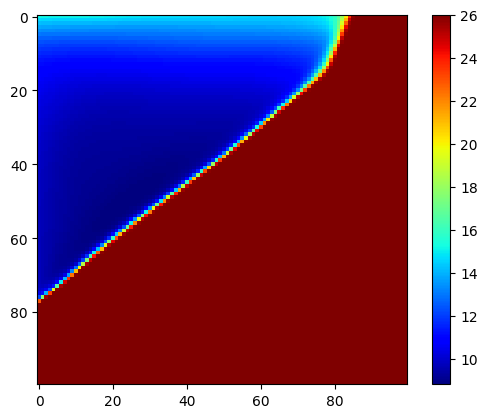

Epoch 0093  loss over 1250  batches  Loss = 0.01712606


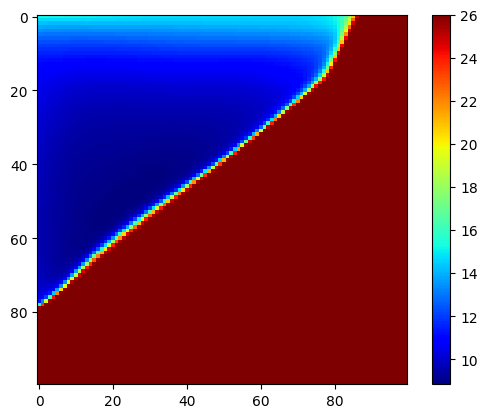

Epoch 0094  loss over 1250  batches  Loss = 0.01695093


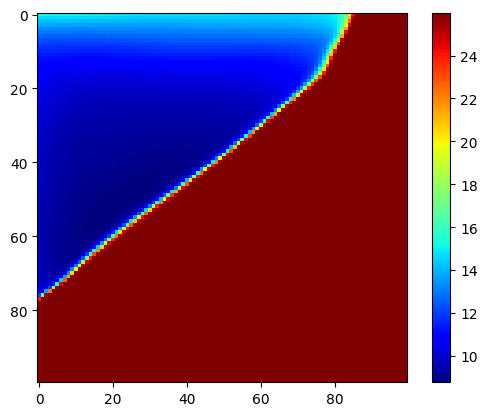

Epoch 0095  loss over 1250  batches  Loss = 0.01764152


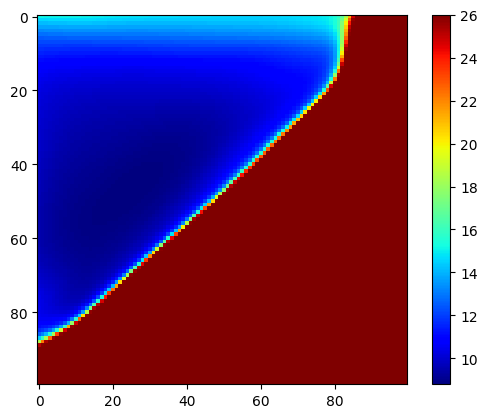

Epoch 0096  loss over 1250  batches  Loss = 0.03719572


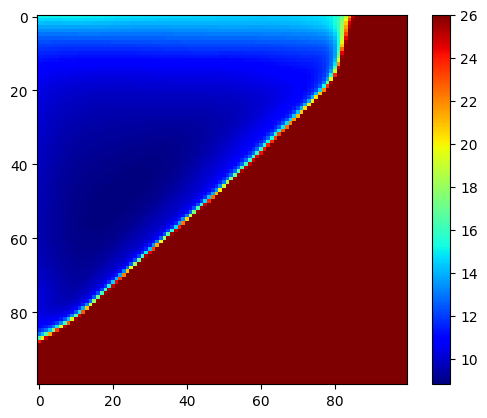

Epoch 0097  loss over 1250  batches  Loss = 0.01268620


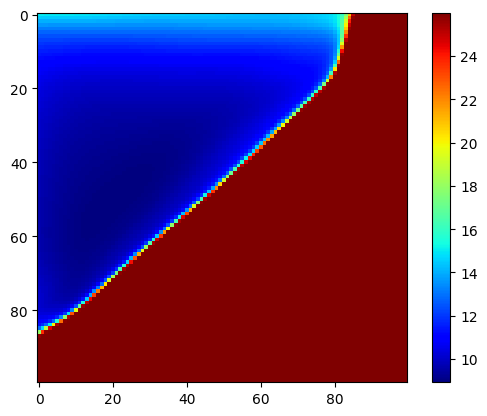

Epoch 0098  loss over 1250  batches  Loss = 0.01636815


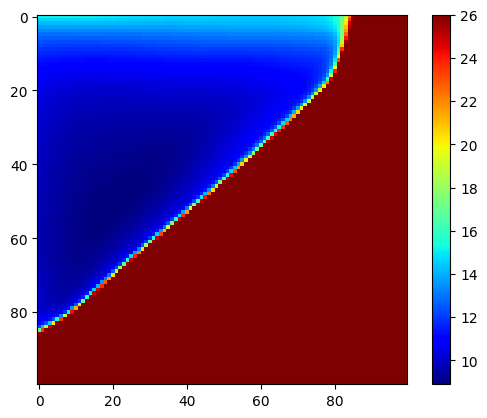

Epoch 0099  loss over 1250  batches  Loss = 0.01674747
Time:  1345.7477368749678
min =  100000


In [119]:
start = timeit.default_timer()
min = 100000;
batches = int(len(X_train_no_Y)/batch_size)
training_epochs = 100
#model = tf.keras.models.load_model('h5_files/FC2_36.keras')
for epoch in range(training_epochs):
    Losses = 0
    for j in range(batches):
#    for j in range(1):
        index1 = np.random.randint(X_train1.shape[0], size=batch_size)
        index3 = np.random.randint(X_train3.shape[0], size=batch_size)
        X_b = tf.gather(X_train1_t, index1)
        Y_b = tf.gather(Y_train1_t, index1)
        X_e = tf.gather(X_train3_t, index3)
        Y_e = tf.gather(Y_train3_t, index3)
        
        Loss = pre_train(X_b, Y_b,  X_e, Y_e)
        Losses = Losses + Loss

        
    Y_VAL = model(X_test_t, training=False)
    fig = plt.figure()
    im = plt.imshow(np.reshape(Y_VAL, (100, 100)), cmap='jet', interpolation='nearest')
    cbar = plt.colorbar(im)
    plt.show()
    filename = 'h5_files/FC3_' + str(epoch) + '.keras'
    model.save(filename)
    
    #if losses1/batches + 0.2*losses2/batches < min:
    #    min = losses1/batches + 0.2*losses2/batches



    if epoch%1 == 0: #or losses1/batches < min:
        print("Epoch %.4d " % epoch, "loss over", batches, " batches ", "Loss = %.8f" % (Losses/batches))
    
stop = timeit.default_timer()


print('Time: ', stop - start) 
print('min = ', min)


In [114]:
@tf.function
def train_step(X_b, Y_b, X_c, X_e, Y_e):
    
    with tf.GradientTape() as tape:
        y_pred = model(X_b, training=True)
        loss_1 = tf.reduce_mean(tf.square(Y_b - y_pred)) + 5*tf.reduce_mean(tf.math.maximum(0.0, - y_pred))
    grads_1 = tape.gradient(loss_1, model.trainable_weights)

    
    with tf.GradientTape(persistent=True) as tape:               
        I1, I3, theta1, theta3 = X_c[...,0], X_c[...,1], X_c[...,2], X_c[...,3]
    
        tape.watch(X_c)
        y_pred = model(X_c, training=True)
        y_pred_t = tf.transpose(y_pred)                      
        grad_u = tape.gradient(y_pred_t, X_c)
        #print(grad_u.shape)
        U_I1 = grad_u[...,0]       
        U_I3 = grad_u[...,1]       
        U_theta1 = grad_u[...,2]       
        U_theta3 = grad_u[...,3]       
        
        U_I1I1 = tape.gradient(U_I1,X_c)[...,0]
        U_I3I3 = tape.gradient(U_I3,X_c)[...,1]
        U_theta1theta1 = tape.gradient(U_theta1,X_c)[...,2]
        U_theta3theta3 = tape.gradient(U_theta3,X_c)[...,3]
        #Delta = tf.multiply(gam/2,U_theta1theta1)
        Delta = tf.multiply(tf.constant(0.25, dtype=tf.float32)*gam*T1*I1,U_I1I1) + tf.multiply(tf.constant(0.25, dtype=tf.float32)*gam*T3*I3,U_I3I3) + tf.multiply(tf.constant(0.5, dtype=tf.float32)*gam,U_theta1theta1) + tf.multiply(tf.constant(0.5, dtype=tf.float32)*gam,U_theta3theta3)
        g1, g2, g3, g4 = f(X_c)
        Mu = tf.multiply(g1,U_I1) + tf.multiply(g2,U_I3) + tf.multiply(g3,U_theta1) + tf.multiply(g4,U_theta3) 
        generator = Mu + Delta + tf.multiply(y_pred[...,0], c(X_c)) + 4.0
        #tf.print(Mu)
        #tf.print(Delta)
        #tf.print(tf.multiply(y_pred[...,0], c(X_c)))
        #tf.print(generator)
        loss_2 = tf.reduce_mean(tf.square(generator))
    grads_2 = tape.gradient(loss_2, model.trainable_weights)
    
    with tf.GradientTape(persistent=True) as tape:
        
        tape.watch(X_e)
        y_pred = model(X_e, training=True)
        y_pred_t = tf.transpose(y_pred)                      
        grad_u = tape.gradient(y_pred_t, X_e)
        row_norms = tf.norm(grad_u, axis=1)
        #tf.print(tf.reduce_mean(tf.square(Y_e - y_pred)))
        #tf.print(tf.reduce_mean(row_norms))
        #tf.print(y_pred)
        loss_3 = tf.reduce_mean(tf.square(Y_e - y_pred)) + tf.reduce_mean(row_norms) 
    grads_3 = tape.gradient(loss_3, model.trainable_weights)

    
    opt1.apply_gradients(zip(grads_1, model.trainable_weights))
    opt2.apply_gradients(zip(grads_2, model.trainable_weights))
    opt3.apply_gradients(zip(grads_3, model.trainable_weights))
    
    return loss_1, loss_2, loss_3



In [123]:
@tf.function
def train_step_2(X_b, Y_b, X_c, X_e, Y_e, X_f):
    
    with tf.GradientTape() as tape:
        y_pred = model(X_b, training=True)
        loss_1 = tf.reduce_mean(tf.square(Y_b - y_pred)) + 5*tf.reduce_mean(tf.math.maximum(0.0, - y_pred))
    grads_1 = tape.gradient(loss_1, model.trainable_weights)

    
    with tf.GradientTape(persistent=True) as tape:               
        I1, I3, theta1, theta3 = X_c[...,0], X_c[...,1], X_c[...,2], X_c[...,3]
    
        tape.watch(X_c)
        y_pred = model(X_c, training=True)
        y_pred_t = tf.transpose(y_pred)                      
        grad_u = tape.gradient(y_pred_t, X_c)
        #print(grad_u.shape)
        U_I1 = grad_u[...,0]       
        U_I3 = grad_u[...,1]       
        U_theta1 = grad_u[...,2]       
        U_theta3 = grad_u[...,3]       
        
        U_I1I1 = tape.gradient(U_I1,X_c)[...,0]
        U_I3I3 = tape.gradient(U_I3,X_c)[...,1]
        U_theta1theta1 = tape.gradient(U_theta1,X_c)[...,2]
        U_theta3theta3 = tape.gradient(U_theta3,X_c)[...,3]
        Delta = tf.multiply(0.25*gam*T1*I1,U_I1I1) + tf.multiply(0.25*gam*T3*I3,U_I3I3) + tf.multiply(tf.constant(0.5, dtype=tf.float32)*gam,U_theta1theta1) + tf.multiply(tf.constant(0.5, dtype=tf.float32)*gam,U_theta3theta3)
        g1, g2, g3, g4 = f(X_c)
        Mu = tf.multiply(g1,U_I1) + tf.multiply(g2,U_I3) + tf.multiply(g3,U_theta1) + tf.multiply(g4,U_theta3) 
        generator = Mu + Delta + tf.multiply(y_pred[...,0], c(X_c)) + 4.0
        #tf.print(Mu)
        #tf.print(Delta)
        #tf.print(tf.multiply(y_pred[...,0], c(X_c)))
        #tf.print(generator)
        loss_2 = tf.reduce_mean(tf.math.maximum(0.0, generator))
    grads_2 = tape.gradient(loss_2, model.trainable_weights)
    
    with tf.GradientTape(persistent=True) as tape:
        
        tape.watch(X_e)
        y_pred = model(X_e, training=True)
        y_pred_t = tf.transpose(y_pred)                      
        grad_u = tape.gradient(y_pred_t, X_e)
        row_norms = tf.norm(grad_u, axis=1)
        #tf.print(tf.reduce_mean(tf.square(Y_e - y_pred)))
        #tf.print(tf.reduce_mean(row_norms))
        loss_3 = tf.reduce_mean(tf.square(Y_e - y_pred)) + tf.reduce_mean(row_norms) 
    grads_3 = tape.gradient(loss_3, model.trainable_weights)
    
    with tf.GradientTape(persistent=True) as tape:               
        I1, I3, theta1, theta3 = X_f[...,0], X_f[...,1], X_f[...,2], X_f[...,3]
    
        tape.watch(X_f)
        y_pred = model(X_f, training=True)
        y_pred_t = tf.transpose(y_pred)                      
        grad_u = tape.gradient(y_pred_t, X_f)
        #print(grad_u.shape)
        U_I1 = grad_u[...,0]       
        U_I3 = grad_u[...,1]       
        U_theta1 = grad_u[...,2]       
        U_theta3 = grad_u[...,3]       
        
        U_I1I1 = tape.gradient(U_I1,X_f)[...,0]
        U_I3I3 = tape.gradient(U_I3,X_f)[...,1]
        U_theta1theta1 = tape.gradient(U_theta1,X_f)[...,2]
        U_theta3theta3 = tape.gradient(U_theta3,X_f)[...,3]
        Delta = tf.multiply(0.25*gam*T1*I1,U_I1I1) + tf.multiply(0.25*gam*T3*I3,U_I3I3) + tf.multiply(gam,U_theta1theta1) + tf.multiply(gam,U_theta3theta3)
        g1, g2, g3, g4 = f(X_c)
        Mu = tf.multiply(g1,U_I1) + tf.multiply(g2,U_I3) + tf.multiply(g3,U_theta1) + tf.multiply(g4,U_theta3) 
        generator = Mu + Delta
        loss_4 = tf.reduce_mean(tf.math.maximum(0.0, generator - 10.0))
    grads_4 = tape.gradient(loss_4, model.trainable_weights)

    
    opt1.apply_gradients(zip(grads_1, model.trainable_weights))
    opt2.apply_gradients(zip(grads_2, model.trainable_weights))
    opt3.apply_gradients(zip(grads_3, model.trainable_weights))
    opt4.apply_gradients(zip(grads_4, model.trainable_weights))
    
    return loss_1, loss_2, loss_3, loss_4



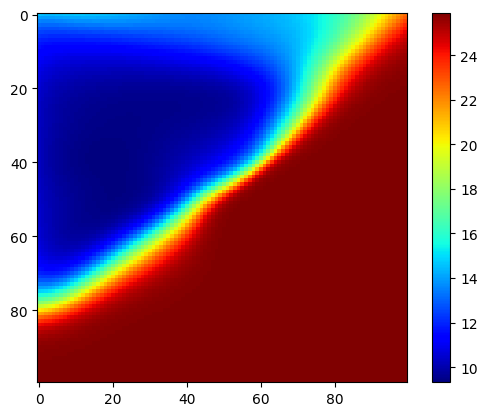

Epoch 0000  loss over 1250  batches  Loss 1 = 2.55602980 Loss 2 = 0.50503576 Loss 3 = 15.49019909 Loss 4 = 0.10827588


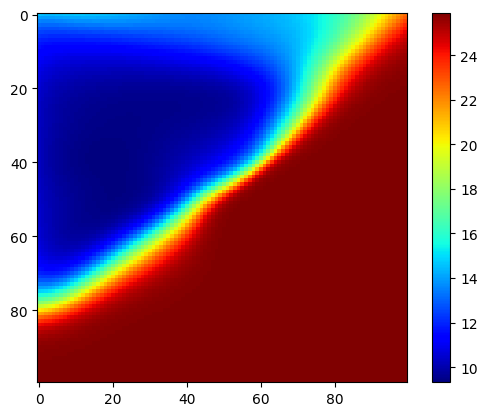

Epoch 0001  loss over 1250  batches  Loss 1 = 2.64654064 Loss 2 = 0.52080756 Loss 3 = 15.09738636 Loss 4 = 0.13821961


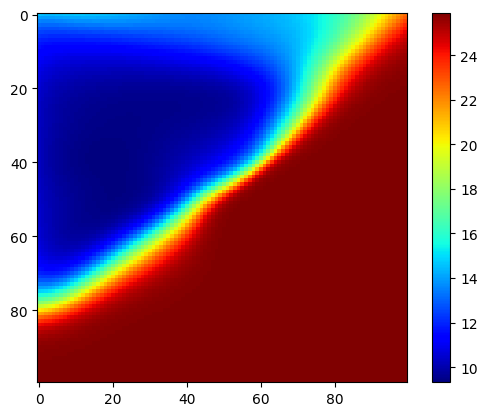

Epoch 0002  loss over 1250  batches  Loss 1 = 2.55215192 Loss 2 = 0.53805459 Loss 3 = 14.70779896 Loss 4 = 0.11536437


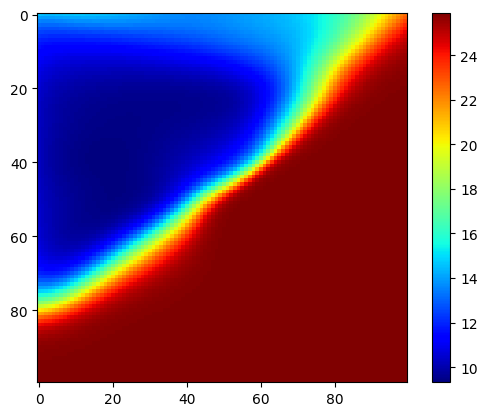

Epoch 0003  loss over 1250  batches  Loss 1 = 2.83336687 Loss 2 = 0.59291637 Loss 3 = 15.72192383 Loss 4 = 0.06775614


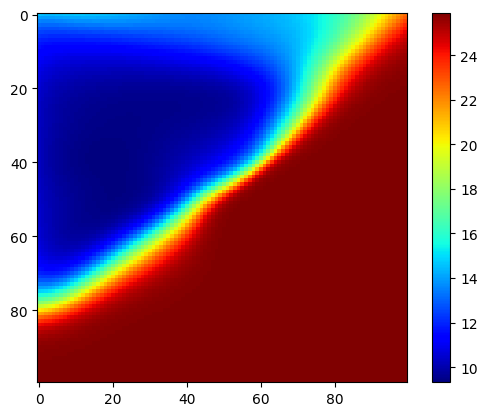

Epoch 0004  loss over 1250  batches  Loss 1 = 2.63109612 Loss 2 = 0.56524378 Loss 3 = 17.25714684 Loss 4 = 0.05604360


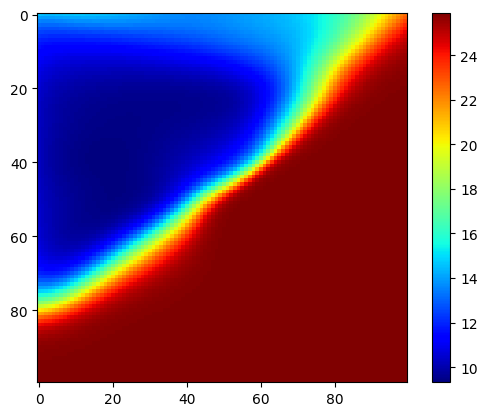

Epoch 0005  loss over 1250  batches  Loss 1 = 2.53361917 Loss 2 = 0.59493399 Loss 3 = 15.83409405 Loss 4 = 0.05506710


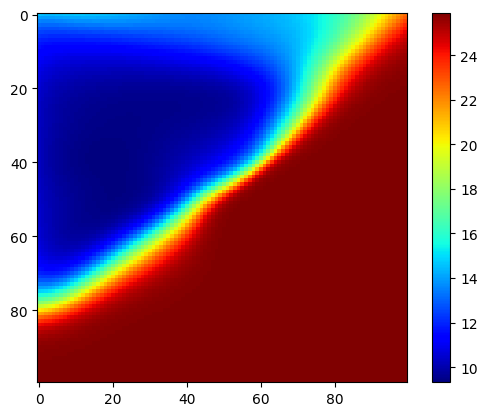

Epoch 0006  loss over 1250  batches  Loss 1 = 2.21633530 Loss 2 = 0.59212118 Loss 3 = 15.54562569 Loss 4 = 0.04508026


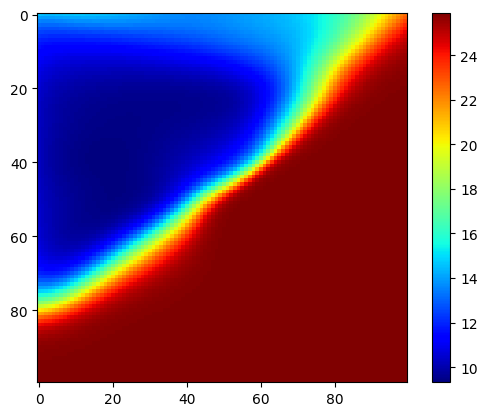

Epoch 0007  loss over 1250  batches  Loss 1 = 2.08576155 Loss 2 = 0.65380961 Loss 3 = 14.85532856 Loss 4 = 0.05162227


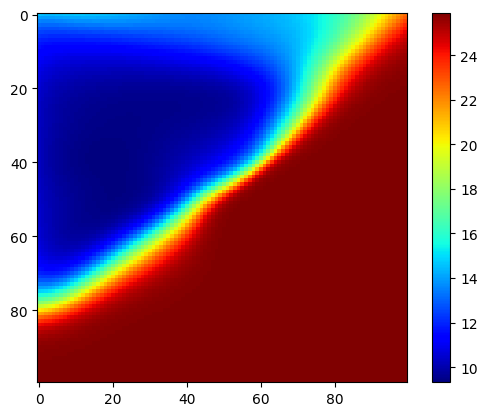

Epoch 0008  loss over 1250  batches  Loss 1 = 2.08901453 Loss 2 = 0.59724814 Loss 3 = 14.14566803 Loss 4 = 0.07834082


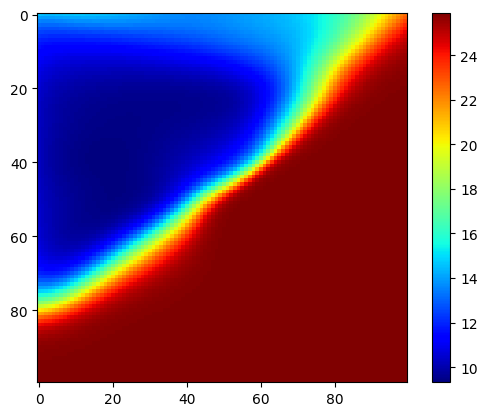

Epoch 0009  loss over 1250  batches  Loss 1 = 2.03492808 Loss 2 = 0.58331132 Loss 3 = 13.57748985 Loss 4 = 0.07706133


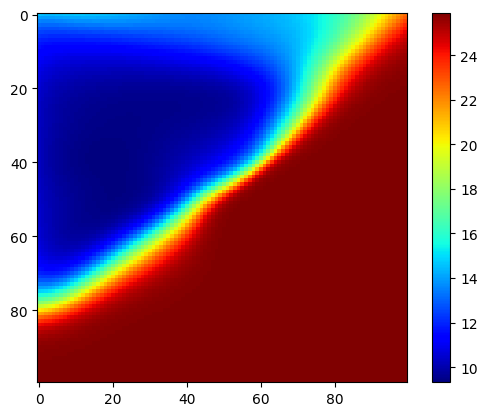

Epoch 0010  loss over 1250  batches  Loss 1 = 2.21604967 Loss 2 = 0.64429158 Loss 3 = 14.16446495 Loss 4 = 0.07460633


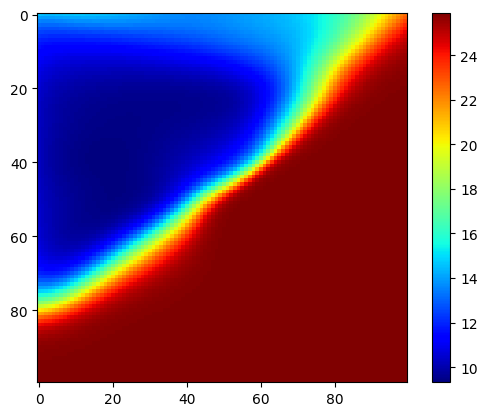

Epoch 0011  loss over 1250  batches  Loss 1 = 2.50642395 Loss 2 = 0.70422298 Loss 3 = 15.36369133 Loss 4 = 0.04783574


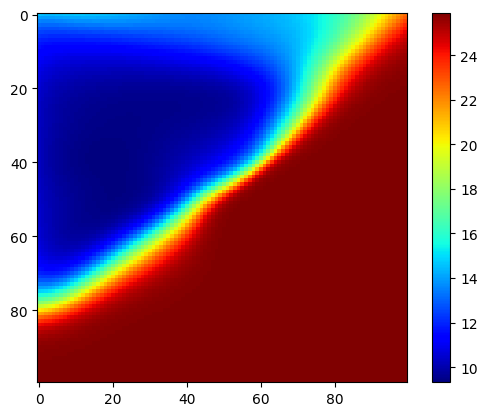

Epoch 0012  loss over 1250  batches  Loss 1 = 2.76635838 Loss 2 = 0.75876087 Loss 3 = 17.41252518 Loss 4 = 0.04033040


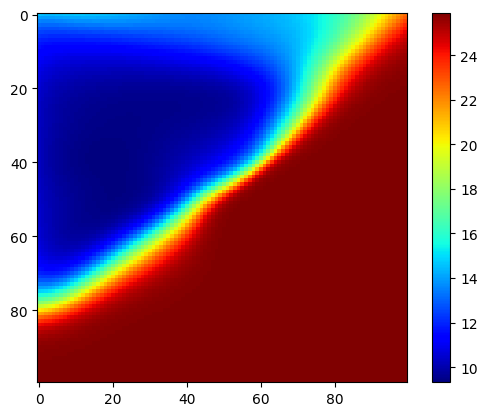

Epoch 0013  loss over 1250  batches  Loss 1 = 2.73704290 Loss 2 = 0.94022202 Loss 3 = 19.84228325 Loss 4 = 0.02972527


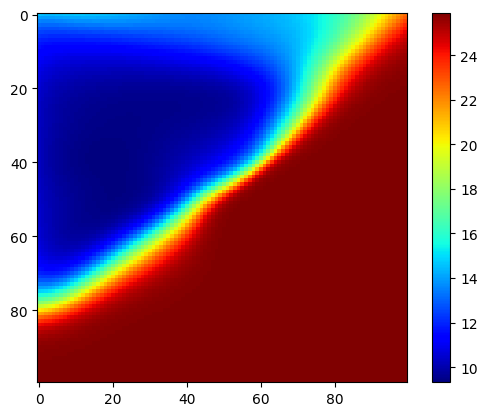

Epoch 0014  loss over 1250  batches  Loss 1 = 2.73433518 Loss 2 = 0.94484133 Loss 3 = 20.58528519 Loss 4 = 0.03432896


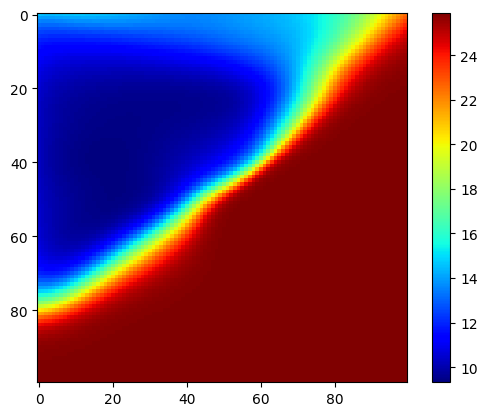

Epoch 0015  loss over 1250  batches  Loss 1 = 2.89592361 Loss 2 = 0.83860338 Loss 3 = 21.41504860 Loss 4 = 0.04452496


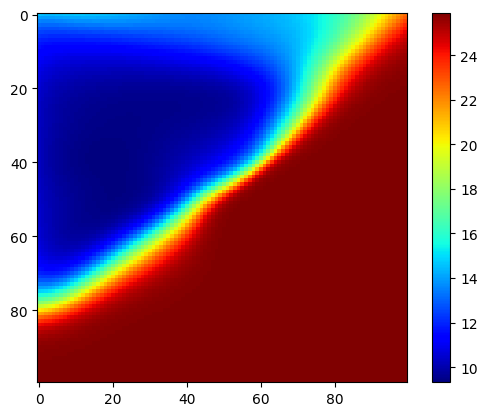

Epoch 0016  loss over 1250  batches  Loss 1 = 2.49486947 Loss 2 = 0.83472514 Loss 3 = 20.82379532 Loss 4 = 0.06879010


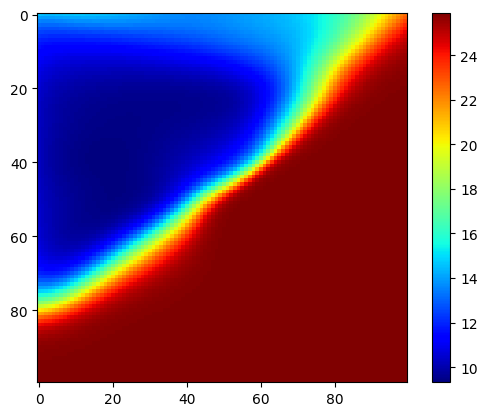

Epoch 0017  loss over 1250  batches  Loss 1 = 2.50371861 Loss 2 = 0.80665797 Loss 3 = 20.39136696 Loss 4 = 0.11651792


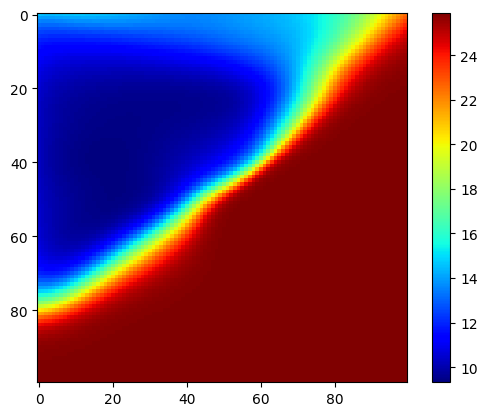

Epoch 0018  loss over 1250  batches  Loss 1 = 2.40573096 Loss 2 = 0.84003365 Loss 3 = 20.36290741 Loss 4 = 0.09971944


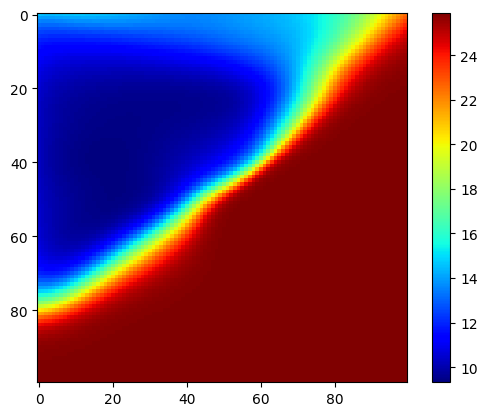

Epoch 0019  loss over 1250  batches  Loss 1 = 2.45857358 Loss 2 = 0.83439946 Loss 3 = 20.58067131 Loss 4 = 0.10252630


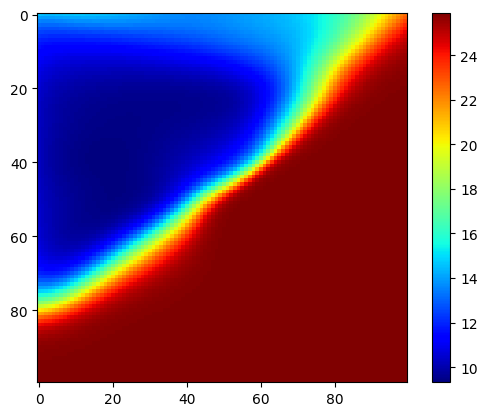

Epoch 0020  loss over 1250  batches  Loss 1 = 2.22235703 Loss 2 = 1.00485313 Loss 3 = 20.49174500 Loss 4 = 0.06812972


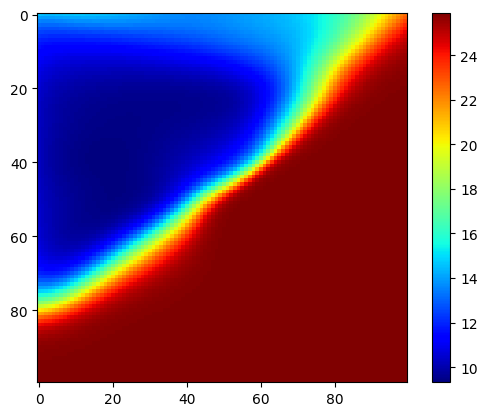

Epoch 0021  loss over 1250  batches  Loss 1 = 2.06294918 Loss 2 = 0.95309865 Loss 3 = 20.29829216 Loss 4 = 0.13622932


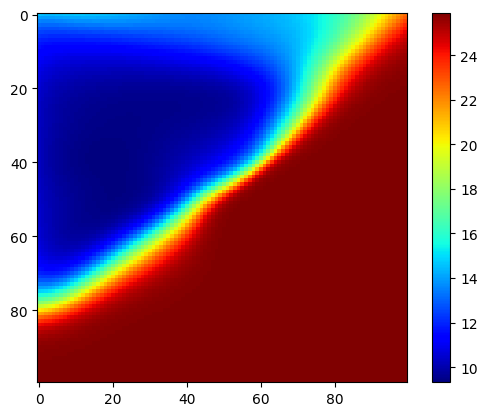

Epoch 0022  loss over 1250  batches  Loss 1 = 1.85272038 Loss 2 = 0.81967145 Loss 3 = 18.72604942 Loss 4 = 0.16711892


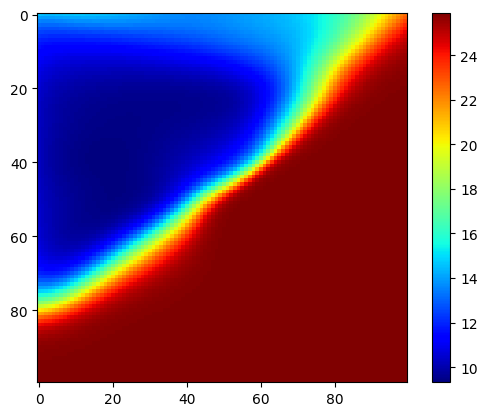

Epoch 0023  loss over 1250  batches  Loss 1 = 1.88255942 Loss 2 = 0.86155903 Loss 3 = 17.39784050 Loss 4 = 0.14956537


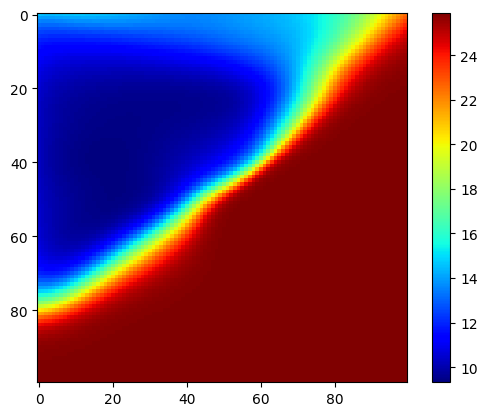

Epoch 0024  loss over 1250  batches  Loss 1 = 2.43691349 Loss 2 = 0.79928243 Loss 3 = 18.86683464 Loss 4 = 0.09656911


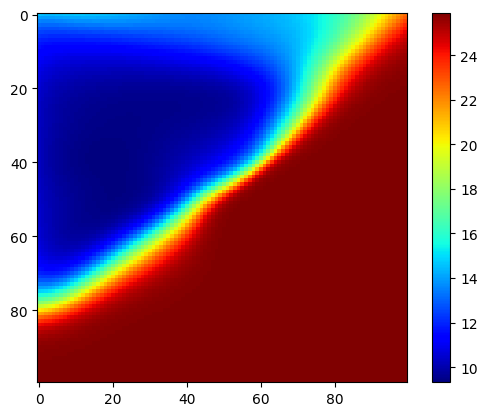

Epoch 0025  loss over 1250  batches  Loss 1 = 3.04776955 Loss 2 = 0.65901154 Loss 3 = 21.70539093 Loss 4 = 0.07752514


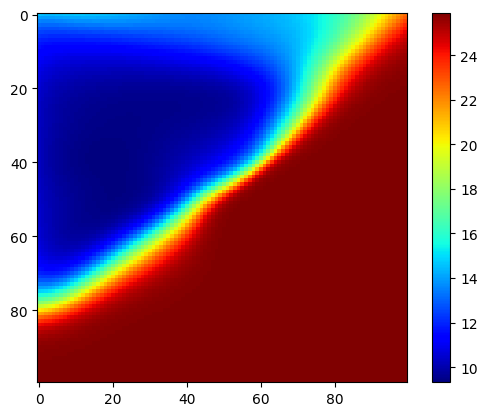

Epoch 0026  loss over 1250  batches  Loss 1 = 2.87909985 Loss 2 = 0.59892768 Loss 3 = 24.16134644 Loss 4 = 0.07787023


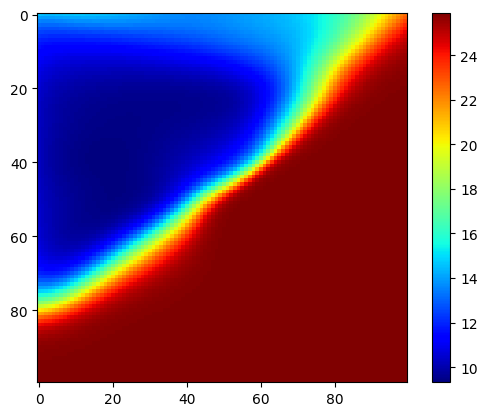

Epoch 0027  loss over 1250  batches  Loss 1 = 2.88013363 Loss 2 = 0.69075221 Loss 3 = 24.49629402 Loss 4 = 0.06189805


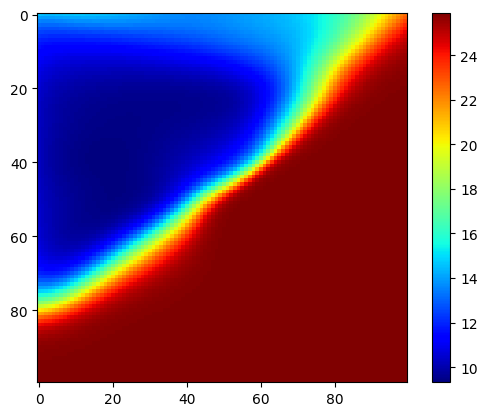

Epoch 0028  loss over 1250  batches  Loss 1 = 2.58256602 Loss 2 = 0.69112337 Loss 3 = 23.50166893 Loss 4 = 0.06707869


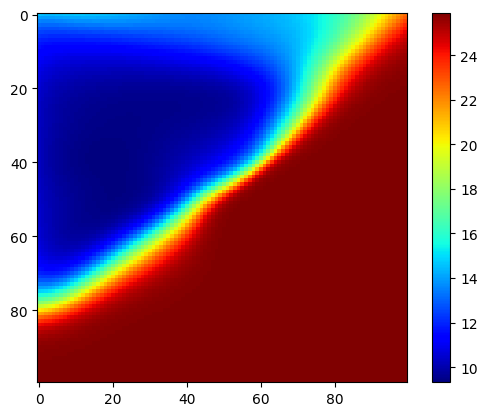

Epoch 0029  loss over 1250  batches  Loss 1 = 2.44328499 Loss 2 = 0.72961378 Loss 3 = 21.34129715 Loss 4 = 0.07470470


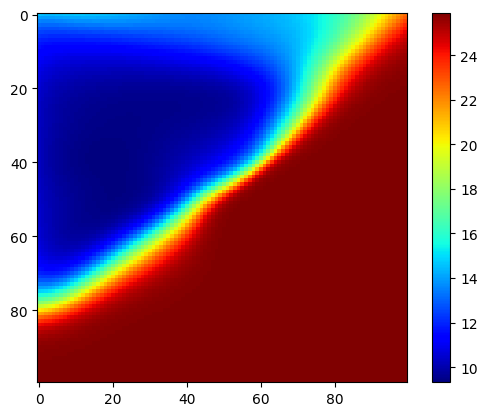

Epoch 0030  loss over 1250  batches  Loss 1 = 2.71473861 Loss 2 = 0.63812035 Loss 3 = 20.28258133 Loss 4 = 0.05212819


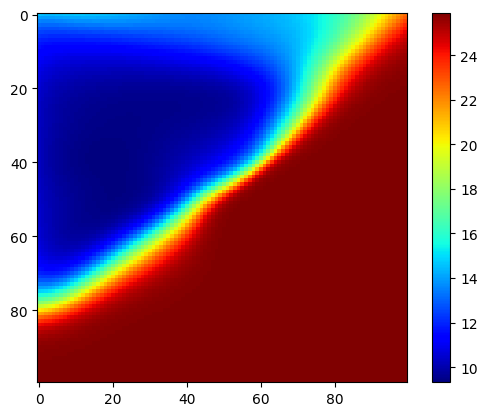

Epoch 0031  loss over 1250  batches  Loss 1 = 2.61482573 Loss 2 = 0.64002919 Loss 3 = 19.71976089 Loss 4 = 0.04141356


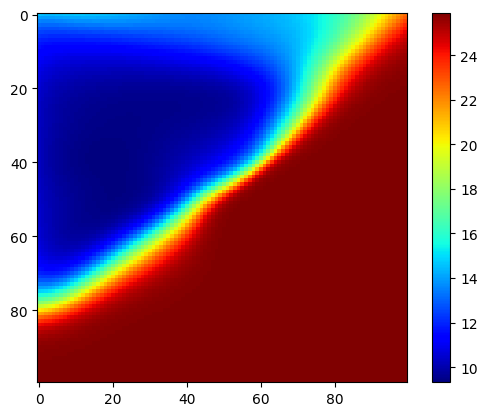

Epoch 0032  loss over 1250  batches  Loss 1 = 2.58015227 Loss 2 = 0.69014722 Loss 3 = 18.86376572 Loss 4 = 0.04664501


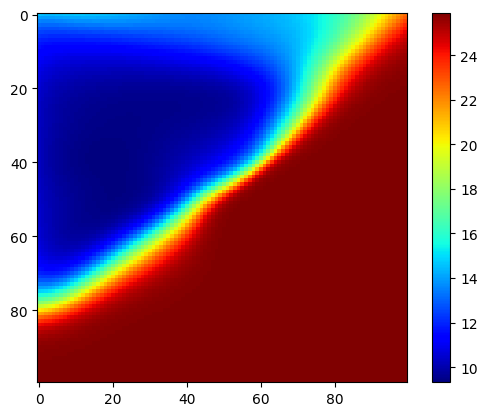

Epoch 0033  loss over 1250  batches  Loss 1 = 2.66513109 Loss 2 = 0.64560854 Loss 3 = 21.21108627 Loss 4 = 0.04731049


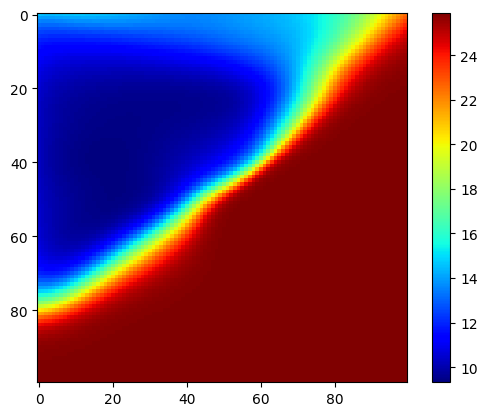

Epoch 0034  loss over 1250  batches  Loss 1 = 2.52935266 Loss 2 = 0.68063051 Loss 3 = 21.90032578 Loss 4 = 0.03925728


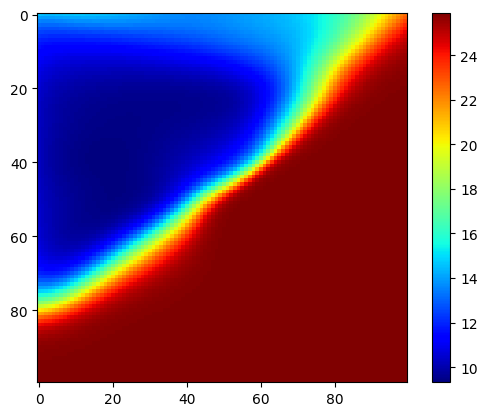

Epoch 0035  loss over 1250  batches  Loss 1 = 2.54713058 Loss 2 = 0.70247716 Loss 3 = 23.26461220 Loss 4 = 0.04216238


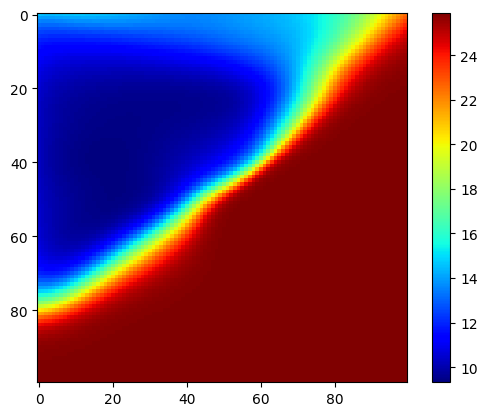

Epoch 0036  loss over 1250  batches  Loss 1 = 2.57160163 Loss 2 = 0.77080786 Loss 3 = 23.97114944 Loss 4 = 0.06859337


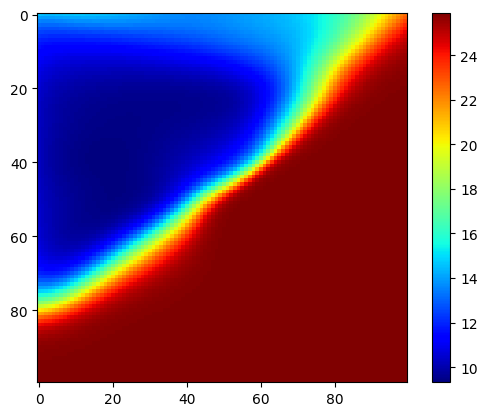

Epoch 0037  loss over 1250  batches  Loss 1 = 2.46040678 Loss 2 = 0.87695920 Loss 3 = 24.52095985 Loss 4 = 0.05358896


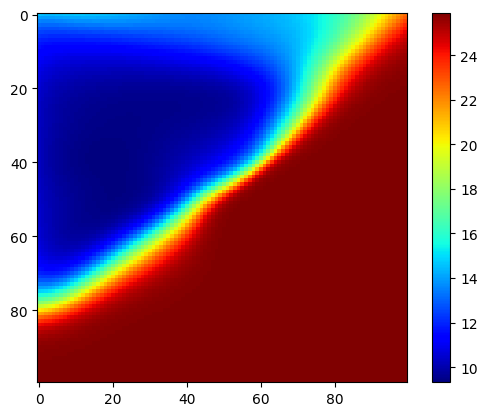

Epoch 0038  loss over 1250  batches  Loss 1 = 2.47670603 Loss 2 = 0.79469943 Loss 3 = 24.56049728 Loss 4 = 0.07248613


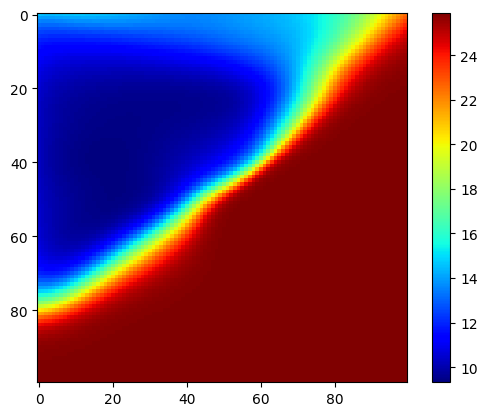

Epoch 0039  loss over 1250  batches  Loss 1 = 2.49403000 Loss 2 = 0.75429004 Loss 3 = 25.57122231 Loss 4 = 0.11192928


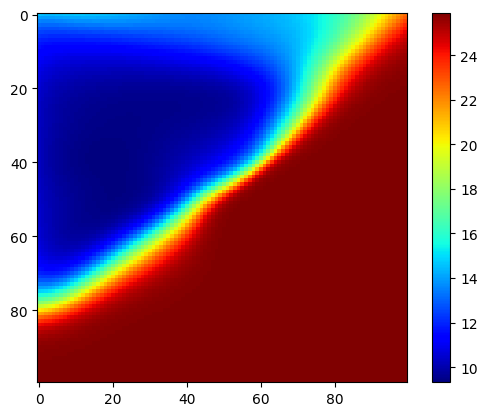

Epoch 0040  loss over 1250  batches  Loss 1 = 2.32222962 Loss 2 = 0.74353635 Loss 3 = 24.86358643 Loss 4 = 0.07899275


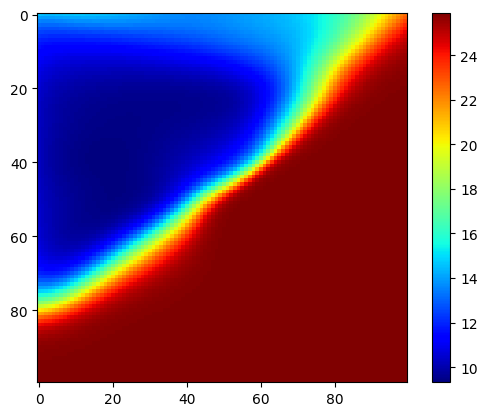

Epoch 0041  loss over 1250  batches  Loss 1 = 2.60076404 Loss 2 = 0.75453568 Loss 3 = 25.74284744 Loss 4 = 0.07379801


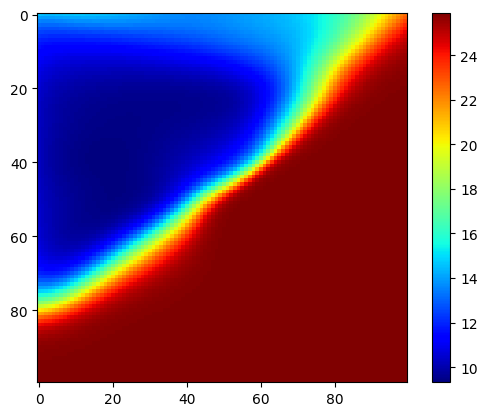

Epoch 0042  loss over 1250  batches  Loss 1 = 2.46946096 Loss 2 = 0.82821643 Loss 3 = 27.27502060 Loss 4 = 0.05046617


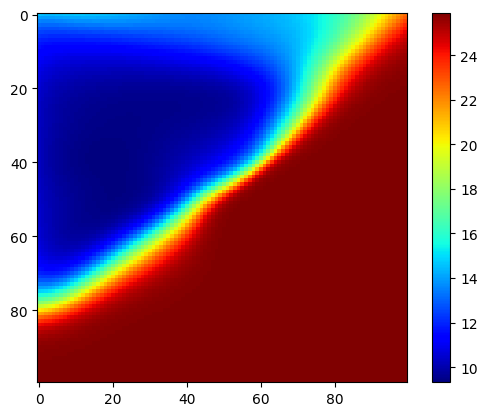

Epoch 0043  loss over 1250  batches  Loss 1 = 2.13381052 Loss 2 = 0.81606108 Loss 3 = 26.06658173 Loss 4 = 0.07725198


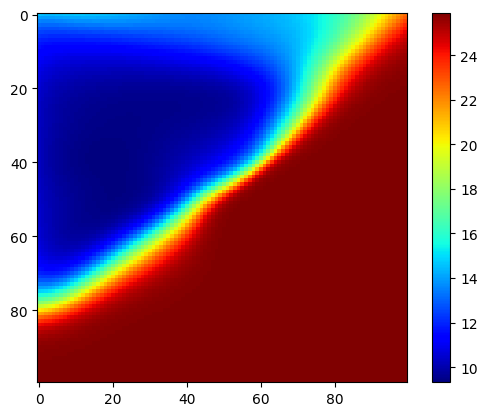

Epoch 0044  loss over 1250  batches  Loss 1 = 2.10341096 Loss 2 = 0.85812259 Loss 3 = 25.81650734 Loss 4 = 0.10953492


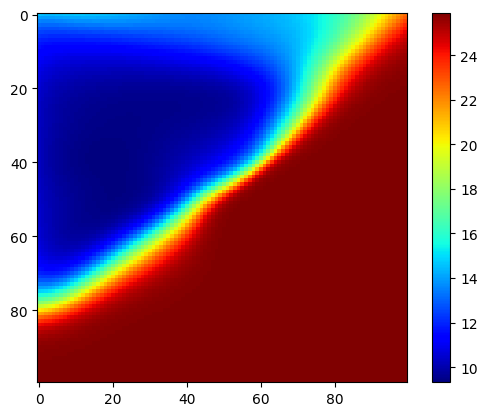

Epoch 0045  loss over 1250  batches  Loss 1 = 2.63151193 Loss 2 = 1.00362575 Loss 3 = 27.99137306 Loss 4 = 0.09093862


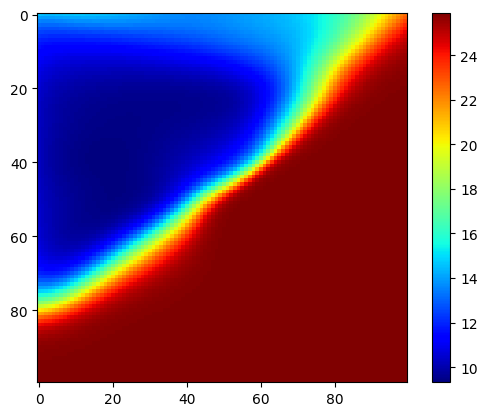

Epoch 0046  loss over 1250  batches  Loss 1 = 2.55568767 Loss 2 = 0.93119615 Loss 3 = 27.80211449 Loss 4 = 0.06566170


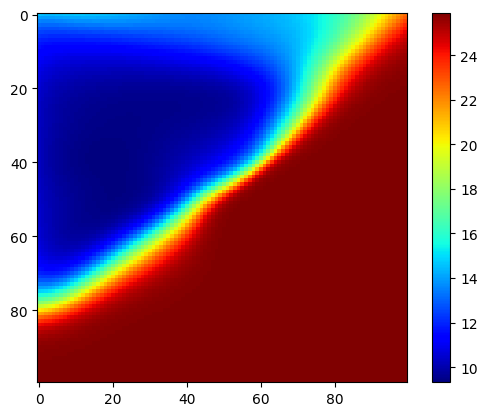

Epoch 0047  loss over 1250  batches  Loss 1 = 2.37277484 Loss 2 = 0.88280708 Loss 3 = 26.79853249 Loss 4 = 0.07255191


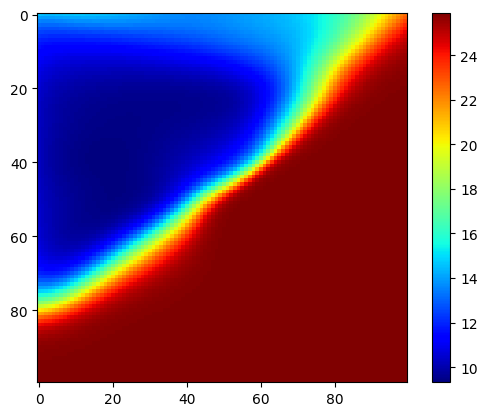

Epoch 0048  loss over 1250  batches  Loss 1 = 2.08831906 Loss 2 = 0.88535953 Loss 3 = 23.76579857 Loss 4 = 0.07161427


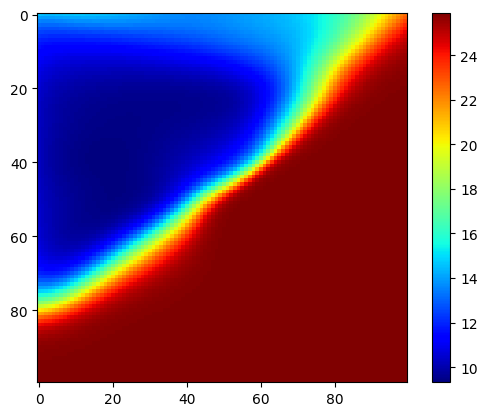

Epoch 0049  loss over 1250  batches  Loss 1 = 2.06141400 Loss 2 = 0.76810050 Loss 3 = 16.67710304 Loss 4 = 0.06518038


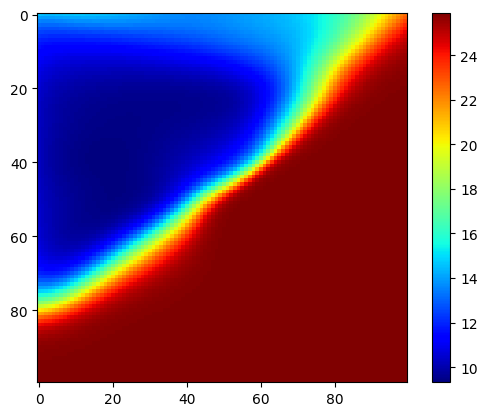

Epoch 0050  loss over 1250  batches  Loss 1 = 1.90423548 Loss 2 = 0.68267328 Loss 3 = 11.79908466 Loss 4 = 0.06613822


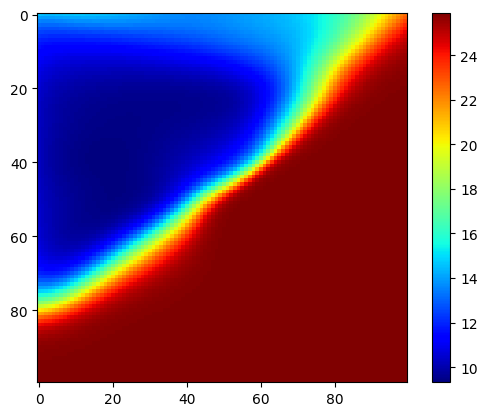

Epoch 0051  loss over 1250  batches  Loss 1 = 2.01643682 Loss 2 = 0.64529186 Loss 3 = 11.36190224 Loss 4 = 0.06519419


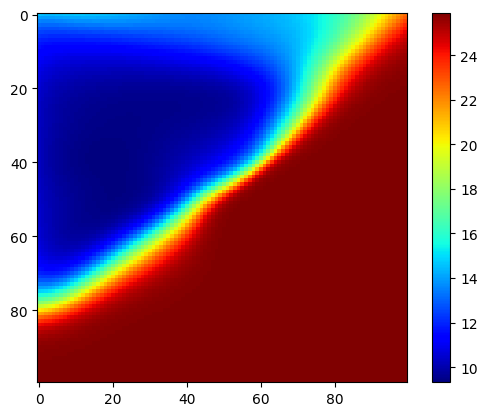

Epoch 0052  loss over 1250  batches  Loss 1 = 2.11370134 Loss 2 = 0.71321785 Loss 3 = 11.91007519 Loss 4 = 0.06481656


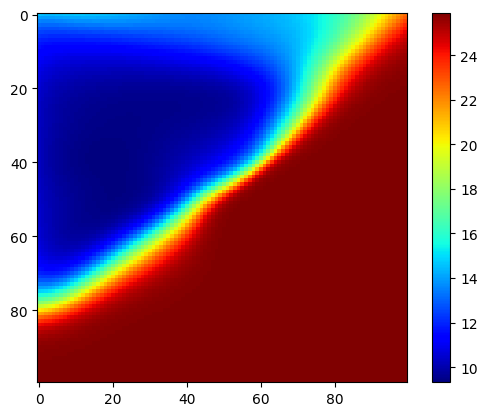

Epoch 0053  loss over 1250  batches  Loss 1 = 2.40539670 Loss 2 = 0.71837521 Loss 3 = 12.41902065 Loss 4 = 0.07187488


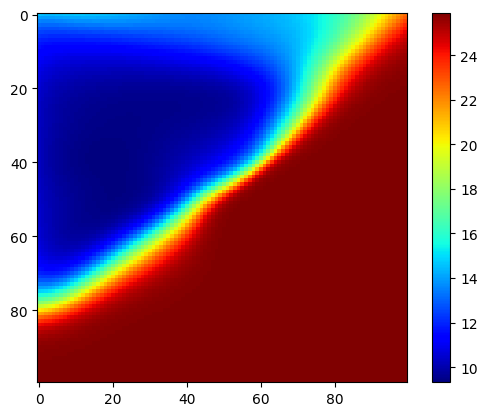

Epoch 0054  loss over 1250  batches  Loss 1 = 3.30426145 Loss 2 = 0.78564626 Loss 3 = 14.59449005 Loss 4 = 0.07042114


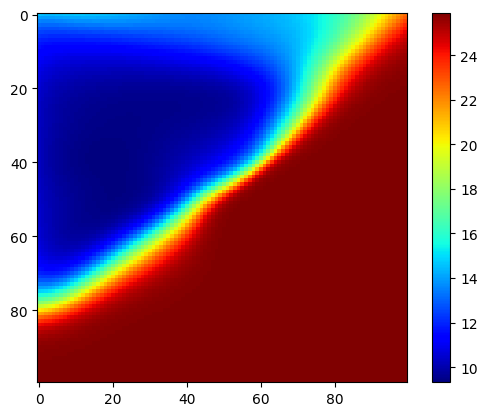

Epoch 0055  loss over 1250  batches  Loss 1 = 3.97902560 Loss 2 = 0.77230734 Loss 3 = 17.17646217 Loss 4 = 0.06561209


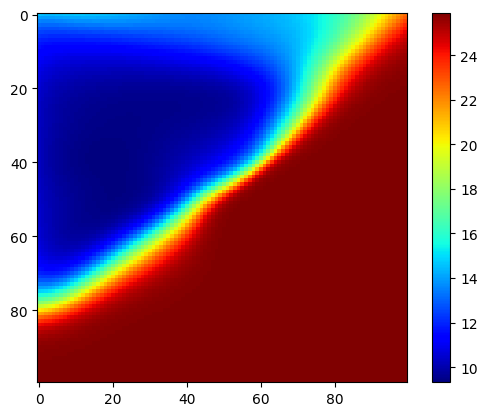

Epoch 0056  loss over 1250  batches  Loss 1 = 3.81921983 Loss 2 = 0.76378113 Loss 3 = 18.78897667 Loss 4 = 0.06347662


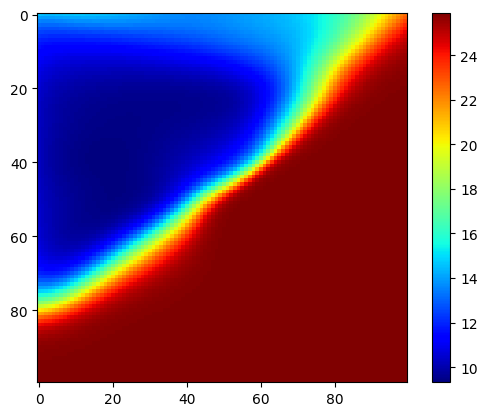

Epoch 0057  loss over 1250  batches  Loss 1 = 3.64651060 Loss 2 = 0.81631202 Loss 3 = 17.26752281 Loss 4 = 0.05218052


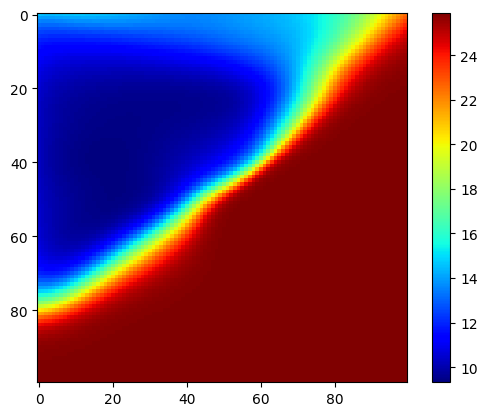

Epoch 0058  loss over 1250  batches  Loss 1 = 4.14837074 Loss 2 = 0.93316740 Loss 3 = 18.86734390 Loss 4 = 0.03704095


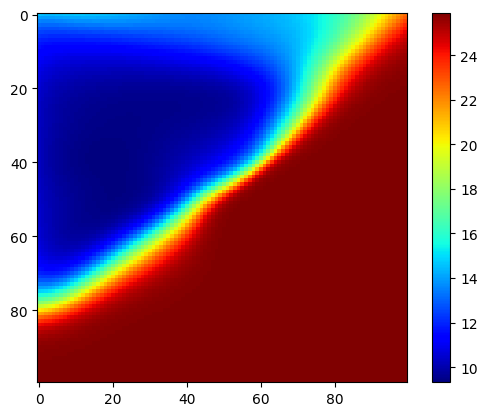

Epoch 0059  loss over 1250  batches  Loss 1 = 4.64225960 Loss 2 = 1.32873988 Loss 3 = 20.94616890 Loss 4 = 0.04063815


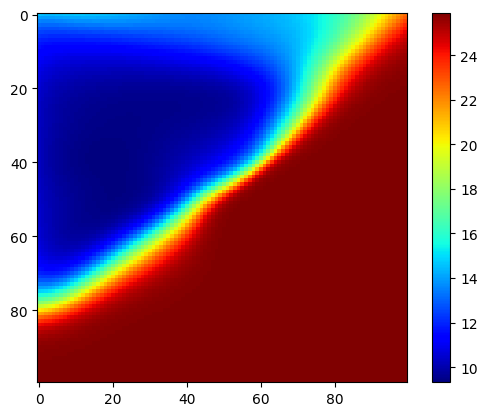

Epoch 0060  loss over 1250  batches  Loss 1 = 4.47961950 Loss 2 = 1.05586612 Loss 3 = 20.68041992 Loss 4 = 0.01839505



KeyboardInterrupt



In [130]:
opt4 = tf.keras.optimizers.Adam(learning_rate=0.0001)
start = timeit.default_timer()
min = 100000;
batches = int(len(X_train_no_Y)/batch_size)
training_epochs = 100
model = tf.keras.models.load_model('h5_files/FC2_47.keras')
opt1.learning_rate.assign(0.0002)
opt2.learning_rate.assign(0.0001)
opt3.learning_rate.assign(0.0001)
opt4.learning_rate.assign(0.0001)
for epoch in range(training_epochs):
    losses1 = 0
    losses2 = 0
    losses3 = 0
    losses4 = 0
    for j in range(batches):
#    for j in range(1):
        index1 = np.random.randint(X_train1.shape[0], size=batch_size)
        index2 = np.random.randint(X_train_no_Y.shape[0], size=batch_size)
        index3 = np.random.randint(X_train3.shape[0], size=batch_size)
        index4 = np.random.randint(X_train4.shape[0], size=batch_size)
        X_b = tf.gather(X_train1_t, index1)
        Y_b = tf.gather(Y_train1_t, index1)
        X_c = tf.gather(X_train_no_Y_t, index2)
        X_e = tf.gather(X_train3_t, index3)
        Y_e = tf.gather(Y_train3_t, index3)
        X_f = tf.gather(X_train4_t, index4)
        
        loss1, loss2, loss3, loss4 = train_step_2(X_b, Y_b, X_c, X_e, Y_e, X_f)
        losses1 = losses1 + loss1
        losses2 = losses2 + loss2
        losses3 = losses3 + loss3
        losses4 = losses4 + loss4
        
    Y_VAL = model(X_test_t, training=False)
    fig = plt.figure()
    im = plt.imshow(np.reshape(Y_VAL, (100, 100)), cmap='jet', interpolation='nearest')
    cbar = plt.colorbar(im)
    plt.show()
    filename = 'h5_files/FC2_' + str(epoch) + '.keras'
    model.save(filename)
    
    #if losses1/batches + 0.2*losses2/batches < min:
    #    min = losses1/batches + 0.2*losses2/batches



    if epoch%1 == 0: #or losses1/batches < min:
        print("Epoch %.4d " % epoch, "loss over", batches, " batches ", "Loss 1 = %.8f" % (losses1/batches), "Loss 2 = %.8f" % (losses2/batches), "Loss 3 = %.8f" % (losses3/batches), "Loss 4 = %.8f" % (losses4/batches))
    
stop = timeit.default_timer()


print('Time: ', stop - start) 
print('min = ', min)


In [154]:
weight1 = 4
weight2 = 1
weight3 = 1
weight4 = 2
weight_total = weight1 + weight2 + weight3 + weight4



@tf.function
def train_step_one_loss(X_b, Y_b, X_c, X_e, Y_e, X_f):
    
    with tf.GradientTape() as weight_tape:
        y_pred = model(X_b, training=True)
        loss_1 = tf.reduce_mean(tf.square(Y_b - y_pred)) + 5*tf.reduce_mean(tf.math.maximum(0.0, - y_pred))
    
        with tf.GradientTape(persistent=True) as tapec_2:
            with tf.GradientTape(persistent=True) as tapec_1:
                I1, I3, theta1, theta3 = X_c[...,0], X_c[...,1], X_c[...,2], X_c[...,3]
                tapec_1.watch(X_c)
                tapec_2.watch(X_c)
                y_pred = model(X_c, training=True)
                y_pred_t = tf.transpose(y_pred)                      
                grad_u = tapec_1.gradient(y_pred_t, X_c)
                #print(grad_u.shape)
                U_I1 = grad_u[...,0]       
                U_I3 = grad_u[...,1]       
                U_theta1 = grad_u[...,2]       
                U_theta3 = grad_u[...,3]       
        
            U_I1I1 = tapec_2.gradient(U_I1,X_c)[...,0]
            U_I3I3 = tapec_2.gradient(U_I3,X_c)[...,1]
            U_theta1theta1 = tapec_2.gradient(U_theta1,X_c)[...,2]
            U_theta3theta3 = tapec_2.gradient(U_theta3,X_c)[...,3]
            Delta = tf.multiply(0.25*gam*T1*I1,U_I1I1) + tf.multiply(0.25*gam*T3*I3,U_I3I3) + tf.multiply(gam,U_theta1theta1) + tf.multiply(gam,U_theta3theta3)
            g1, g2, g3, g4 = f(X_c)
            Mu = tf.multiply(g1,U_I1) + tf.multiply(g2,U_I3) + tf.multiply(g3,U_theta1) + tf.multiply(g4,U_theta3) 
            generator = Mu + Delta + tf.multiply(y_pred[...,0], c(X_c)) + 2.0
        #tf.print(Mu)
        #tf.print(Delta)
        #tf.print(tf.multiply(y_pred[...,0], c(X_c)))
        #tf.print(generator)
        loss_2 = tf.reduce_mean(tf.math.maximum(0.0, generator))
    
        with tf.GradientTape(persistent=True) as tape_e:
        
            tape_e.watch(X_e)
            y_pred = model(X_e, training=True)
            y_pred_t = tf.transpose(y_pred)                      
            grad_u = tape_e.gradient(y_pred_t, X_e)
            row_norms = tf.norm(grad_u, axis=1)
        #tf.print(tf.reduce_mean(tf.square(Y_e - y_pred)))
        #tf.print(tf.reduce_mean(row_norms))
        loss_3 = tf.reduce_mean(tf.square(Y_e - y_pred)) + tf.reduce_mean(row_norms) 
    
        with tf.GradientTape(persistent=True) as tapef_1:
            with tf.GradientTape(persistent=True) as tapef_2:
                I1, I3, theta1, theta3 = X_f[...,0], X_f[...,1], X_f[...,2], X_f[...,3]
    
                tapef_1.watch(X_f)
                tapef_2.watch(X_f)
                y_pred = model(X_f, training=True)
                y_pred_t = tf.transpose(y_pred)                      
                grad_u = tapef_1.gradient(y_pred_t, X_f)
            #print(grad_u.shape)
                U_I1 = grad_u[...,0]       
                U_I3 = grad_u[...,1]       
                U_theta1 = grad_u[...,2]       
                U_theta3 = grad_u[...,3]       
        
            U_I1I1 = tapef_2.gradient(U_I1,X_f)[...,0]
            U_I3I3 = tapef_2.gradient(U_I3,X_f)[...,1]
            U_theta1theta1 = tapef_2.gradient(U_theta1,X_f)[...,2]
            U_theta3theta3 = tapef_2.gradient(U_theta3,X_f)[...,3]
            Delta = tf.multiply(0.25*gam*T1*I1,U_I1I1) + tf.multiply(0.25*gam*T3*I3,U_I3I3) + tf.multiply(gam,U_theta1theta1) + tf.multiply(gam,U_theta3theta3)
            g1, g2, g3, g4 = f(X_c)
            Mu = tf.multiply(g1,U_I1) + tf.multiply(g2,U_I3) + tf.multiply(g3,U_theta1) + tf.multiply(g4,U_theta3) 
            generator = Mu + Delta
        loss_4 = tf.reduce_mean(tf.math.maximum(0.0, generator - 20))

        Loss = (weight1/weight_total)*loss_1 + (weight2/weight_total)*loss_2 + (weight3/weight_total)*loss_3 + (weight4/weight_total)*loss_4
    grads = weight_tape.gradient(Loss, model.trainable_weights)
    opt1.apply_gradients(zip(grads, model.trainable_weights))
    
    del tapec_1
    del tapec_2
    del tapef_1
    del tapef_2
    
    #return Loss
    return loss_1, loss_2, loss_3, loss_4



2026-03-25 09:10:14.258020: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


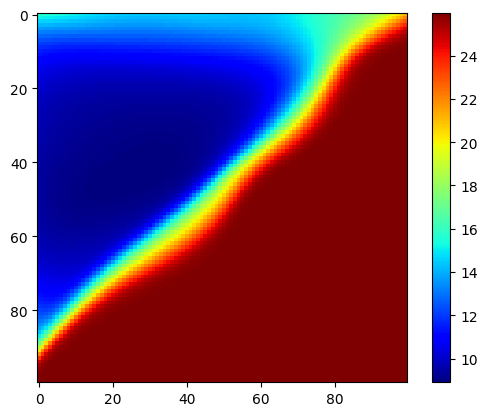

Epoch 0000  loss over 1250  batches  Loss 1 = 0.89327347 Loss 2 = 0.64405155 Loss 3 = 0.18921651 Loss 4 = 0.29529321


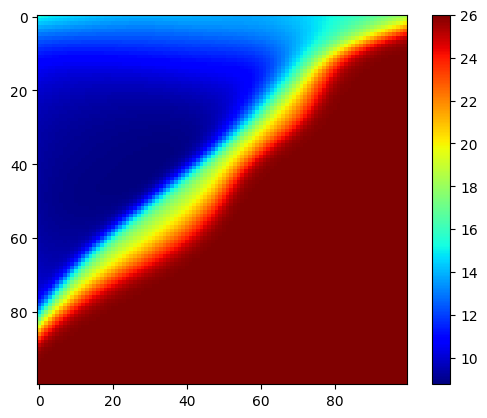

Epoch 0001  loss over 1250  batches  Loss 1 = 0.40553048 Loss 2 = 0.37348691 Loss 3 = 0.04403576 Loss 4 = 0.12476023


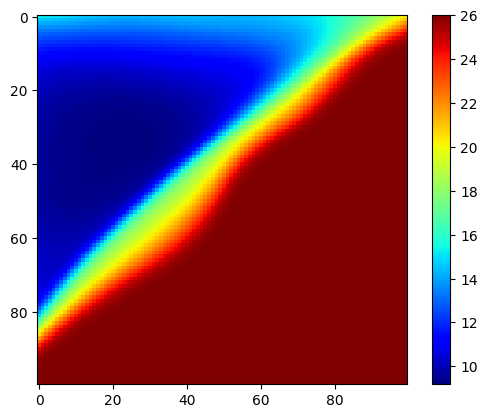

Epoch 0002  loss over 1250  batches  Loss 1 = 0.33411500 Loss 2 = 0.27720252 Loss 3 = 0.02813405 Loss 4 = 0.08212200


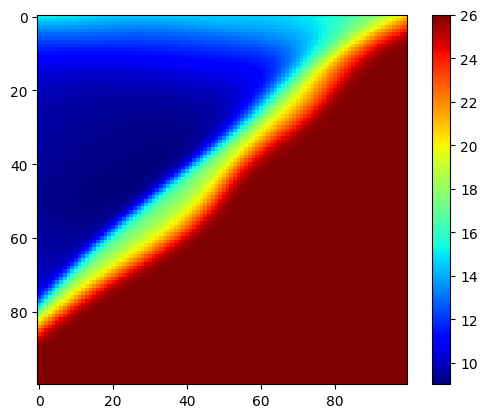

Epoch 0003  loss over 1250  batches  Loss 1 = 0.31594029 Loss 2 = 0.25046423 Loss 3 = 0.04411358 Loss 4 = 0.09588658


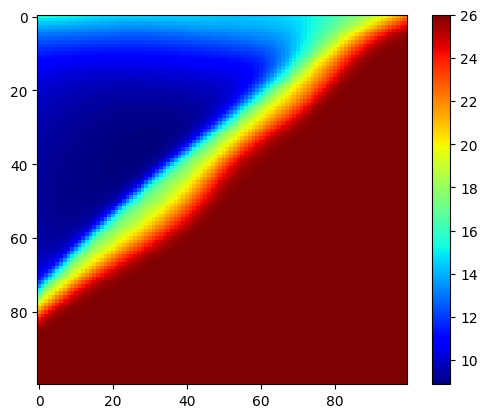

Epoch 0004  loss over 1250  batches  Loss 1 = 0.30104634 Loss 2 = 0.23001322 Loss 3 = 0.02135168 Loss 4 = 0.07171128


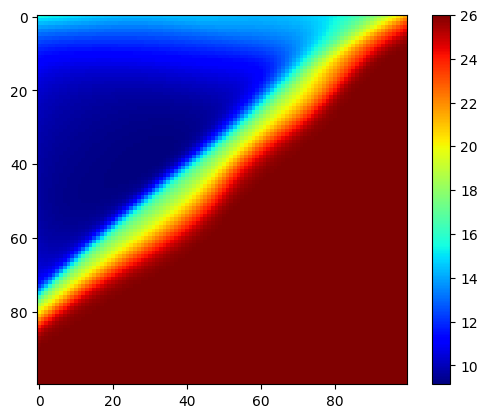

Epoch 0005  loss over 1250  batches  Loss 1 = 0.24890399 Loss 2 = 0.19846198 Loss 3 = 0.01554050 Loss 4 = 0.05261469


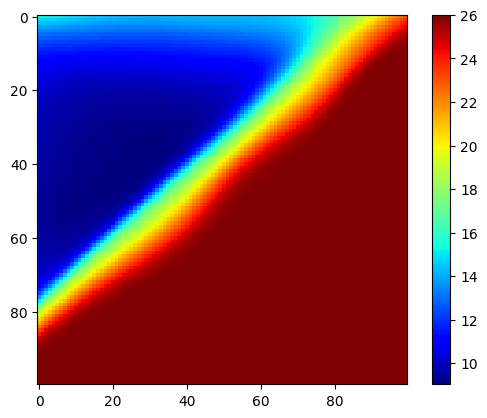

Epoch 0006  loss over 1250  batches  Loss 1 = 0.22487567 Loss 2 = 0.17438382 Loss 3 = 0.01378731 Loss 4 = 0.03880251


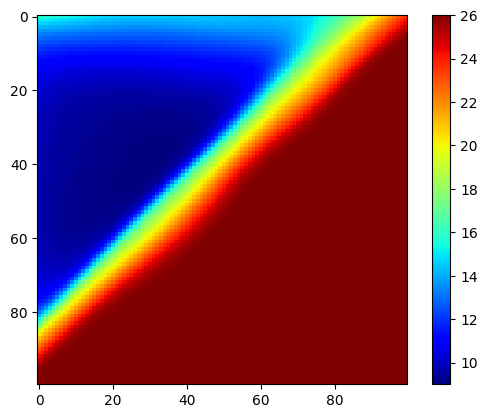

Epoch 0007  loss over 1250  batches  Loss 1 = 0.22776146 Loss 2 = 0.17630607 Loss 3 = 0.02228328 Loss 4 = 0.06020594


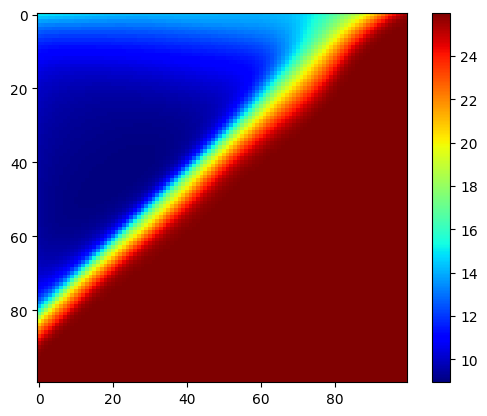

Epoch 0008  loss over 1250  batches  Loss 1 = 0.20673379 Loss 2 = 0.15388235 Loss 3 = 0.00994861 Loss 4 = 0.05077121


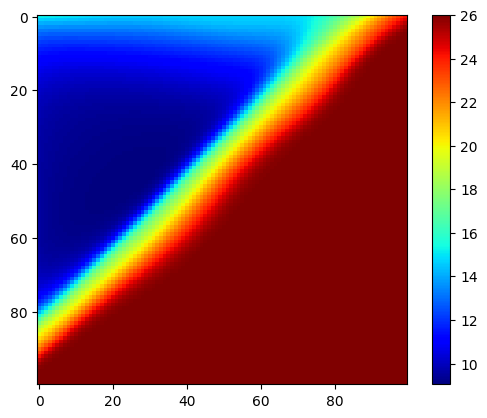

Epoch 0009  loss over 1250  batches  Loss 1 = 0.18826233 Loss 2 = 0.14595430 Loss 3 = 0.01247889 Loss 4 = 0.04425383


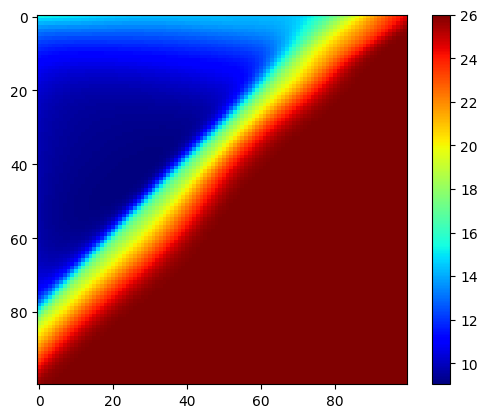

Epoch 0010  loss over 1250  batches  Loss 1 = 0.17263526 Loss 2 = 0.13120162 Loss 3 = 0.00638560 Loss 4 = 0.03268206


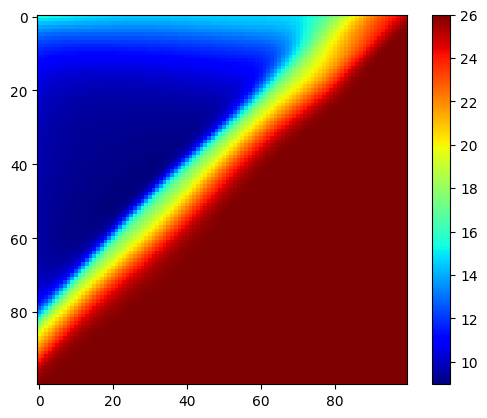

Epoch 0011  loss over 1250  batches  Loss 1 = 0.16048989 Loss 2 = 0.11946715 Loss 3 = 0.00860908 Loss 4 = 0.02754050


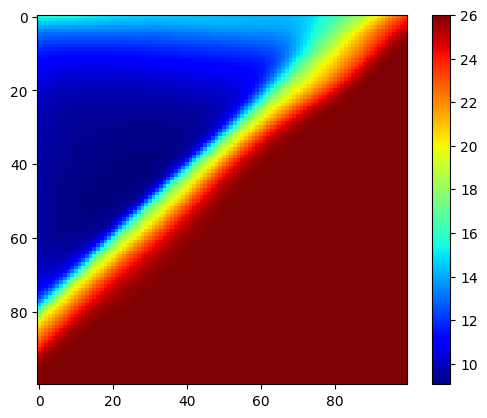

Epoch 0012  loss over 1250  batches  Loss 1 = 0.15704006 Loss 2 = 0.11612072 Loss 3 = 0.00540583 Loss 4 = 0.02724314


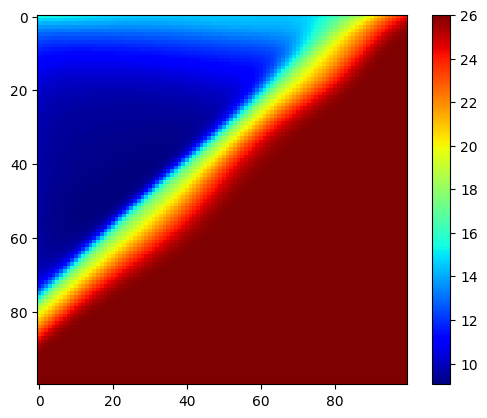

Epoch 0013  loss over 1250  batches  Loss 1 = 0.15291700 Loss 2 = 0.11058271 Loss 3 = 0.00962809 Loss 4 = 0.03869870


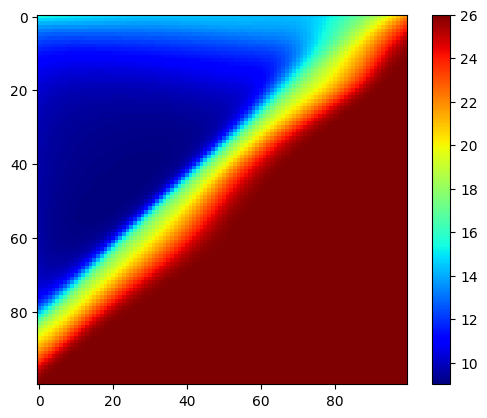

Epoch 0014  loss over 1250  batches  Loss 1 = 0.15097649 Loss 2 = 0.10375859 Loss 3 = 0.00564879 Loss 4 = 0.02492581


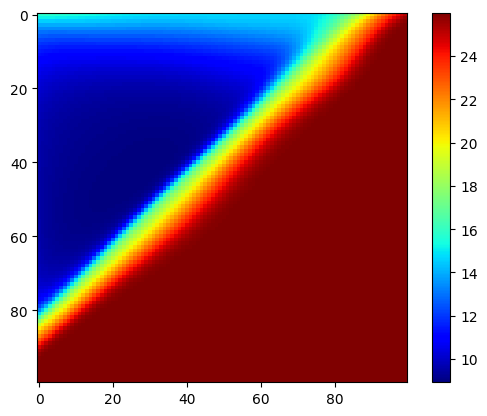

Epoch 0015  loss over 1250  batches  Loss 1 = 0.15173468 Loss 2 = 0.10974943 Loss 3 = 0.00340529 Loss 4 = 0.02741314


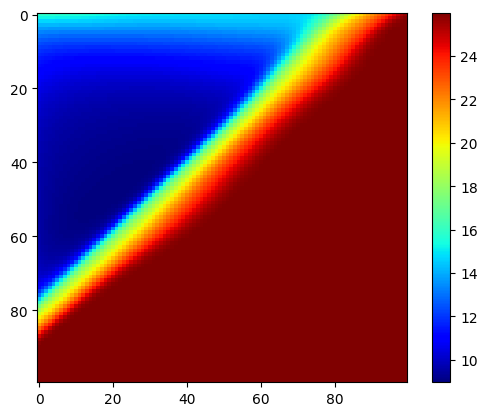

Epoch 0016  loss over 1250  batches  Loss 1 = 0.13906594 Loss 2 = 0.09442201 Loss 3 = 0.00906678 Loss 4 = 0.03719828


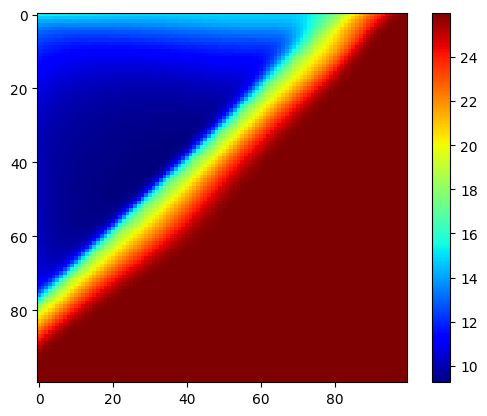

Epoch 0017  loss over 1250  batches  Loss 1 = 0.12749089 Loss 2 = 0.09000006 Loss 3 = 0.00281012 Loss 4 = 0.02004414


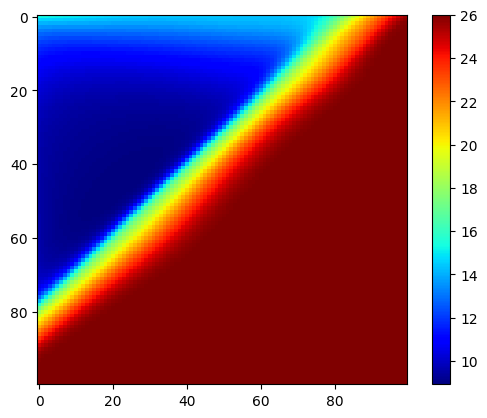

Epoch 0018  loss over 1250  batches  Loss 1 = 0.11836339 Loss 2 = 0.07816190 Loss 3 = 0.00779594 Loss 4 = 0.01774998


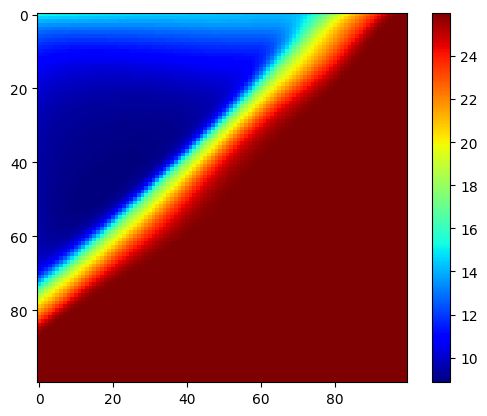

Epoch 0019  loss over 1250  batches  Loss 1 = 0.13052875 Loss 2 = 0.08713681 Loss 3 = 0.00559222 Loss 4 = 0.02174504


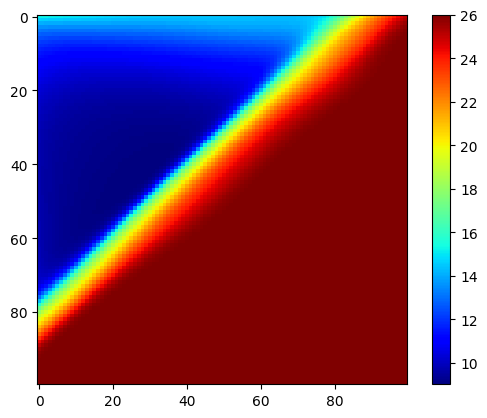

Epoch 0020  loss over 1250  batches  Loss 1 = 0.11092415 Loss 2 = 0.07624773 Loss 3 = 0.00451463 Loss 4 = 0.01638035


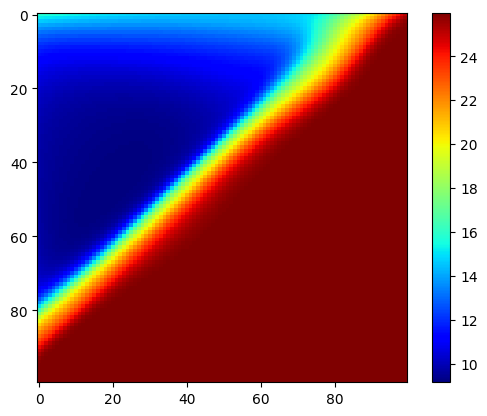

Epoch 0021  loss over 1250  batches  Loss 1 = 0.13520712 Loss 2 = 0.08615642 Loss 3 = 0.00366357 Loss 4 = 0.02186943


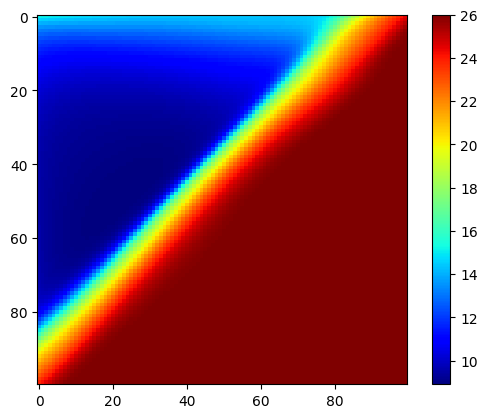

Epoch 0022  loss over 1250  batches  Loss 1 = 0.10849226 Loss 2 = 0.07729220 Loss 3 = 0.00742110 Loss 4 = 0.01823809


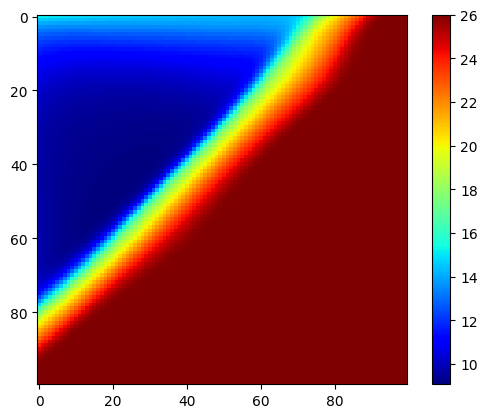

Epoch 0023  loss over 1250  batches  Loss 1 = 0.10449824 Loss 2 = 0.06870753 Loss 3 = 0.01056407 Loss 4 = 0.01561627


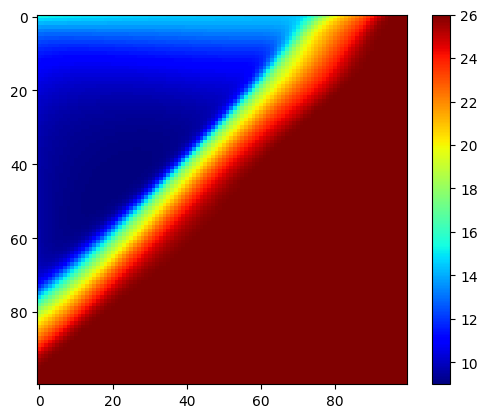

Epoch 0024  loss over 1250  batches  Loss 1 = 0.13235588 Loss 2 = 0.07808711 Loss 3 = 0.00650274 Loss 4 = 0.02053985


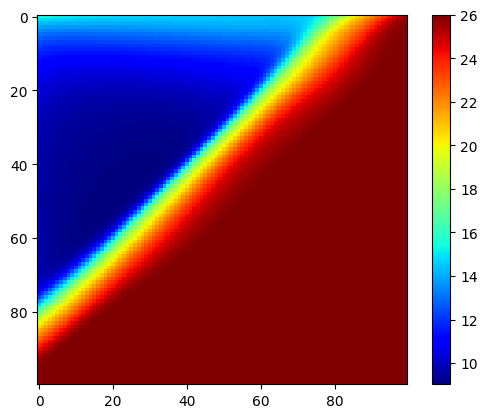

Epoch 0025  loss over 1250  batches  Loss 1 = 0.08853225 Loss 2 = 0.06053904 Loss 3 = 0.00377435 Loss 4 = 0.00991448


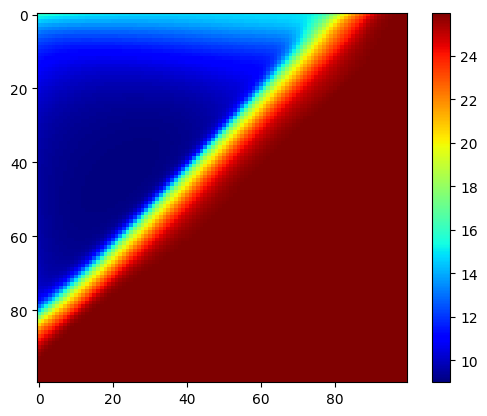

Epoch 0026  loss over 1250  batches  Loss 1 = 0.12710267 Loss 2 = 0.08971722 Loss 3 = 0.01268341 Loss 4 = 0.03901791


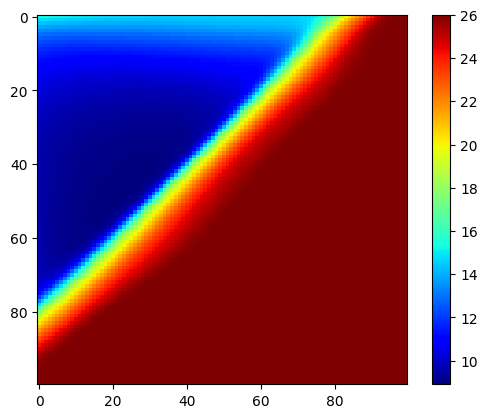

Epoch 0027  loss over 1250  batches  Loss 1 = 0.09513642 Loss 2 = 0.06338068 Loss 3 = 0.00335022 Loss 4 = 0.01817416


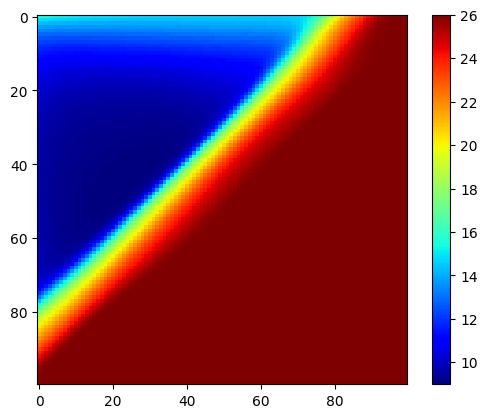

Epoch 0028  loss over 1250  batches  Loss 1 = 0.10283507 Loss 2 = 0.06997855 Loss 3 = 0.00265125 Loss 4 = 0.01301483


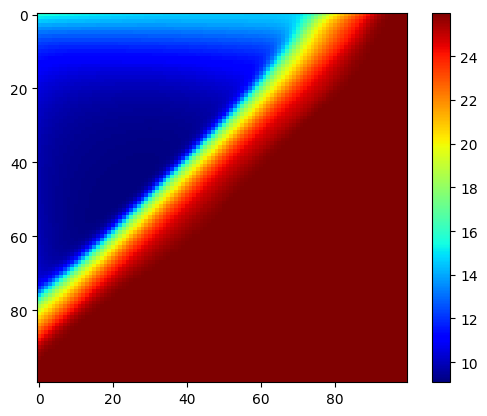

Epoch 0029  loss over 1250  batches  Loss 1 = 0.10800285 Loss 2 = 0.06749743 Loss 3 = 0.00361499 Loss 4 = 0.02137912


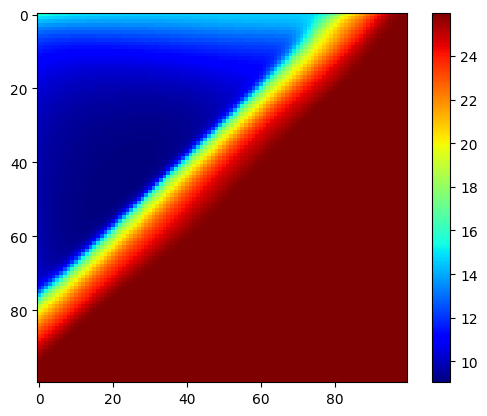

Epoch 0030  loss over 1250  batches  Loss 1 = 0.09199316 Loss 2 = 0.05846108 Loss 3 = 0.00173068 Loss 4 = 0.00980958


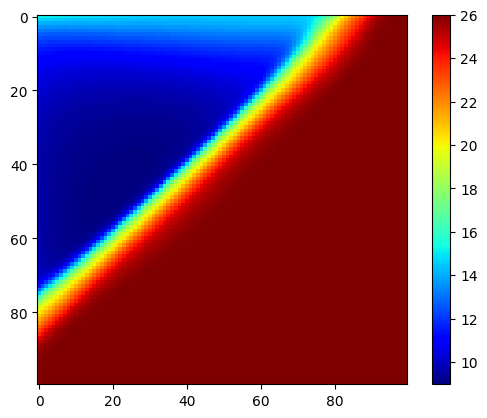

Epoch 0031  loss over 1250  batches  Loss 1 = 0.10117045 Loss 2 = 0.06515050 Loss 3 = 0.00286508 Loss 4 = 0.01862384


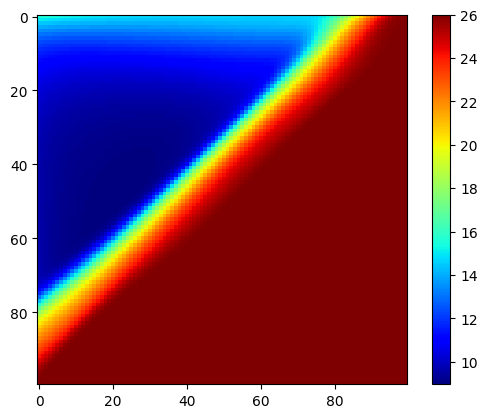

Epoch 0032  loss over 1250  batches  Loss 1 = 0.08511686 Loss 2 = 0.05135722 Loss 3 = 0.00227178 Loss 4 = 0.01143384


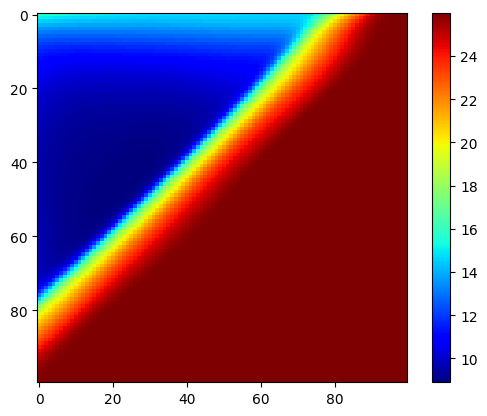

Epoch 0033  loss over 1250  batches  Loss 1 = 0.10021603 Loss 2 = 0.06130332 Loss 3 = 0.00329665 Loss 4 = 0.01820197


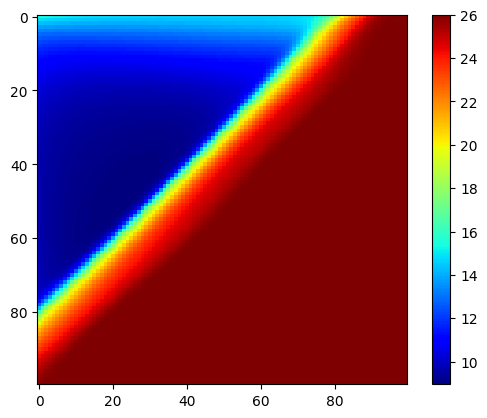

Epoch 0034  loss over 1250  batches  Loss 1 = 0.06920826 Loss 2 = 0.04589133 Loss 3 = 0.00058899 Loss 4 = 0.00384758


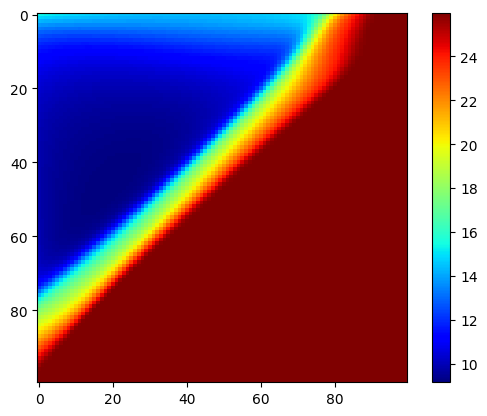

Epoch 0035  loss over 1250  batches  Loss 1 = 0.09898620 Loss 2 = 0.05784529 Loss 3 = 0.00290921 Loss 4 = 0.01130612


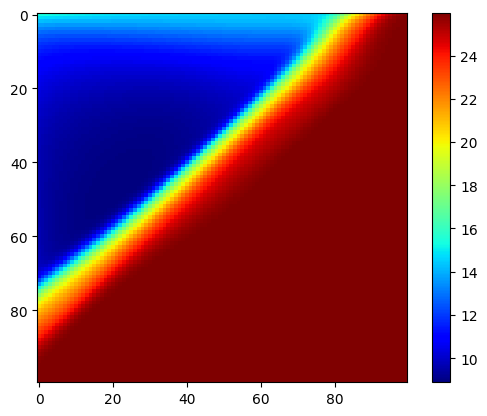

Epoch 0036  loss over 1250  batches  Loss 1 = 0.08401188 Loss 2 = 0.05821231 Loss 3 = 0.00200822 Loss 4 = 0.01329128


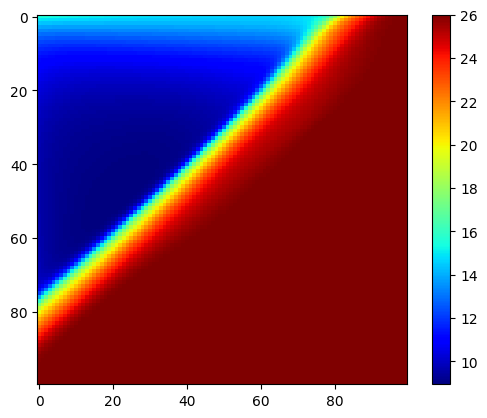

Epoch 0037  loss over 1250  batches  Loss 1 = 0.06908588 Loss 2 = 0.04392190 Loss 3 = 0.00055685 Loss 4 = 0.00501781


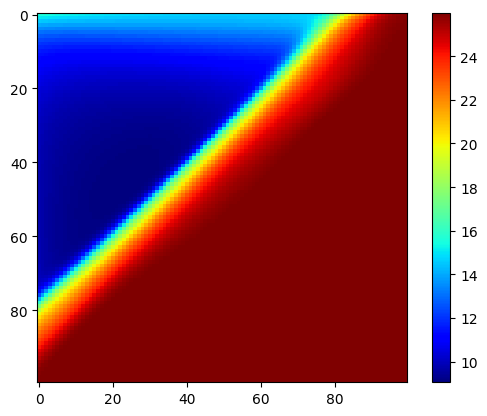

Epoch 0038  loss over 1250  batches  Loss 1 = 0.09923437 Loss 2 = 0.06015968 Loss 3 = 0.00470770 Loss 4 = 0.01138585


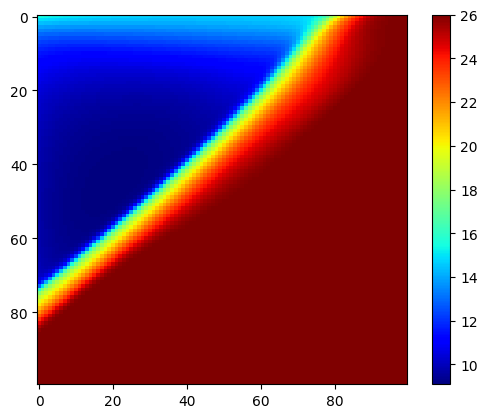

Epoch 0039  loss over 1250  batches  Loss 1 = 0.08266798 Loss 2 = 0.05192006 Loss 3 = 0.00062455 Loss 4 = 0.00817844


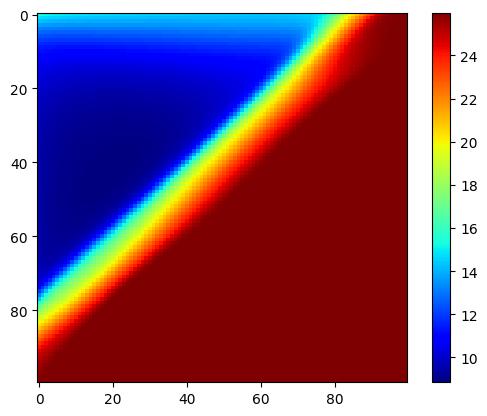

Epoch 0040  loss over 1250  batches  Loss 1 = 0.07680771 Loss 2 = 0.04953963 Loss 3 = 0.00141438 Loss 4 = 0.01309430


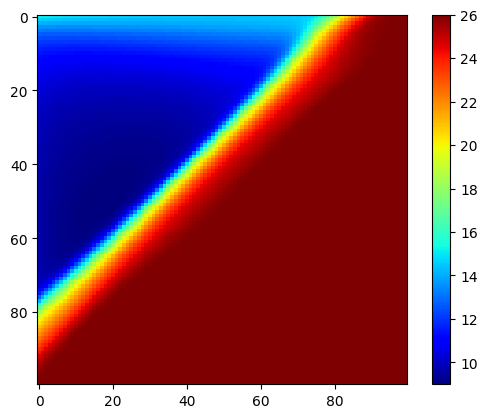

Epoch 0041  loss over 1250  batches  Loss 1 = 0.06596425 Loss 2 = 0.04188967 Loss 3 = 0.00202407 Loss 4 = 0.00924546


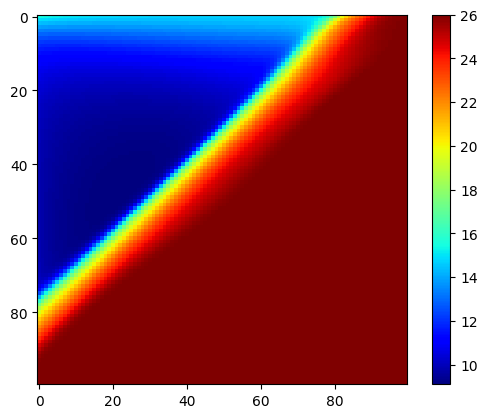

Epoch 0042  loss over 1250  batches  Loss 1 = 0.06737329 Loss 2 = 0.04628399 Loss 3 = 0.00131459 Loss 4 = 0.00477375


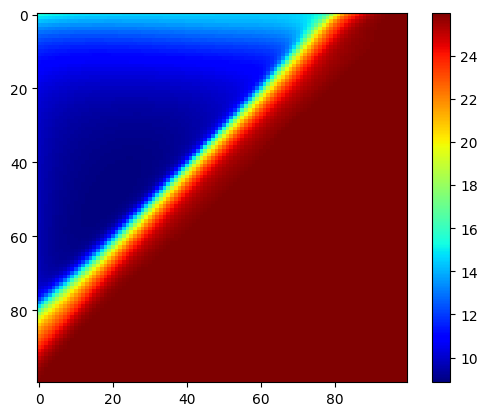

Epoch 0043  loss over 1250  batches  Loss 1 = 0.06472886 Loss 2 = 0.04204619 Loss 3 = 0.00049764 Loss 4 = 0.00489913


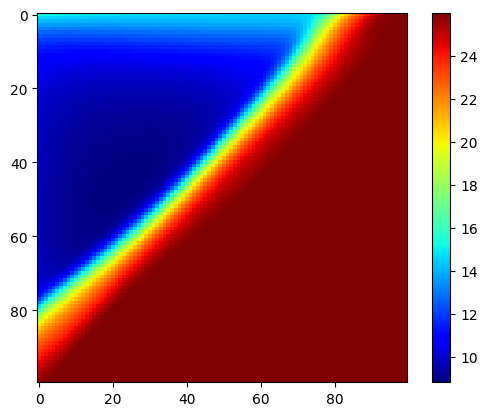

Epoch 0044  loss over 1250  batches  Loss 1 = 0.11539407 Loss 2 = 0.07069950 Loss 3 = 0.01682032 Loss 4 = 0.05184608


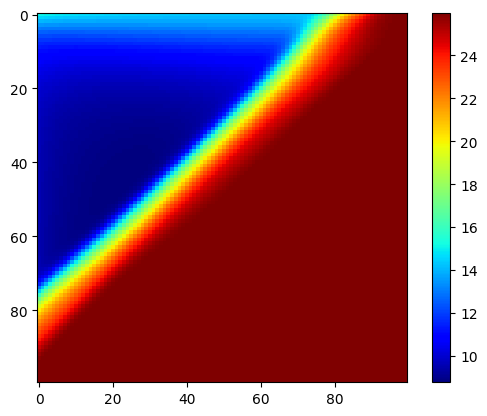

Epoch 0045  loss over 1250  batches  Loss 1 = 0.06021839 Loss 2 = 0.03797008 Loss 3 = 0.00010815 Loss 4 = 0.00568601


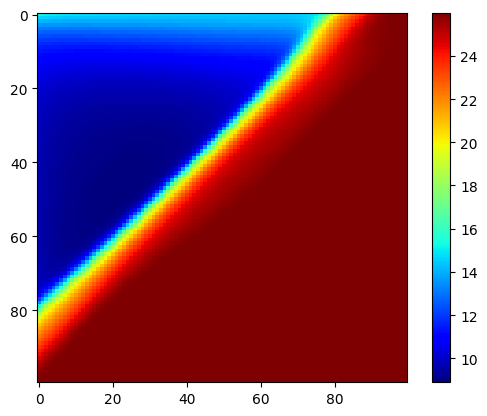

Epoch 0046  loss over 1250  batches  Loss 1 = 0.06990071 Loss 2 = 0.04450268 Loss 3 = 0.00193305 Loss 4 = 0.00725663


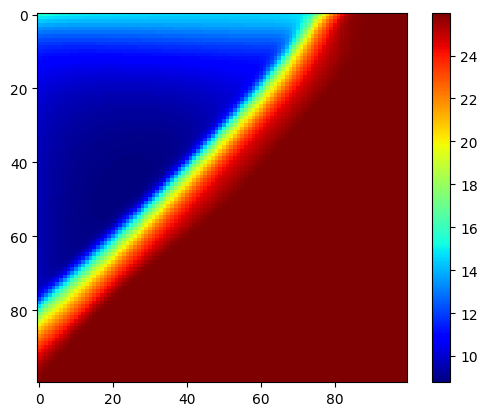

Epoch 0047  loss over 1250  batches  Loss 1 = 0.12247414 Loss 2 = 0.07271031 Loss 3 = 0.00311744 Loss 4 = 0.03345305


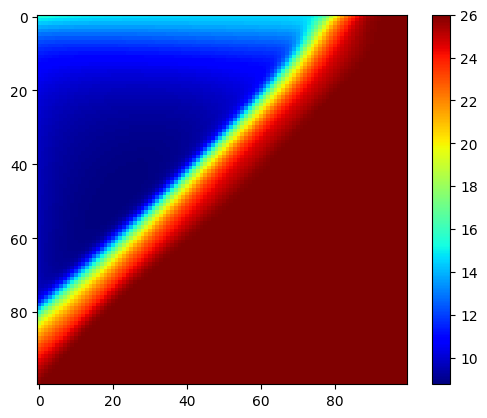

Epoch 0048  loss over 1250  batches  Loss 1 = 0.04892242 Loss 2 = 0.03214056 Loss 3 = 0.00057895 Loss 4 = 0.00134948


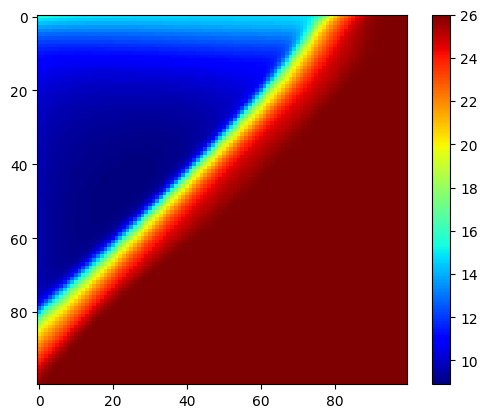

Epoch 0049  loss over 1250  batches  Loss 1 = 0.06234467 Loss 2 = 0.03537573 Loss 3 = 0.00039528 Loss 4 = 0.00320011


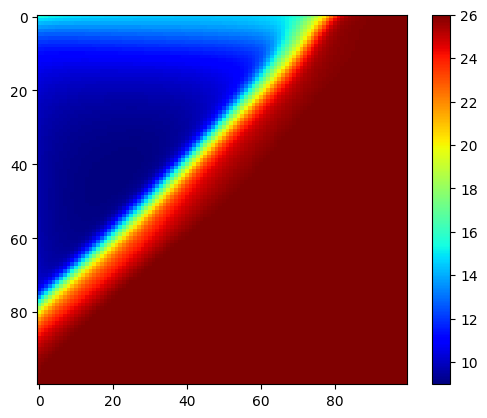

Epoch 0050  loss over 1250  batches  Loss 1 = 0.10141455 Loss 2 = 0.06563457 Loss 3 = 0.01608440 Loss 4 = 0.05860749


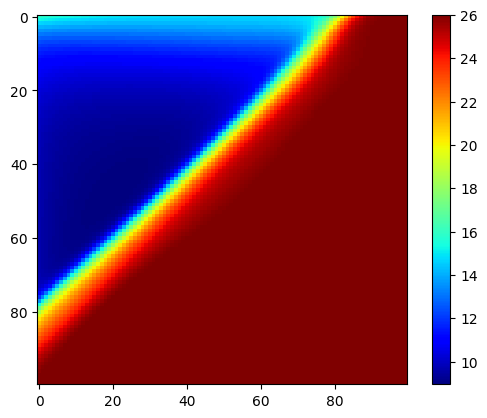

Epoch 0051  loss over 1250  batches  Loss 1 = 0.06997050 Loss 2 = 0.04396356 Loss 3 = 0.00035739 Loss 4 = 0.00929610


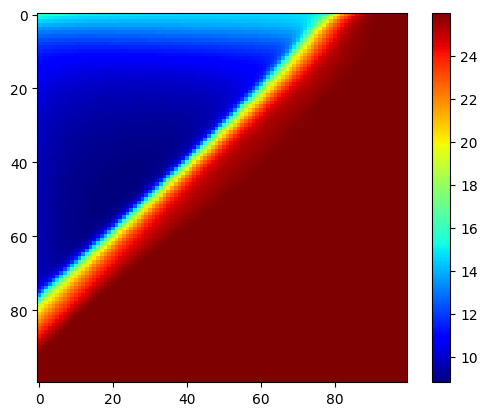

Epoch 0052  loss over 1250  batches  Loss 1 = 0.06091276 Loss 2 = 0.03427163 Loss 3 = 0.00031211 Loss 4 = 0.00566815


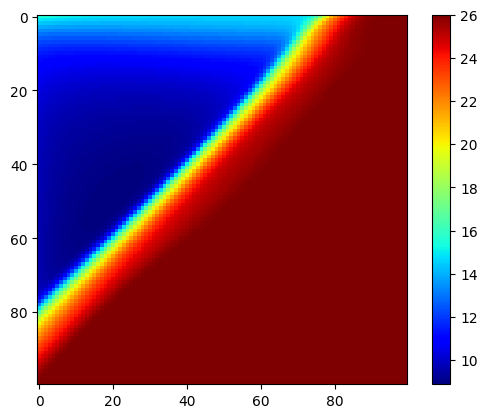

Epoch 0053  loss over 1250  batches  Loss 1 = 0.07021196 Loss 2 = 0.04436269 Loss 3 = 0.00030367 Loss 4 = 0.00543735


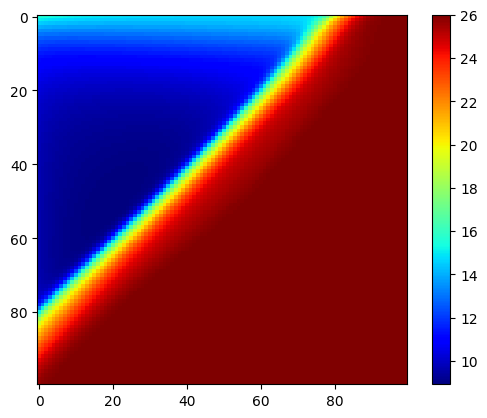

Epoch 0054  loss over 1250  batches  Loss 1 = 0.06541244 Loss 2 = 0.04347289 Loss 3 = 0.00082246 Loss 4 = 0.00603994


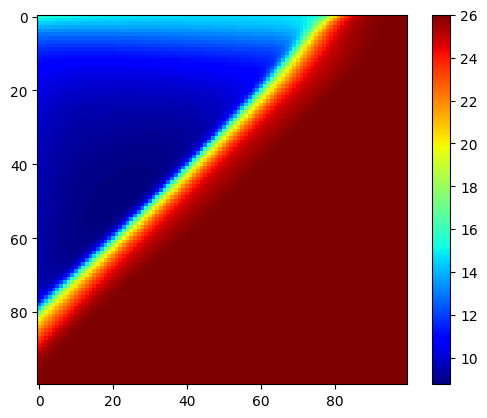

Epoch 0055  loss over 1250  batches  Loss 1 = 0.04894648 Loss 2 = 0.03050104 Loss 3 = 0.00018410 Loss 4 = 0.00136736


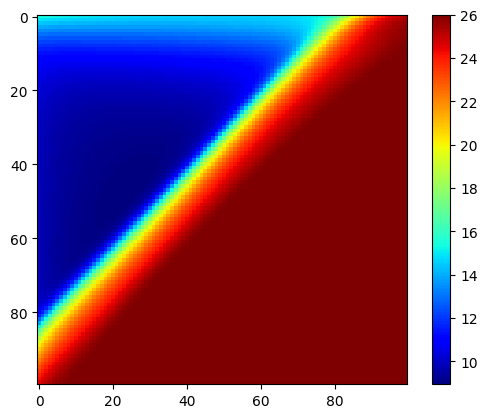

Epoch 0056  loss over 1250  batches  Loss 1 = 0.11843739 Loss 2 = 0.06488128 Loss 3 = 0.03094137 Loss 4 = 0.07046923


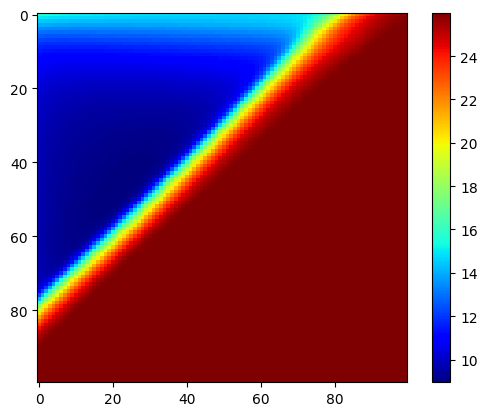

Epoch 0057  loss over 1250  batches  Loss 1 = 0.06663210 Loss 2 = 0.04161892 Loss 3 = 0.00208587 Loss 4 = 0.01049948


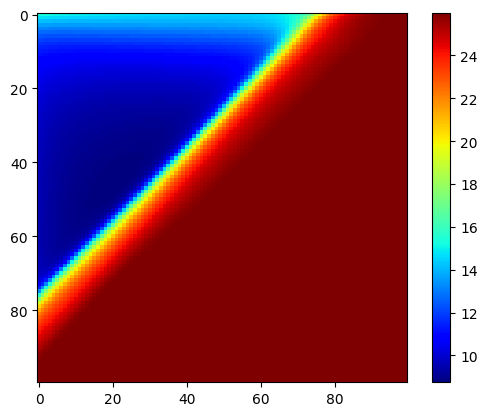

Epoch 0058  loss over 1250  batches  Loss 1 = 0.06319816 Loss 2 = 0.04079770 Loss 3 = 0.00430806 Loss 4 = 0.02035782


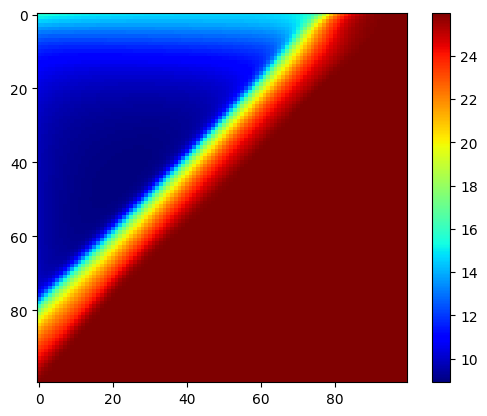

Epoch 0059  loss over 1250  batches  Loss 1 = 0.06830590 Loss 2 = 0.03780450 Loss 3 = 0.00054512 Loss 4 = 0.00748035


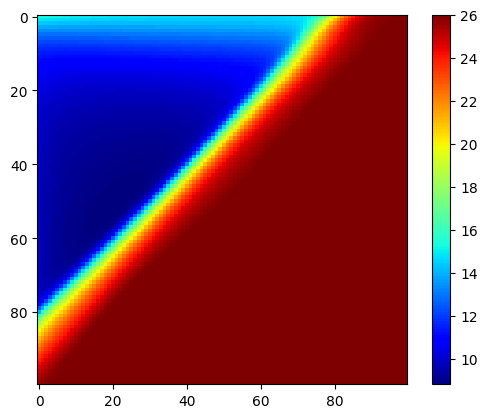

Epoch 0060  loss over 1250  batches  Loss 1 = 0.04520610 Loss 2 = 0.02965998 Loss 3 = 0.00042944 Loss 4 = 0.00752474


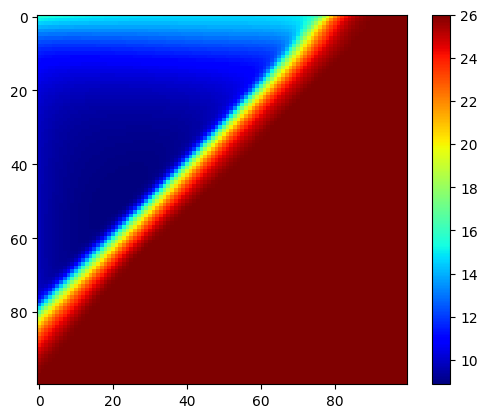

Epoch 0061  loss over 1250  batches  Loss 1 = 0.07387820 Loss 2 = 0.04481380 Loss 3 = 0.00144606 Loss 4 = 0.01679691


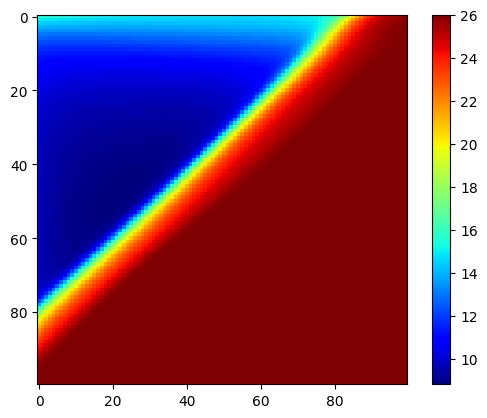

Epoch 0062  loss over 1250  batches  Loss 1 = 0.04584076 Loss 2 = 0.02667882 Loss 3 = 0.00090183 Loss 4 = 0.00858565


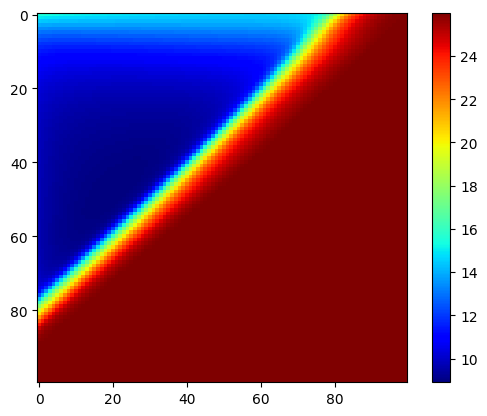

Epoch 0063  loss over 1250  batches  Loss 1 = 0.05416477 Loss 2 = 0.02994130 Loss 3 = 0.00109145 Loss 4 = 0.00445421


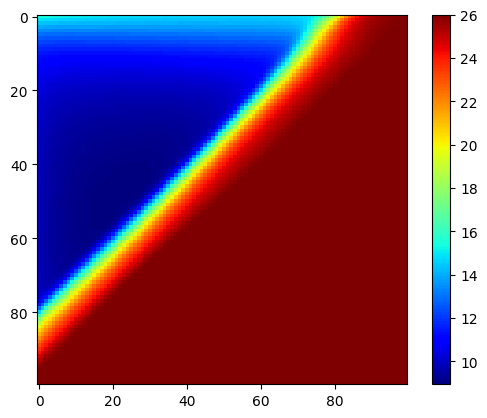

Epoch 0064  loss over 1250  batches  Loss 1 = 0.06484130 Loss 2 = 0.03490246 Loss 3 = 0.00027322 Loss 4 = 0.00627722


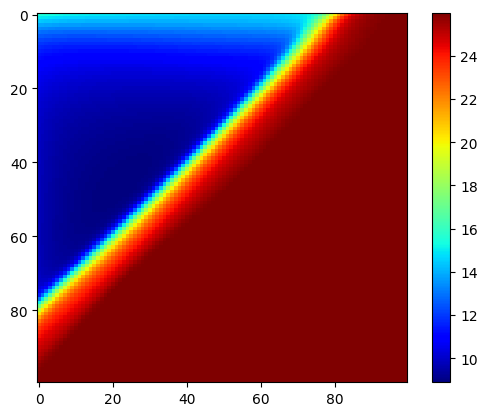

Epoch 0065  loss over 1250  batches  Loss 1 = 0.05043735 Loss 2 = 0.03080054 Loss 3 = 0.00023103 Loss 4 = 0.00300877


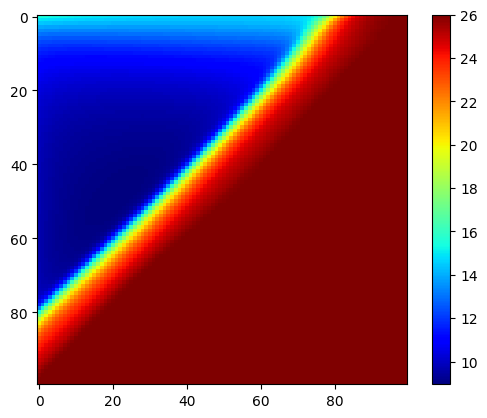

Epoch 0066  loss over 1250  batches  Loss 1 = 0.04798335 Loss 2 = 0.02635272 Loss 3 = 0.00010442 Loss 4 = 0.00227117


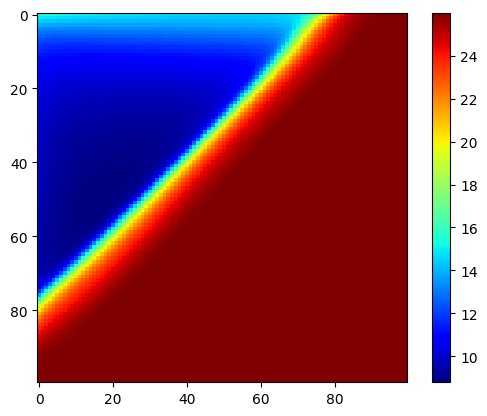

Epoch 0067  loss over 1250  batches  Loss 1 = 0.06837823 Loss 2 = 0.04105039 Loss 3 = 0.00824684 Loss 4 = 0.02776375


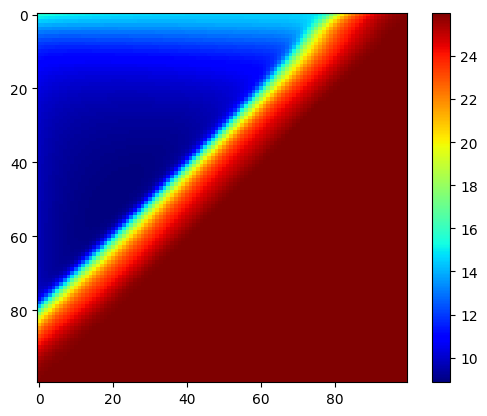

Epoch 0068  loss over 1250  batches  Loss 1 = 0.04781838 Loss 2 = 0.02716191 Loss 3 = 0.00035335 Loss 4 = 0.00420028


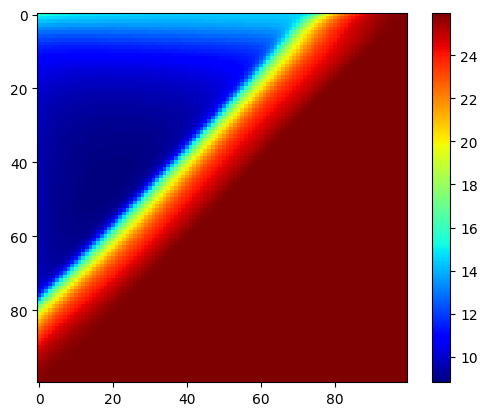

Epoch 0069  loss over 1250  batches  Loss 1 = 0.06226475 Loss 2 = 0.03590268 Loss 3 = 0.00126920 Loss 4 = 0.00800638


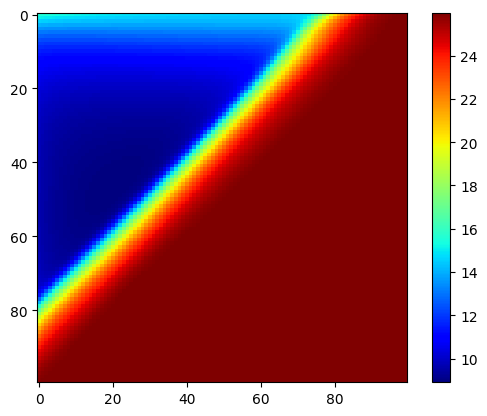

Epoch 0070  loss over 1250  batches  Loss 1 = 0.04294679 Loss 2 = 0.02602937 Loss 3 = 0.00058402 Loss 4 = 0.00326400


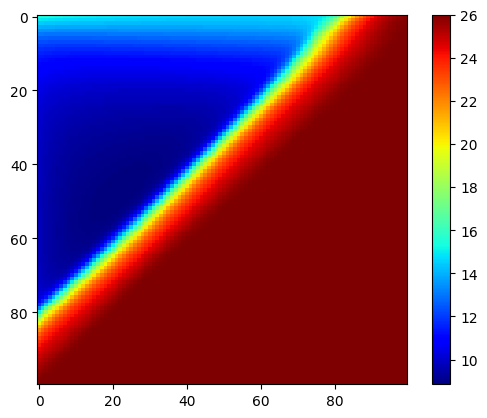

Epoch 0071  loss over 1250  batches  Loss 1 = 0.04922362 Loss 2 = 0.02774276 Loss 3 = 0.00125476 Loss 4 = 0.00940356


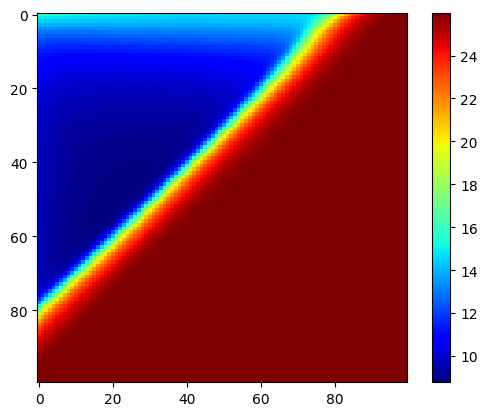

Epoch 0072  loss over 1250  batches  Loss 1 = 0.04627969 Loss 2 = 0.02928407 Loss 3 = 0.00012179 Loss 4 = 0.00289825


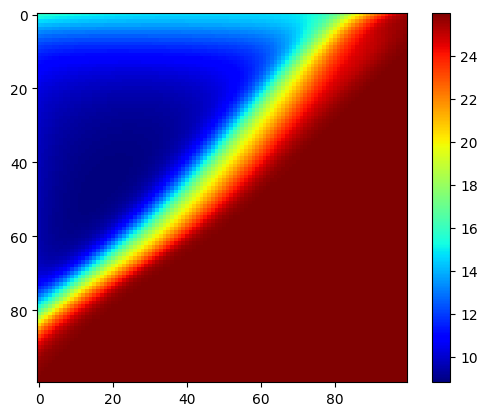

Epoch 0073  loss over 1250  batches  Loss 1 = 0.12448967 Loss 2 = 0.07268683 Loss 3 = 0.06540299 Loss 4 = 0.09295353


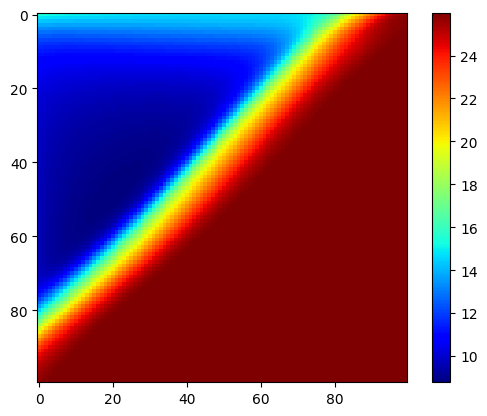

Epoch 0074  loss over 1250  batches  Loss 1 = 0.06324191 Loss 2 = 0.03281859 Loss 3 = 0.00397987 Loss 4 = 0.02362933


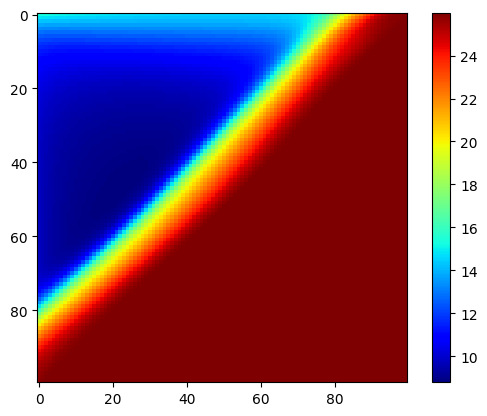

Epoch 0075  loss over 1250  batches  Loss 1 = 0.06433872 Loss 2 = 0.03450301 Loss 3 = 0.00143121 Loss 4 = 0.01106158


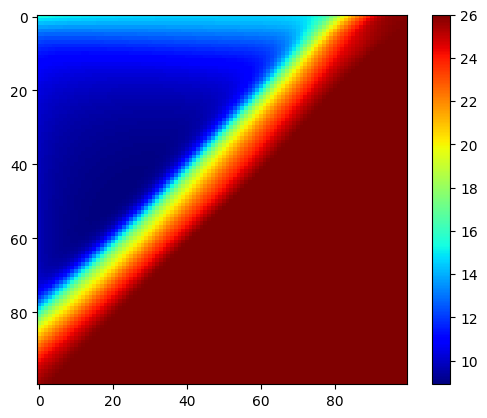

Epoch 0076  loss over 1250  batches  Loss 1 = 0.04883370 Loss 2 = 0.02933971 Loss 3 = 0.00062722 Loss 4 = 0.00698817


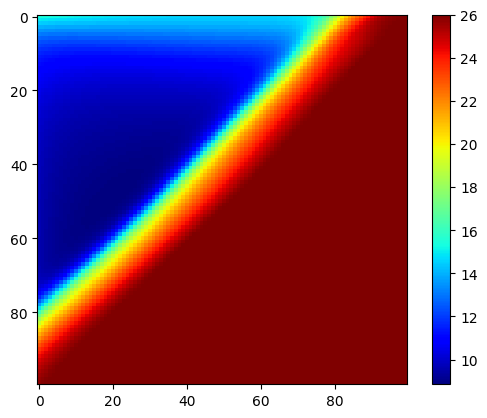

Epoch 0077  loss over 1250  batches  Loss 1 = 0.05588455 Loss 2 = 0.03267485 Loss 3 = 0.00067843 Loss 4 = 0.00495086


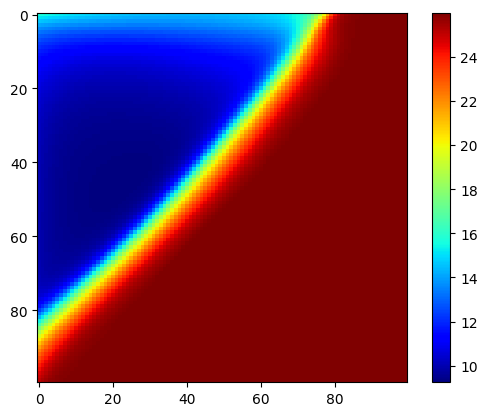

Epoch 0078  loss over 1250  batches  Loss 1 = 0.07123616 Loss 2 = 0.04269761 Loss 3 = 0.00082028 Loss 4 = 0.01085453


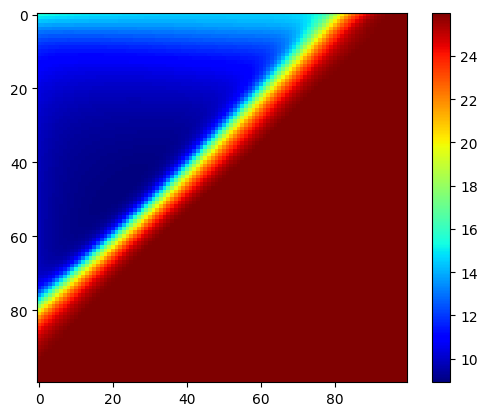

Epoch 0079  loss over 1250  batches  Loss 1 = 0.05738949 Loss 2 = 0.03365836 Loss 3 = 0.00122133 Loss 4 = 0.00545976


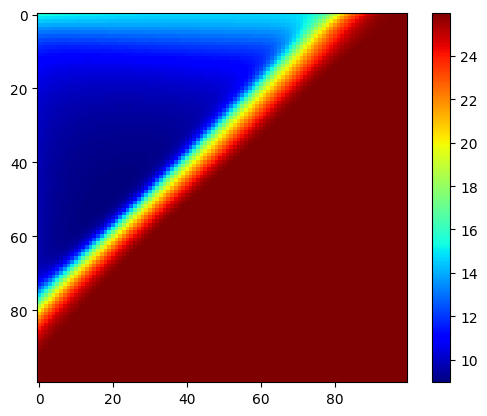

Epoch 0080  loss over 1250  batches  Loss 1 = 0.05158569 Loss 2 = 0.02541165 Loss 3 = 0.00044243 Loss 4 = 0.00236719


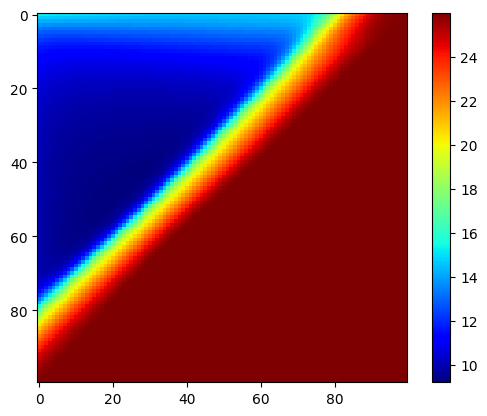

Epoch 0081  loss over 1250  batches  Loss 1 = 0.05317777 Loss 2 = 0.02730435 Loss 3 = 0.00015377 Loss 4 = 0.00472233


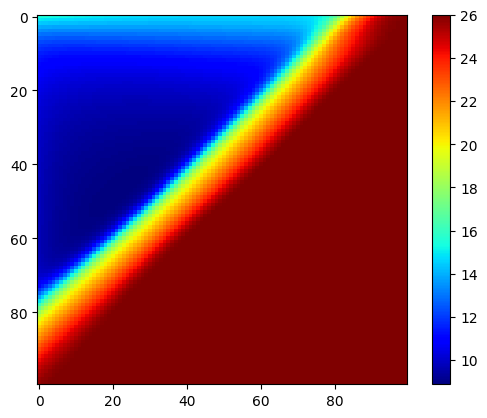

Epoch 0082  loss over 1250  batches  Loss 1 = 0.03979563 Loss 2 = 0.02088021 Loss 3 = 0.00050683 Loss 4 = 0.00213152


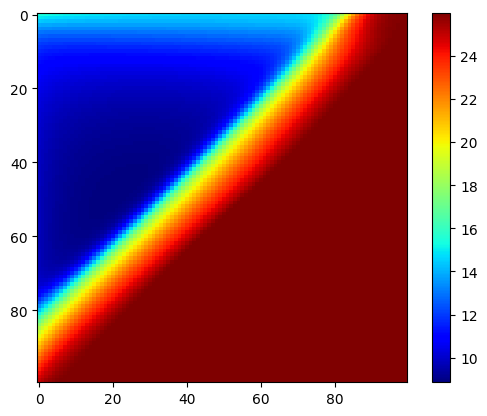

Epoch 0083  loss over 1250  batches  Loss 1 = 0.05961796 Loss 2 = 0.02972397 Loss 3 = 0.00031864 Loss 4 = 0.00725400


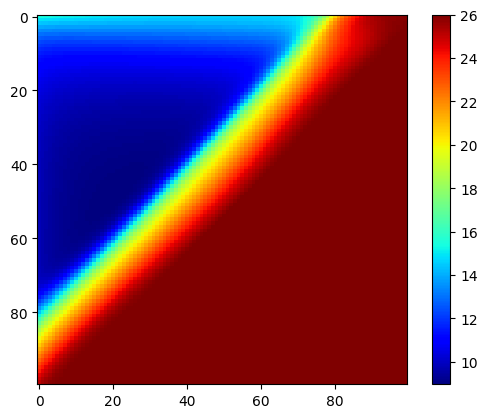

Epoch 0084  loss over 1250  batches  Loss 1 = 0.05279488 Loss 2 = 0.02839878 Loss 3 = 0.00100578 Loss 4 = 0.00946689


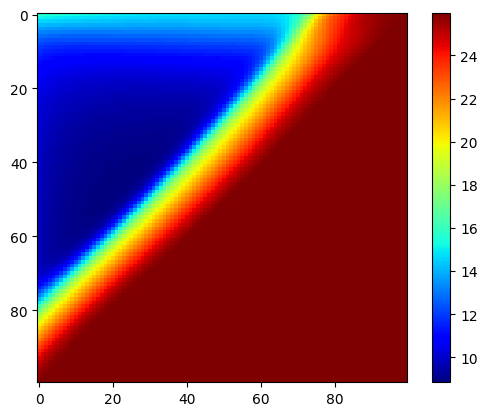

Epoch 0085  loss over 1250  batches  Loss 1 = 0.04879818 Loss 2 = 0.02443561 Loss 3 = 0.00011402 Loss 4 = 0.00297400


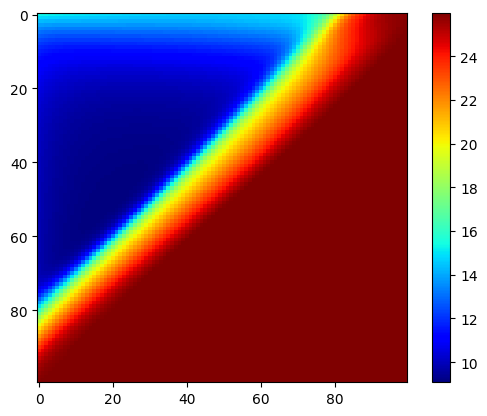

Epoch 0086  loss over 1250  batches  Loss 1 = 0.06897718 Loss 2 = 0.03587146 Loss 3 = 0.00071862 Loss 4 = 0.00594292


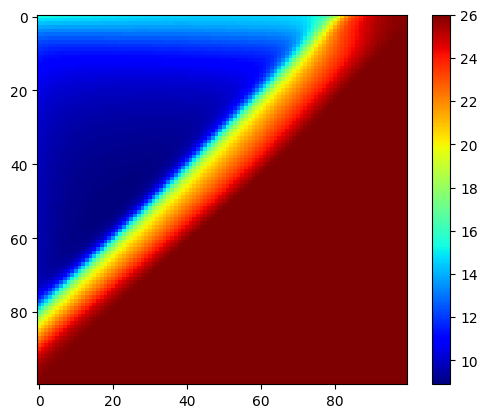

Epoch 0087  loss over 1250  batches  Loss 1 = 0.03731132 Loss 2 = 0.02007980 Loss 3 = 0.00040210 Loss 4 = 0.00031933


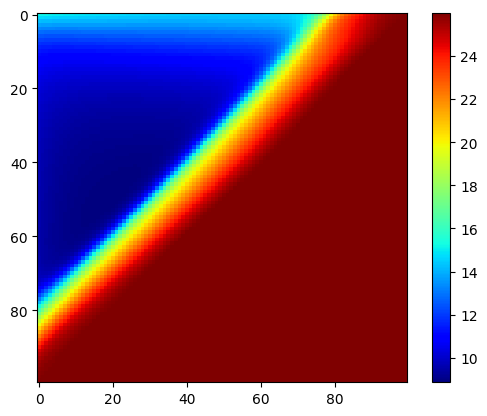

Epoch 0088  loss over 1250  batches  Loss 1 = 0.04231251 Loss 2 = 0.02239980 Loss 3 = 0.00006891 Loss 4 = 0.00171635


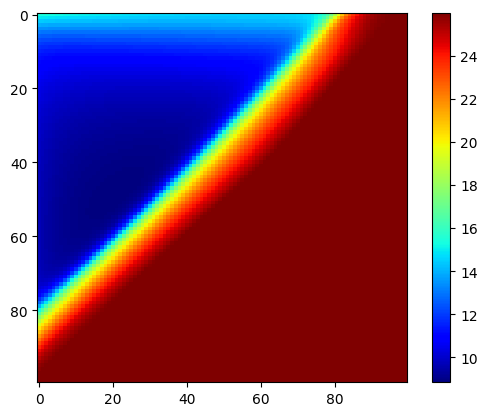

Epoch 0089  loss over 1250  batches  Loss 1 = 0.04955344 Loss 2 = 0.02604194 Loss 3 = 0.00110429 Loss 4 = 0.00291074


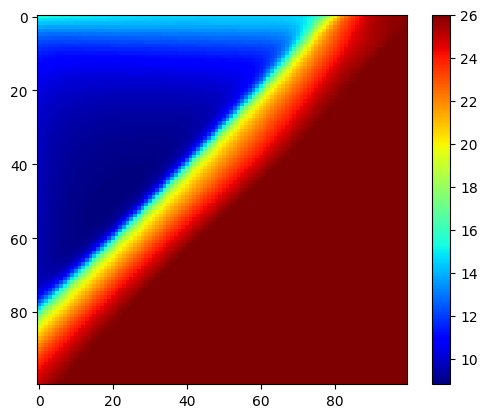

Epoch 0090  loss over 1250  batches  Loss 1 = 0.04632620 Loss 2 = 0.02302794 Loss 3 = 0.00182275 Loss 4 = 0.00219891


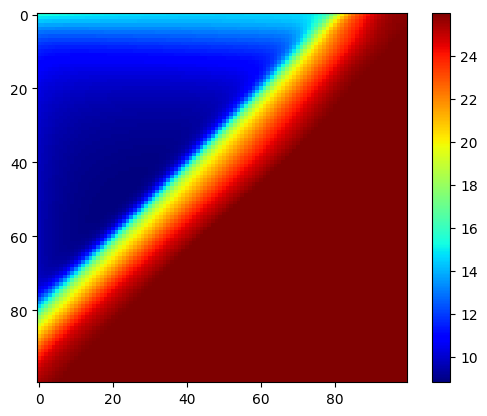

Epoch 0091  loss over 1250  batches  Loss 1 = 0.04521706 Loss 2 = 0.02362902 Loss 3 = 0.00133454 Loss 4 = 0.00310727


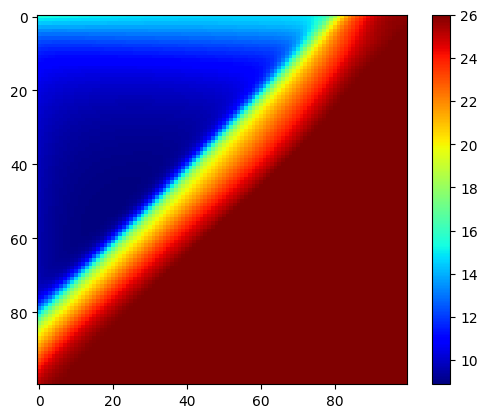

Epoch 0092  loss over 1250  batches  Loss 1 = 0.04658671 Loss 2 = 0.02243388 Loss 3 = 0.00042076 Loss 4 = 0.00326454


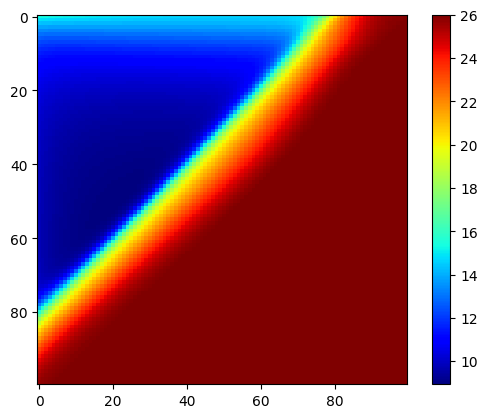

Epoch 0093  loss over 1250  batches  Loss 1 = 0.04327805 Loss 2 = 0.02434868 Loss 3 = 0.00143268 Loss 4 = 0.00582393


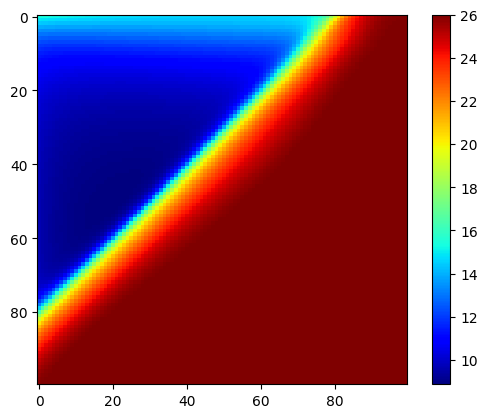

Epoch 0094  loss over 1250  batches  Loss 1 = 0.03941374 Loss 2 = 0.01940162 Loss 3 = 0.00031460 Loss 4 = 0.00150354


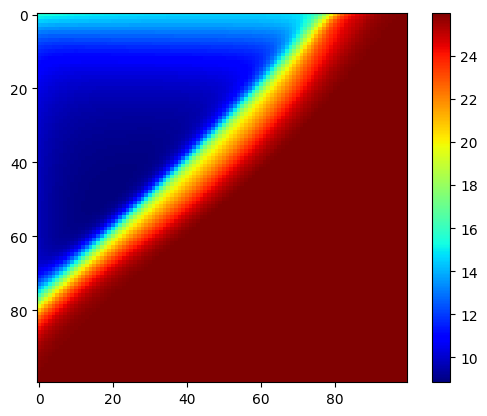

Epoch 0095  loss over 1250  batches  Loss 1 = 0.09138419 Loss 2 = 0.05481644 Loss 3 = 0.01930019 Loss 4 = 0.05639906


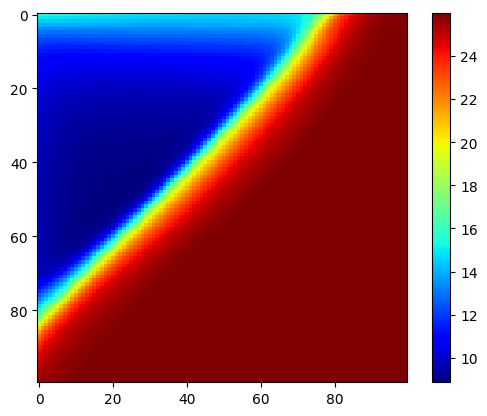

Epoch 0096  loss over 1250  batches  Loss 1 = 0.04354195 Loss 2 = 0.02137930 Loss 3 = 0.00021956 Loss 4 = 0.00768011


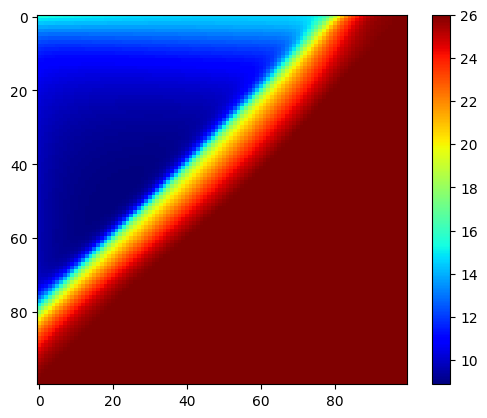

Epoch 0097  loss over 1250  batches  Loss 1 = 0.04611466 Loss 2 = 0.02381377 Loss 3 = 0.00031281 Loss 4 = 0.00582818


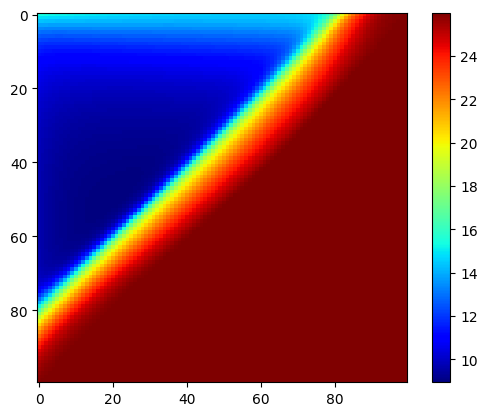

Epoch 0098  loss over 1250  batches  Loss 1 = 0.03917211 Loss 2 = 0.01942304 Loss 3 = 0.00009224 Loss 4 = 0.00156307


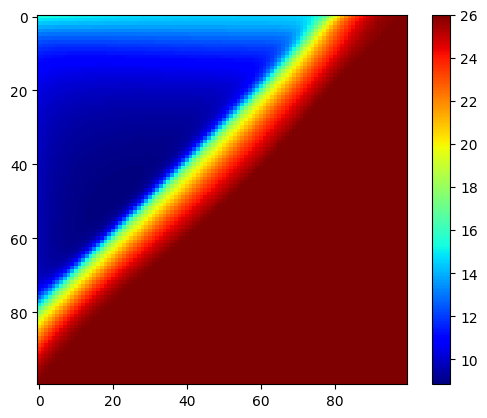

Epoch 0099  loss over 1250  batches  Loss 1 = 0.04493937 Loss 2 = 0.02184479 Loss 3 = 0.00023568 Loss 4 = 0.00342060
Time:  9347.602735416964
min =  100000


In [155]:
start = timeit.default_timer()
min = 100000;
batches = int(len(X_train_no_Y)/batch_size)
training_epochs = 100
opt1.learning_rate.assign(0.0005)
model = tf.keras.models.load_model('h5_files/FC2_50.keras')
for epoch in range(training_epochs):
    losses1 = 0
    losses2 = 0
    losses3 = 0
    losses4 = 0
    for j in range(batches):
#    for j in range(1):
        index1 = np.random.randint(X_train1.shape[0], size=batch_size)
        index2 = np.random.randint(X_train_no_Y.shape[0], size=batch_size)
        index3 = np.random.randint(X_train3.shape[0], size=batch_size)
        index4 = np.random.randint(X_train4.shape[0], size=batch_size)
        X_b = tf.gather(X_train1_t, index1)
        Y_b = tf.gather(Y_train1_t, index1)
        X_c = tf.gather(X_train_no_Y_t, index2)
        X_e = tf.gather(X_train3_t, index3)
        Y_e = tf.gather(Y_train3_t, index3)
        X_f = tf.gather(X_train4_t, index4)
        
        #Loss = train_step_one_loss(X_b, Y_b, X_c, X_e, Y_e, X_f)
        #losses1 = losses1 + Loss
        loss_1, loss_2, loss_3, loss_4 = train_step_one_loss(X_b, Y_b, X_c, X_e, Y_e, X_f)
        losses1 = losses1 + loss_1
        losses2 = losses2 + loss_2
        losses3 = losses3 + loss_3
        losses4 = losses4 + loss_4

        
    Y_VAL = model(X_test_t, training=False)
    fig = plt.figure()
    im = plt.imshow(np.reshape(Y_VAL, (100, 100)), cmap='jet', interpolation='nearest')
    cbar = plt.colorbar(im)
    plt.show()
    filename = 'h5_files/FC3_' + str(epoch) + '.keras'
    model.save(filename)
    
    #if losses1/batches + 0.2*losses2/batches < min:
    #    min = losses1/batches + 0.2*losses2/batches



    if epoch%1 == 0: #or losses1/batches < min:
        #print("Epoch %.4d " % epoch, "loss over", batches, " batches ", "Loss 1 = %.8f" % (losses1/batches))
        print("Epoch %.4d " % epoch, "loss over", batches, " batches ", "Loss 1 = %.8f" % (losses1/batches), "Loss 2 = %.8f" % (losses2/batches), "Loss 3 = %.8f" % (losses3/batches), "Loss 4 = %.8f" % (losses4/batches))

    
stop = timeit.default_timer()


print('Time: ', stop - start) 
print('min = ', min)


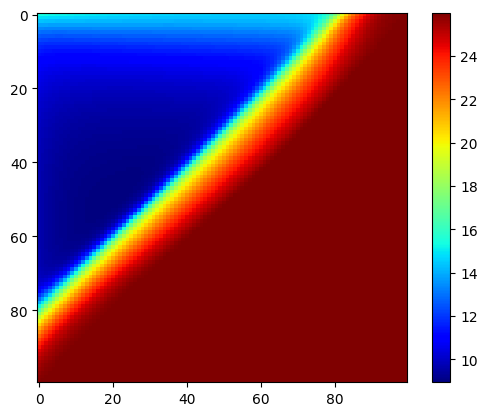

In [169]:
model = tf.keras.models.load_model('h5_files/FC3_98.keras')
steps = 100


Y_val = model(X_test_t, training=False)

fig = plt.figure()
im = plt.imshow(np.reshape(Y_val, (steps, steps)), cmap='jet', interpolation='nearest')
cbar = plt.colorbar(im)
plt.show()

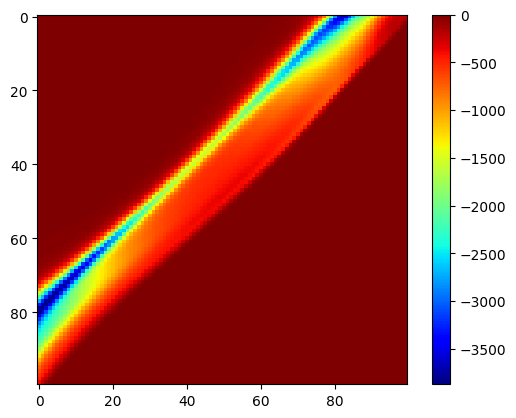

In [170]:
model = tf.keras.models.load_model('h5_files/FC3_98.keras')
X_c = X_test_t
with tf.GradientTape(persistent=True) as tape:               
        I1, I3, theta1, theta3 = X_c[...,0], X_c[...,1], X_c[...,2], X_c[...,3]
    
        tape.watch(X_c)
        y_pred = model(X_c, training=True)
        y_pred_t = tf.transpose(y_pred)                      
        grad_u = tape.gradient(y_pred_t, X_c)
        #print(grad_u.shape)
        U_I1 = grad_u[...,0]       
        U_I3 = grad_u[...,1]       
        U_theta1 = grad_u[...,2]       
        U_theta3 = grad_u[...,3]       
        
        U_I1I1 = tape.gradient(U_I1,X_c)[...,0]
        U_I3I3 = tape.gradient(U_I3,X_c)[...,1]
        U_theta1theta1 = tape.gradient(U_theta1,X_c)[...,2]
        U_theta3theta3 = tape.gradient(U_theta3,X_c)[...,3]
        Delta = tf.multiply(0.25*gam*T1*I1,U_I1I1) + tf.multiply(0.25*gam*T3*I3,U_I3I3) + tf.multiply(0.5*gam,U_theta1theta1) + tf.multiply(0.5*gam,U_theta3theta3)
        g1, g2, g3, g4 = f(X_c)
        Mu = tf.multiply(g1,U_I1) + tf.multiply(g2,U_I3) + tf.multiply(g3,U_theta1) + tf.multiply(g4,U_theta3) 
        generator = Mu + Delta 

fig = plt.figure()
im = plt.imshow(np.reshape(generator, (100, 100)), cmap='jet', interpolation='nearest')
cbar = plt.colorbar(im)
plt.show()
np.savetxt('FKE_LV_bound.txt', generator)

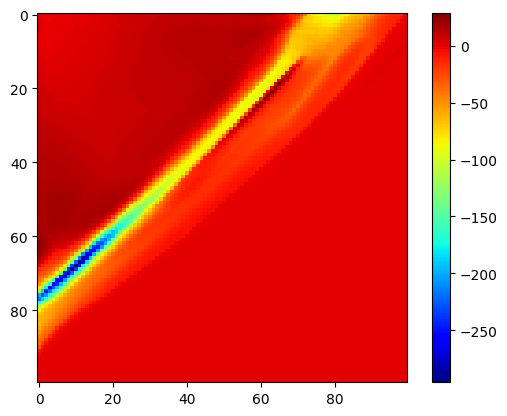

In [5]:
# compute maximum gradients

import tensorflow as tf
import numpy as np

model = tf.keras.models.load_model('h5_files/FC3_98.keras')
# Define the number of points for each dimension
d1_points = 100
d2_points = 100
d3_points = 100
d4_points = 100

LV = np.zeros((d1_points, d2_points))

# Create 1D tensors with coordinate values for each dimension
# For a grid spanning 0 to 1
dim1_coords = np.linspace(0.0, 12.0, d1_points)
dim2_coords = np.linspace(0.0, 12.0, d2_points)
dim3_coords = np.linspace(-np.pi, np.pi, d3_points)
dim4_coords = np.linspace(-np.pi, np.pi, d4_points)
tmp3, tmp4 = np.meshgrid(dim3_coords, dim4_coords, indexing='ij')
col3 = tmp3.ravel()
col4 = tmp4.ravel()
for i in range(d1_points):
#for i in range(1):
    for j in range(d2_points):
#    for j in range(1):
        xx = dim1_coords[i]
        yy = dim2_coords[j]
        col1 = xx*np.ones_like(col3)
        col2 = yy*np.ones_like(col3)
        stacked_grid = np.column_stack((col1, col2, col3, col4))
        X_grids = tf.convert_to_tensor(stacked_grid, dtype=tf.float32)
        X_c = X_grids
        with tf.GradientTape(persistent=True) as tape:               
            I1, I3, theta1, theta3 = X_c[...,0], X_c[...,1], X_c[...,2], X_c[...,3]
    
            tape.watch(X_c)
            y_pred = model(X_c, training=False)
            y_pred_t = tf.transpose(y_pred)                      
            grad_u = tape.gradient(y_pred_t, X_c)
            #print(grad_u.shape)
            U_I1 = grad_u[...,0]       
            U_I3 = grad_u[...,1]       
            U_theta1 = grad_u[...,2]       
            U_theta3 = grad_u[...,3]       
        
            U_I1I1 = tape.gradient(U_I1,X_c)[...,0]
            U_I3I3 = tape.gradient(U_I3,X_c)[...,1]
            U_theta1theta1 = tape.gradient(U_theta1,X_c)[...,2]
            U_theta3theta3 = tape.gradient(U_theta3,X_c)[...,3]
            Delta = tf.multiply(0.25*gam*T1*I1,U_I1I1) + tf.multiply(0.25*gam*T3*I3,U_I3I3) + tf.multiply(0.5*gam,U_theta1theta1) + tf.multiply(0.5*gam,U_theta3theta3)
            g1, g2, g3, g4 = f(X_c)
            Mu = tf.multiply(g1,U_I1) + tf.multiply(g2,U_I3) + tf.multiply(g3,U_theta1) + tf.multiply(g4,U_theta3) 
            generator = Mu + Delta
        LV[i,j] = np.max(generator)
        
fig = plt.figure()
im = plt.imshow(LV, cmap='jet', interpolation='nearest')
cbar = plt.colorbar(im)
plt.show()

In [163]:
np.savetxt('FKE_LQ_bound.txt', LV)

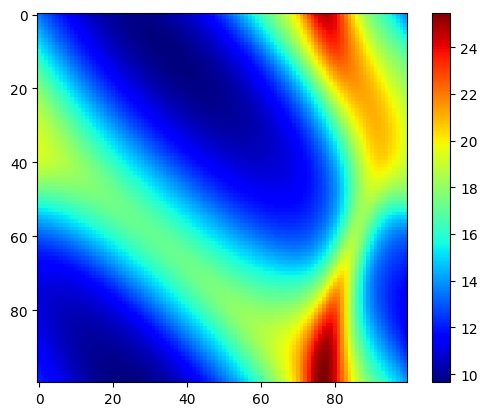

In [166]:
model = tf.keras.models.load_model('h5_files/FC3_98.keras')

steps = 100
X_test = np.loadtxt('FKE_X_test4.txt', dtype = np.float32, delimiter = ',')
X_test_t = tf.convert_to_tensor(X_test, dtype=tf.float32)

Y_val = model(X_test_t, training=False)

fig = plt.figure()
im = plt.imshow(np.reshape(Y_val, (steps, steps)), cmap='jet', interpolation='nearest')
cbar = plt.colorbar(im)
plt.show()

np.savetxt('FKE_Y_pred_4.txt', Y_val)

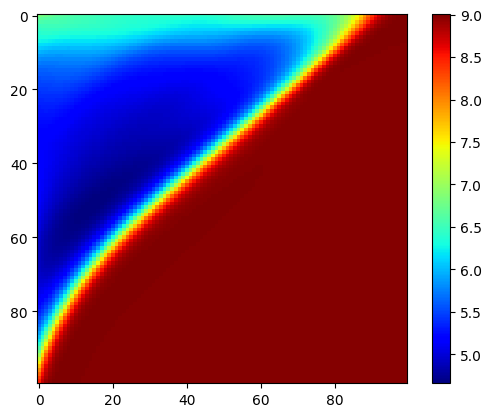

Epoch 0000  loss over 1250  batches  Loss 1 = 0.09433213 Loss 2 = 50.86851120 Loss 3 = 4.79845428


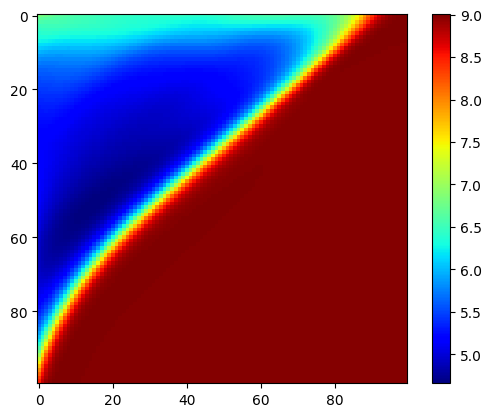

Epoch 0001  loss over 1250  batches  Loss 1 = 0.09008583 Loss 2 = 44.44088745 Loss 3 = 4.77043247


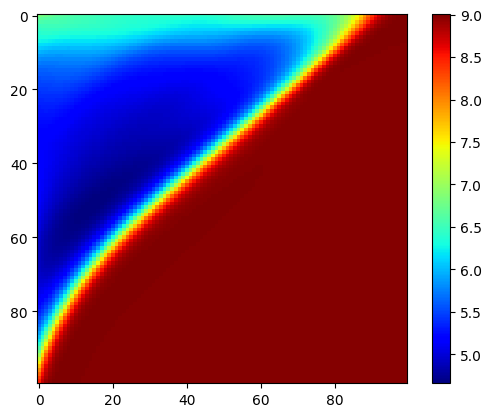

Epoch 0002  loss over 1250  batches  Loss 1 = 0.08790537 Loss 2 = 47.40708923 Loss 3 = 4.48975420


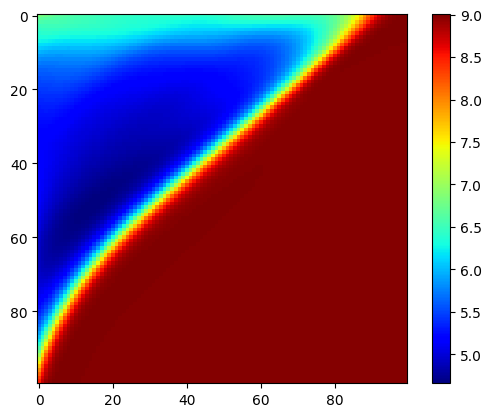

Epoch 0003  loss over 1250  batches  Loss 1 = 0.08522493 Loss 2 = 56.87347031 Loss 3 = 4.16814375


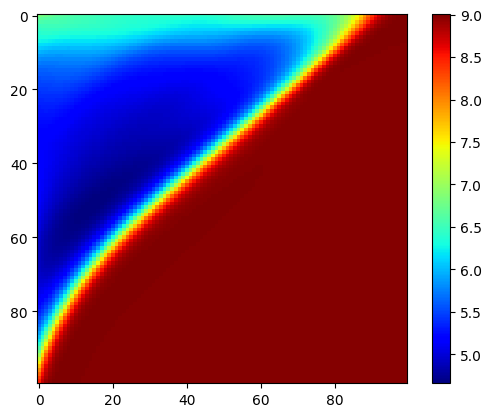

Epoch 0004  loss over 1250  batches  Loss 1 = 0.08086877 Loss 2 = 67.81602478 Loss 3 = 4.52518988


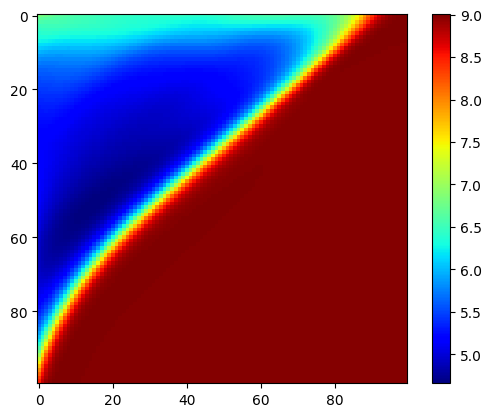

Epoch 0005  loss over 1250  batches  Loss 1 = 0.08427929 Loss 2 = 61.53398514 Loss 3 = 5.49148989


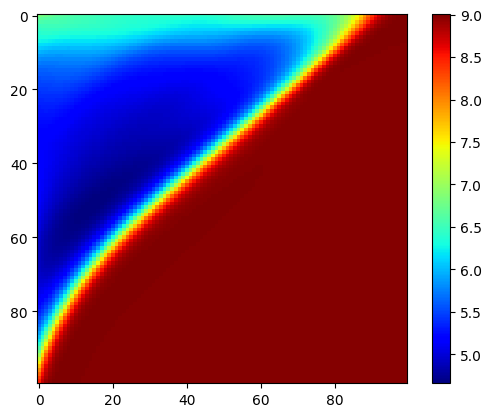

Epoch 0006  loss over 1250  batches  Loss 1 = 0.09130057 Loss 2 = 62.41540909 Loss 3 = 5.27617598


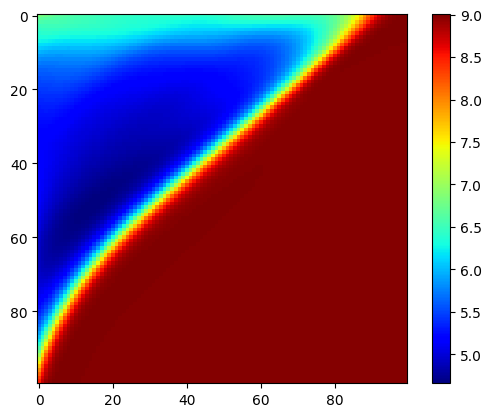

Epoch 0007  loss over 1250  batches  Loss 1 = 0.09191087 Loss 2 = 52.61943436 Loss 3 = 5.14166021


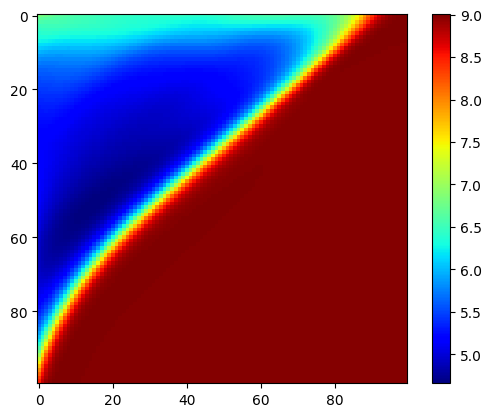

Epoch 0008  loss over 1250  batches  Loss 1 = 0.09717712 Loss 2 = 51.75133514 Loss 3 = 4.85374165


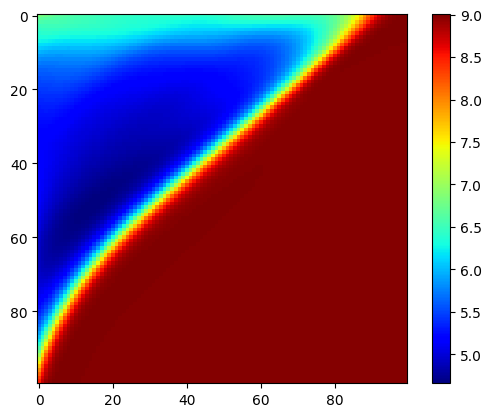

Epoch 0009  loss over 1250  batches  Loss 1 = 0.09941862 Loss 2 = 57.59598923 Loss 3 = 4.46933699


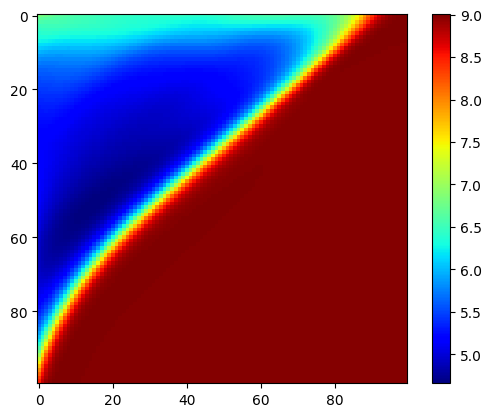

Epoch 0010  loss over 1250  batches  Loss 1 = 0.10102398 Loss 2 = 59.55504608 Loss 3 = 4.08775616


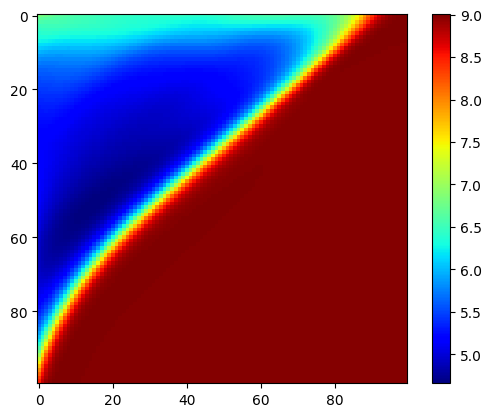

Epoch 0011  loss over 1250  batches  Loss 1 = 0.10733628 Loss 2 = 61.49402237 Loss 3 = 4.40150785


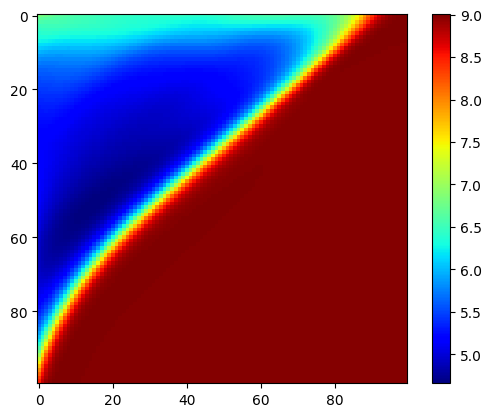

Epoch 0012  loss over 1250  batches  Loss 1 = 0.12549619 Loss 2 = 55.21471405 Loss 3 = 7.08379793


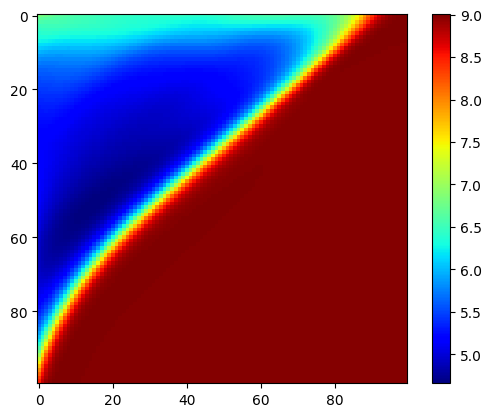

Epoch 0013  loss over 1250  batches  Loss 1 = 0.12679103 Loss 2 = 47.93562317 Loss 3 = 8.41766167


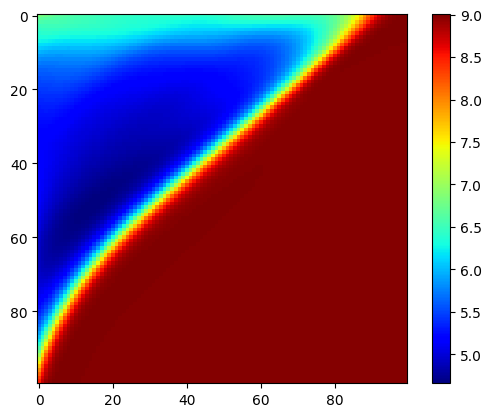

Epoch 0014  loss over 1250  batches  Loss 1 = 0.10629392 Loss 2 = 38.78323746 Loss 3 = 9.07271767


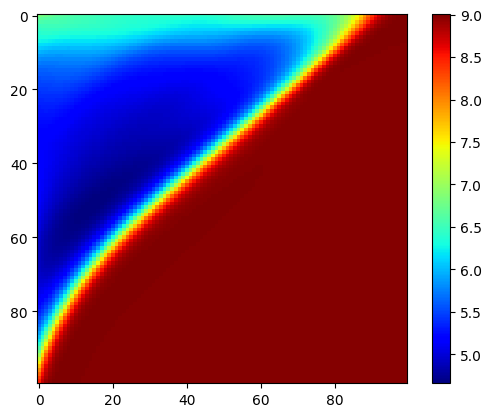

Epoch 0015  loss over 1250  batches  Loss 1 = 0.10578815 Loss 2 = 38.47322845 Loss 3 = 8.86826038


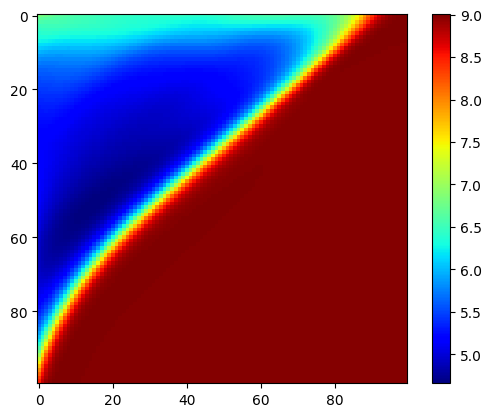

Epoch 0016  loss over 1250  batches  Loss 1 = 0.11003118 Loss 2 = 39.72601700 Loss 3 = 7.94572783


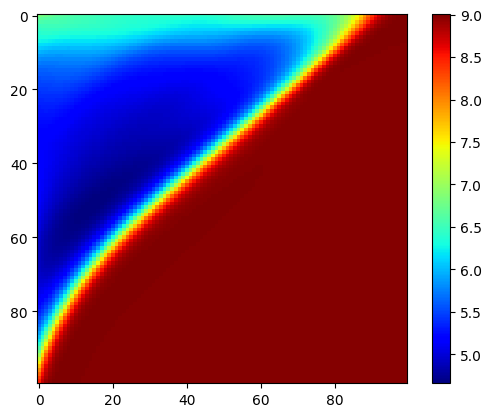

Epoch 0017  loss over 1250  batches  Loss 1 = 0.10401794 Loss 2 = 36.19875336 Loss 3 = 7.65799665


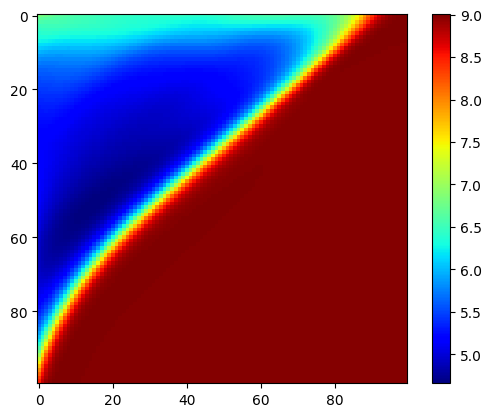

Epoch 0018  loss over 1250  batches  Loss 1 = 0.09694397 Loss 2 = 32.53844070 Loss 3 = 8.05148792


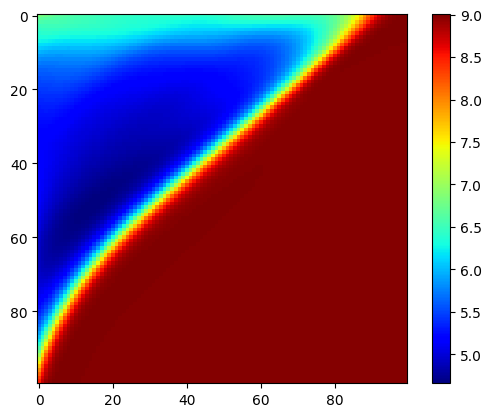

Epoch 0019  loss over 1250  batches  Loss 1 = 0.08882023 Loss 2 = 27.10612297 Loss 3 = 8.68954372


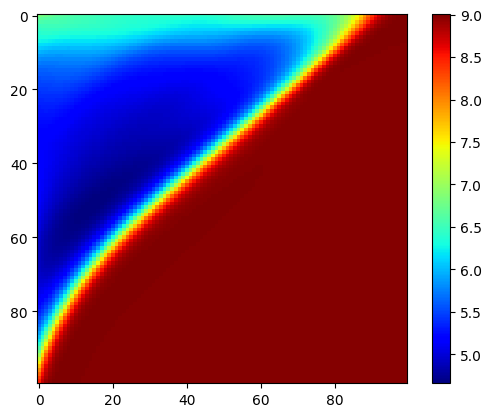

Epoch 0020  loss over 1250  batches  Loss 1 = 0.08062731 Loss 2 = 26.05717659 Loss 3 = 9.13982105


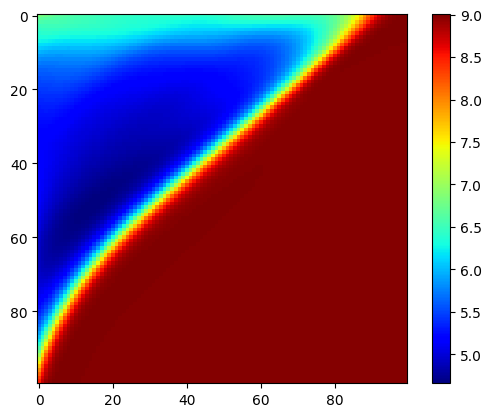

Epoch 0021  loss over 1250  batches  Loss 1 = 0.07329995 Loss 2 = 26.92532349 Loss 3 = 9.45647430


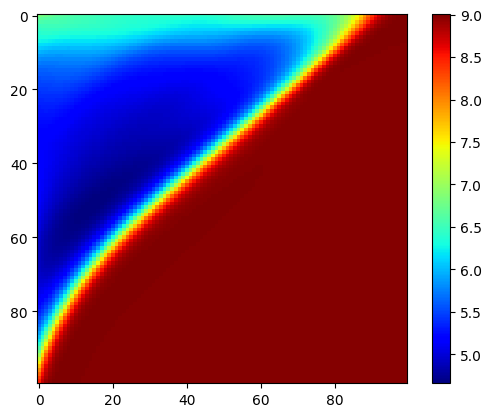

Epoch 0022  loss over 1250  batches  Loss 1 = 0.07221252 Loss 2 = 26.96733475 Loss 3 = 9.48679924


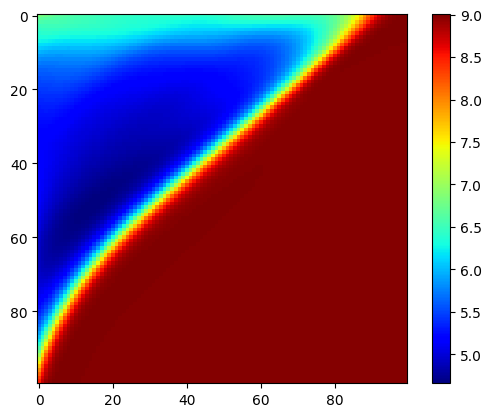

Epoch 0023  loss over 1250  batches  Loss 1 = 0.06524231 Loss 2 = 23.51276016 Loss 3 = 9.18369961


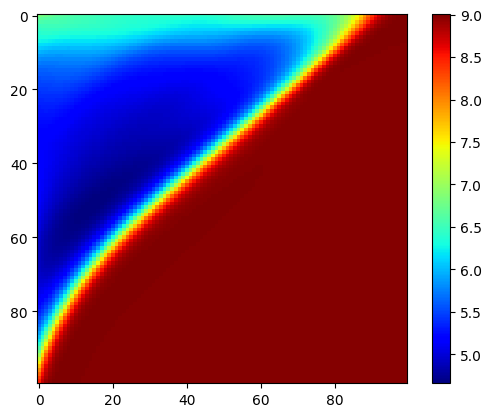

Epoch 0024  loss over 1250  batches  Loss 1 = 0.06664557 Loss 2 = 27.76103020 Loss 3 = 8.78866100


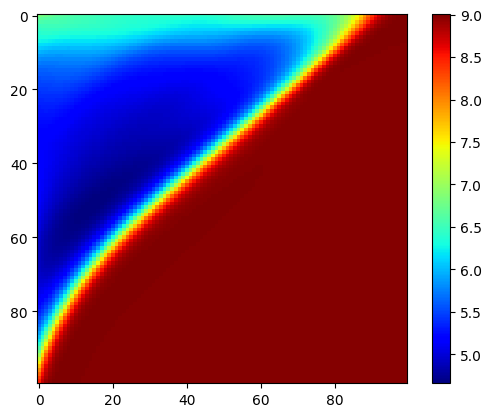

Epoch 0025  loss over 1250  batches  Loss 1 = 0.06187674 Loss 2 = 27.97336006 Loss 3 = 8.69429970


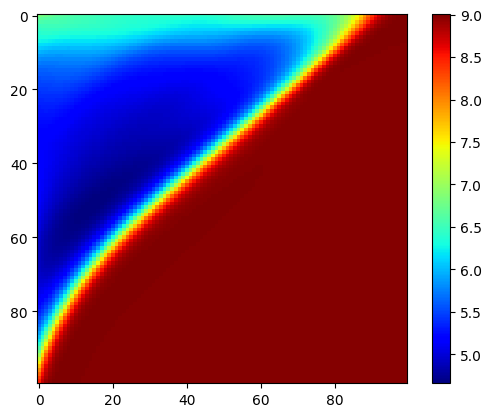

Epoch 0026  loss over 1250  batches  Loss 1 = 0.06107442 Loss 2 = 25.48801613 Loss 3 = 8.58480453


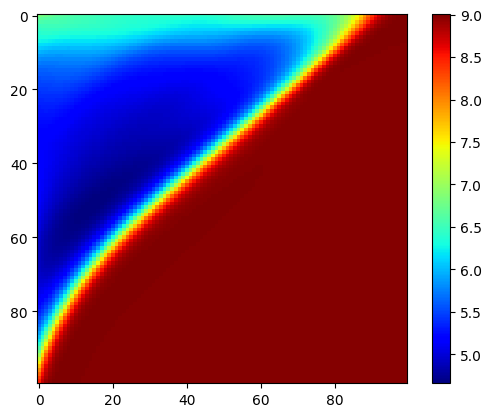

Epoch 0027  loss over 1250  batches  Loss 1 = 0.06540221 Loss 2 = 25.93965721 Loss 3 = 8.63640308


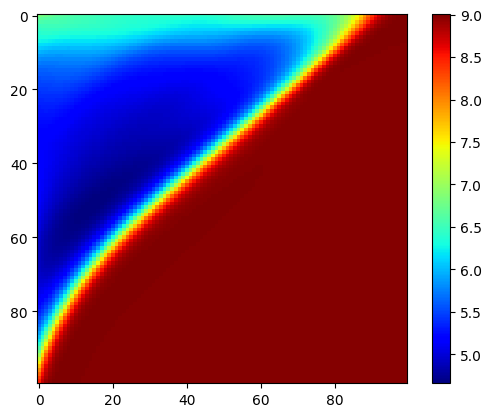

Epoch 0028  loss over 1250  batches  Loss 1 = 0.06511027 Loss 2 = 24.85816193 Loss 3 = 8.52920246


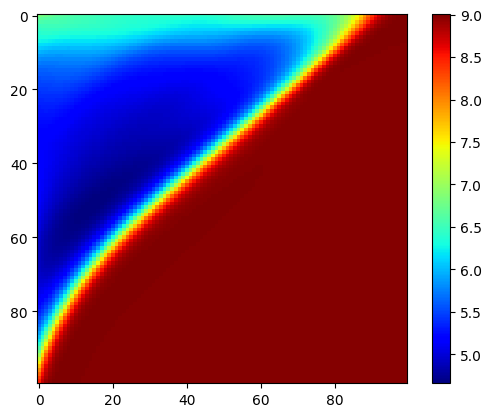

Epoch 0029  loss over 1250  batches  Loss 1 = 0.06518094 Loss 2 = 23.12776375 Loss 3 = 8.67818069


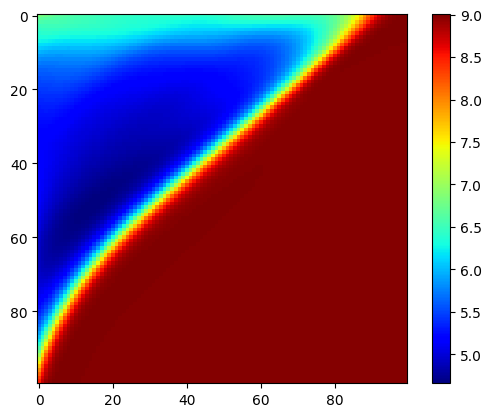

Epoch 0030  loss over 1250  batches  Loss 1 = 0.06683157 Loss 2 = 23.03629303 Loss 3 = 8.57090378


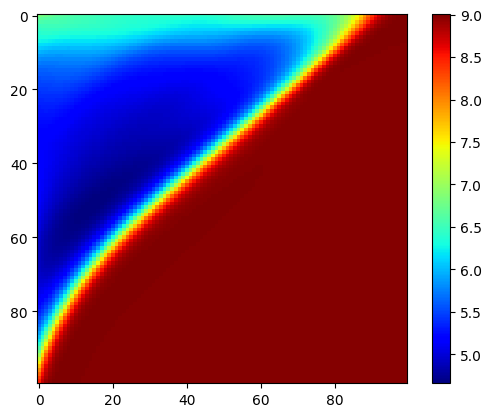

Epoch 0031  loss over 1250  batches  Loss 1 = 0.06702685 Loss 2 = 23.98761559 Loss 3 = 8.63902569


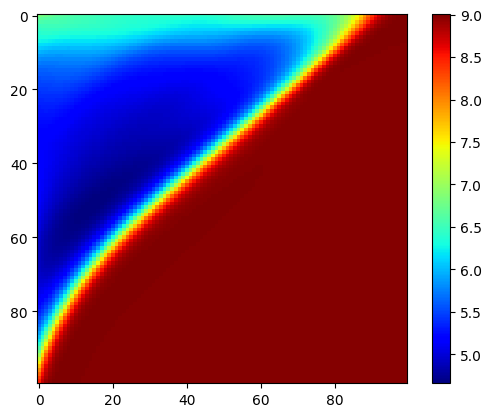

Epoch 0032  loss over 1250  batches  Loss 1 = 0.06683870 Loss 2 = 25.16338158 Loss 3 = 8.79808903


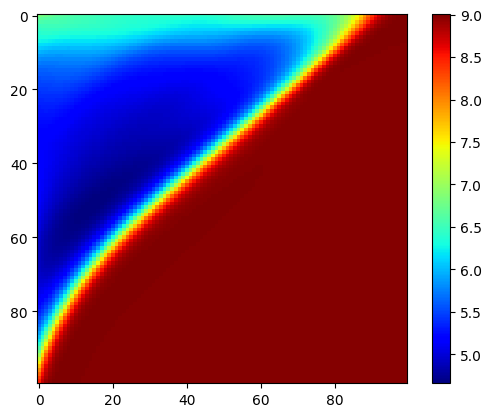

Epoch 0033  loss over 1250  batches  Loss 1 = 0.06384411 Loss 2 = 25.36894417 Loss 3 = 8.54938698


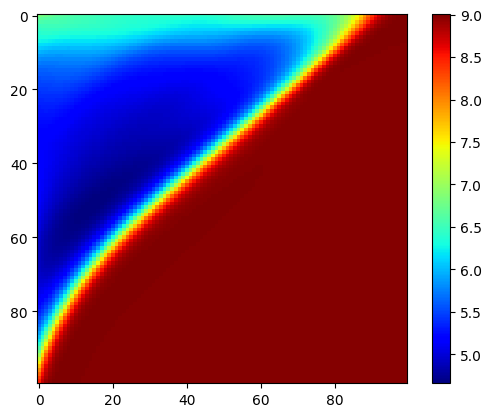

Epoch 0034  loss over 1250  batches  Loss 1 = 0.06234943 Loss 2 = 25.30254173 Loss 3 = 8.43034840


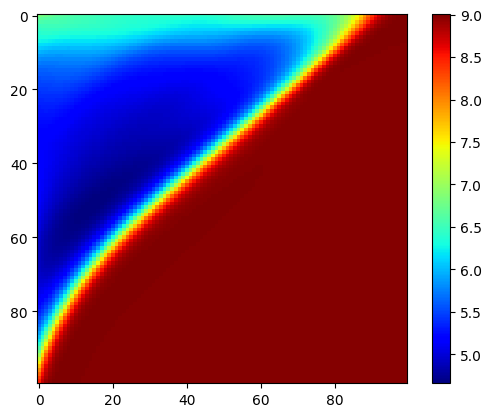

Epoch 0035  loss over 1250  batches  Loss 1 = 0.05868191 Loss 2 = 23.88839912 Loss 3 = 8.45671940


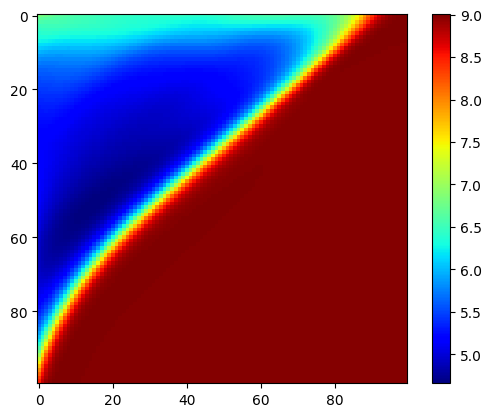

Epoch 0036  loss over 1250  batches  Loss 1 = 0.05704131 Loss 2 = 22.99045944 Loss 3 = 8.42942047


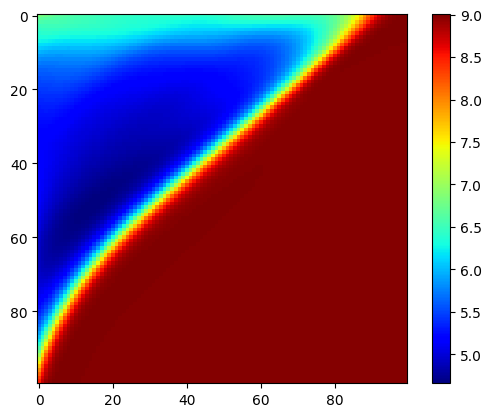

Epoch 0037  loss over 1250  batches  Loss 1 = 0.06160327 Loss 2 = 23.62540817 Loss 3 = 8.52516174


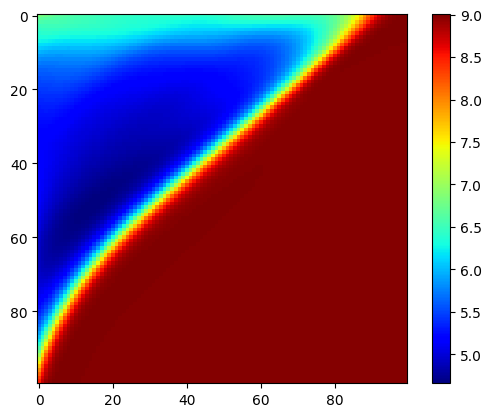

Epoch 0038  loss over 1250  batches  Loss 1 = 0.05664076 Loss 2 = 23.75165558 Loss 3 = 8.49563313


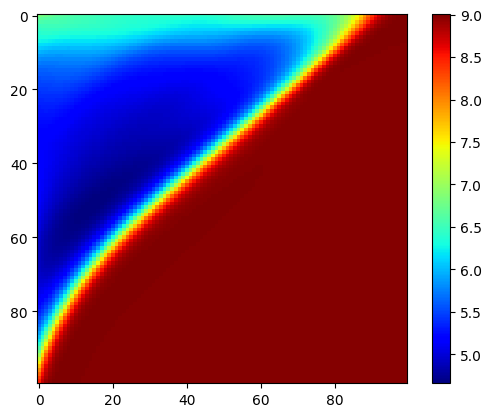

Epoch 0039  loss over 1250  batches  Loss 1 = 0.05705883 Loss 2 = 23.15138626 Loss 3 = 8.60157394


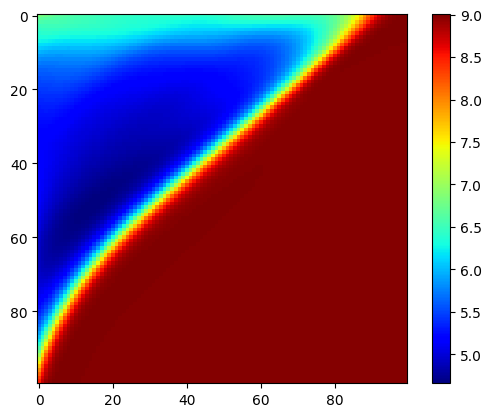

Epoch 0040  loss over 1250  batches  Loss 1 = 0.05484305 Loss 2 = 22.95188141 Loss 3 = 8.66680050


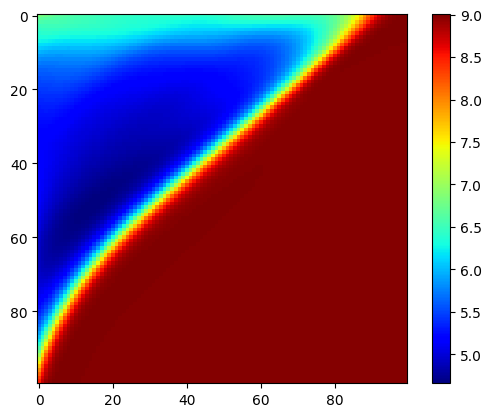

Epoch 0041  loss over 1250  batches  Loss 1 = 0.05104738 Loss 2 = 21.81377602 Loss 3 = 8.87884712


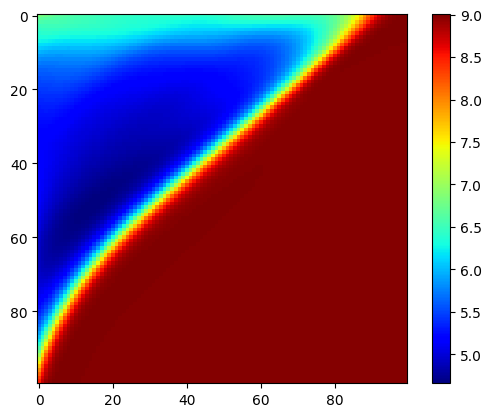

Epoch 0042  loss over 1250  batches  Loss 1 = 0.05370805 Loss 2 = 21.95007324 Loss 3 = 8.97170448


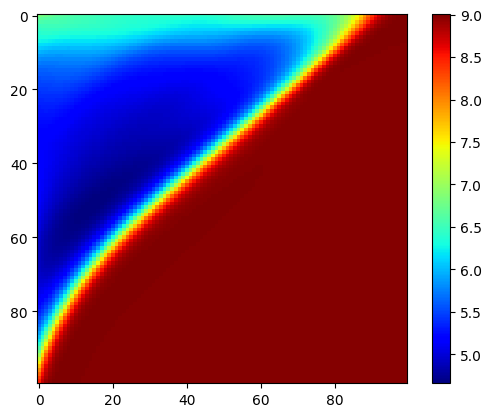

Epoch 0043  loss over 1250  batches  Loss 1 = 0.05433051 Loss 2 = 22.72921944 Loss 3 = 8.89046955


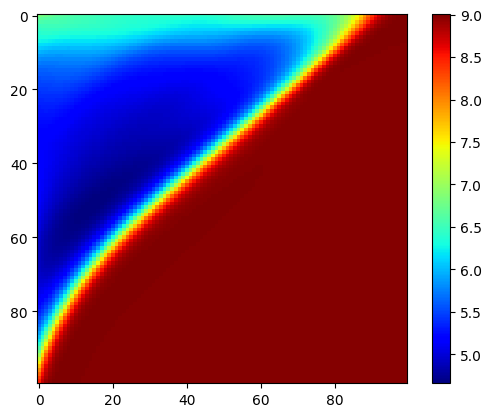

Epoch 0044  loss over 1250  batches  Loss 1 = 0.05747272 Loss 2 = 23.60032082 Loss 3 = 8.60403442


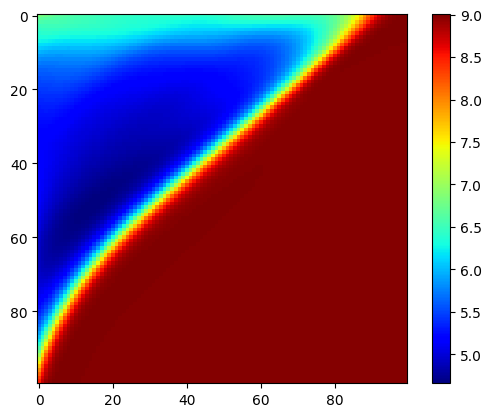

Epoch 0045  loss over 1250  batches  Loss 1 = 0.06087055 Loss 2 = 22.91411591 Loss 3 = 8.66019249


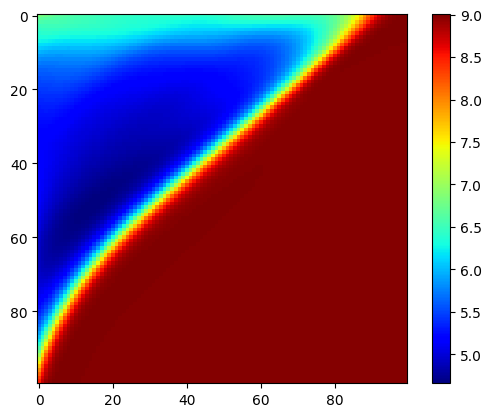

Epoch 0046  loss over 1250  batches  Loss 1 = 0.06506237 Loss 2 = 24.00357437 Loss 3 = 8.73156738


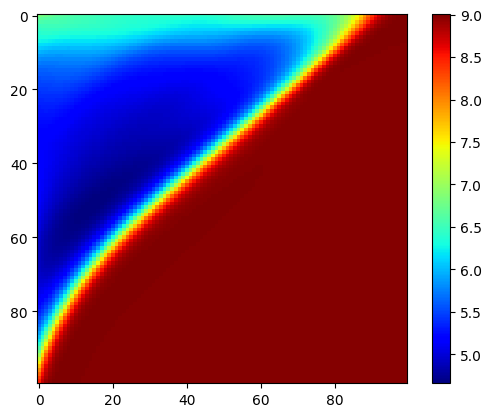

Epoch 0047  loss over 1250  batches  Loss 1 = 0.06803308 Loss 2 = 24.27578163 Loss 3 = 8.50127125


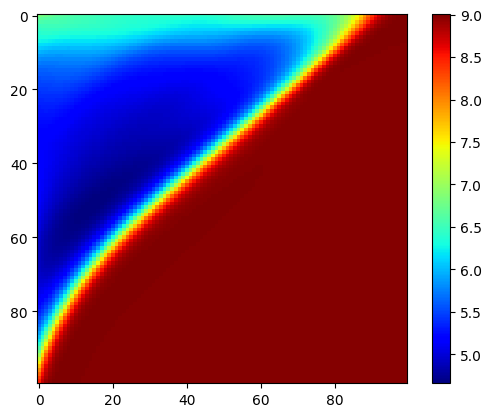

Epoch 0048  loss over 1250  batches  Loss 1 = 0.06371582 Loss 2 = 24.69425392 Loss 3 = 8.43979740


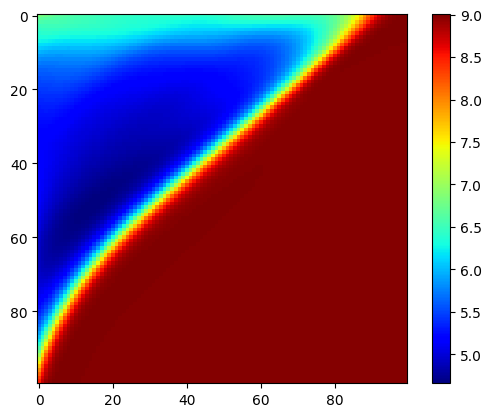

Epoch 0049  loss over 1250  batches  Loss 1 = 0.06024849 Loss 2 = 24.23291016 Loss 3 = 8.10863495


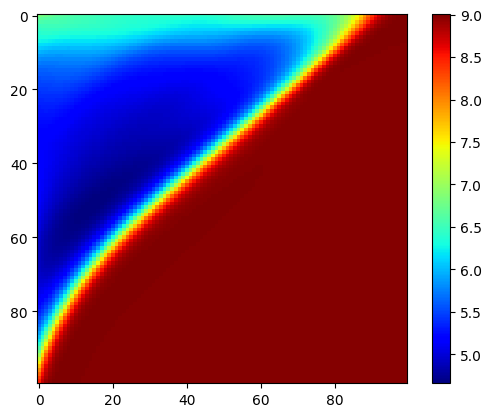

Epoch 0050  loss over 1250  batches  Loss 1 = 0.05837737 Loss 2 = 25.05152321 Loss 3 = 7.97862244


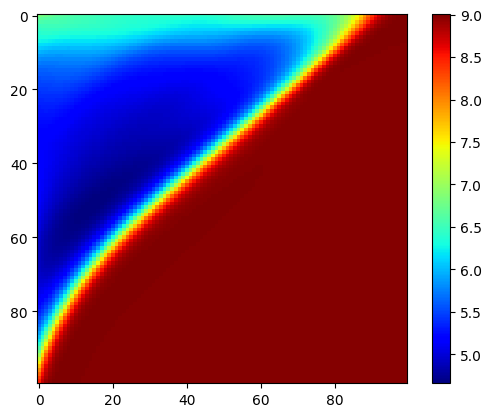

Epoch 0051  loss over 1250  batches  Loss 1 = 0.06128212 Loss 2 = 28.95112610 Loss 3 = 8.33190536


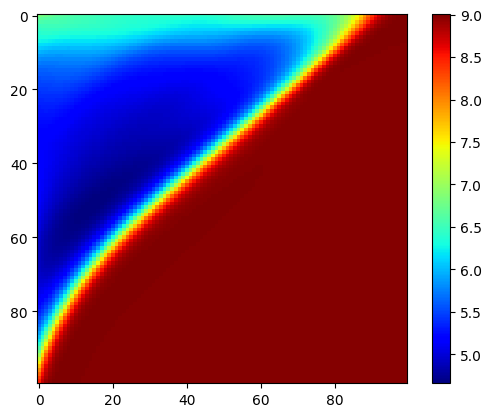

Epoch 0052  loss over 1250  batches  Loss 1 = 0.06372161 Loss 2 = 35.56829071 Loss 3 = 8.87292290


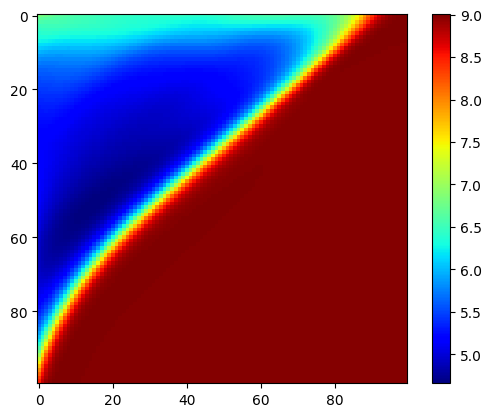

Epoch 0053  loss over 1250  batches  Loss 1 = 0.06286912 Loss 2 = 35.05358887 Loss 3 = 8.83304405


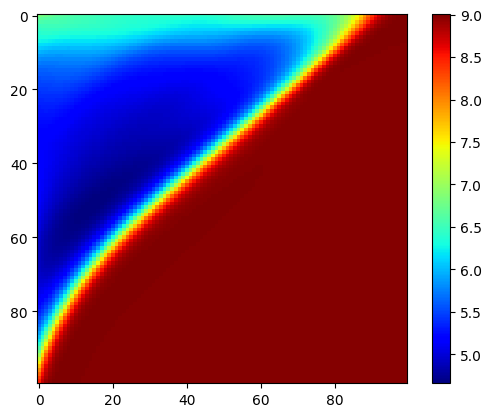

Epoch 0054  loss over 1250  batches  Loss 1 = 0.06348676 Loss 2 = 35.61948776 Loss 3 = 8.88535023


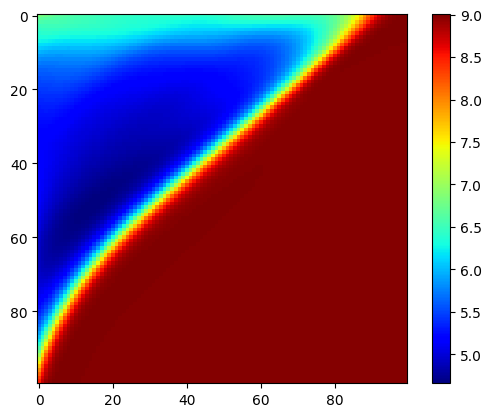

Epoch 0055  loss over 1250  batches  Loss 1 = 0.05880367 Loss 2 = 34.40031815 Loss 3 = 8.95727348


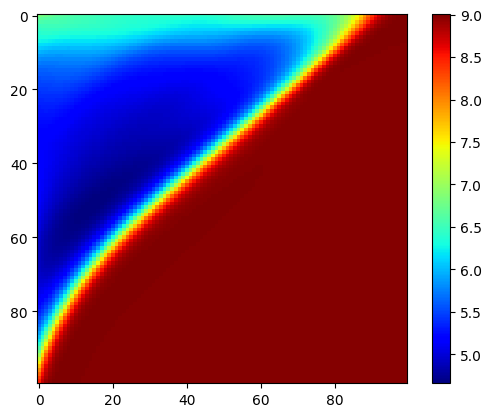

Epoch 0056  loss over 1250  batches  Loss 1 = 0.06387316 Loss 2 = 36.17565155 Loss 3 = 8.72555637


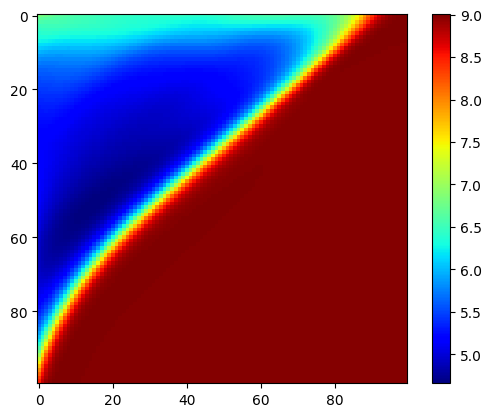

Epoch 0057  loss over 1250  batches  Loss 1 = 0.06433454 Loss 2 = 32.52592468 Loss 3 = 8.45599842


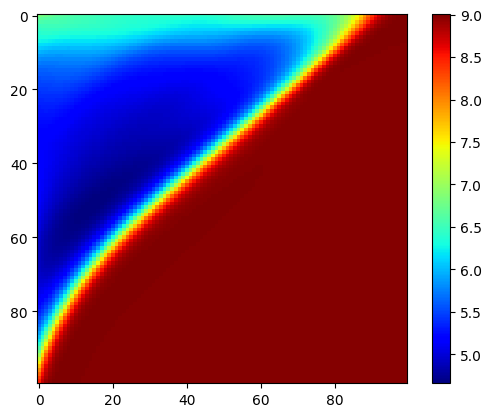

Epoch 0058  loss over 1250  batches  Loss 1 = 0.07230452 Loss 2 = 33.99269867 Loss 3 = 8.02661324


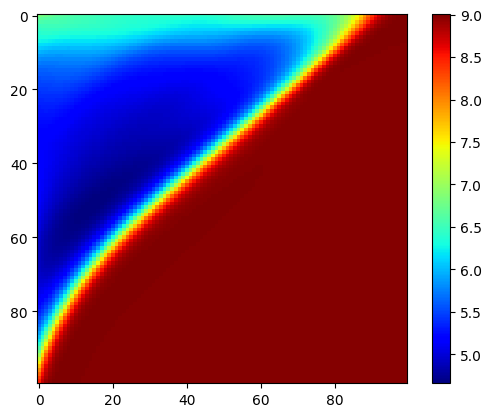

Epoch 0059  loss over 1250  batches  Loss 1 = 0.07688569 Loss 2 = 37.28010178 Loss 3 = 7.53510761


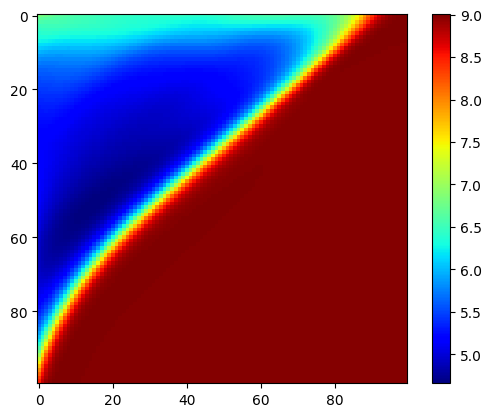

Epoch 0060  loss over 1250  batches  Loss 1 = 0.07489384 Loss 2 = 33.64533234 Loss 3 = 8.45493984


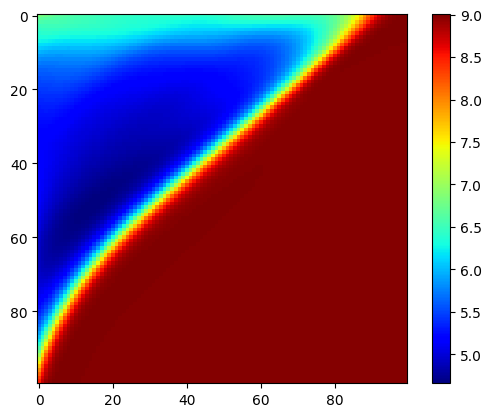

Epoch 0061  loss over 1250  batches  Loss 1 = 0.07710422 Loss 2 = 38.32714462 Loss 3 = 8.95738220


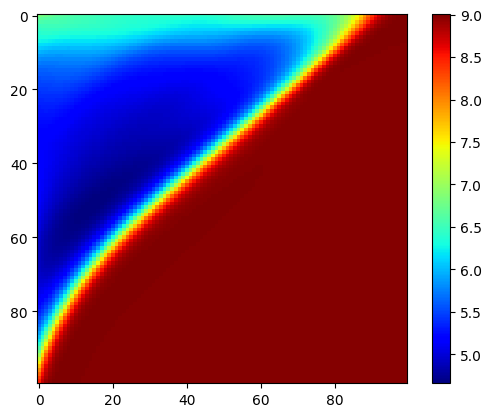

Epoch 0062  loss over 1250  batches  Loss 1 = 0.08259528 Loss 2 = 39.43032074 Loss 3 = 9.21367073


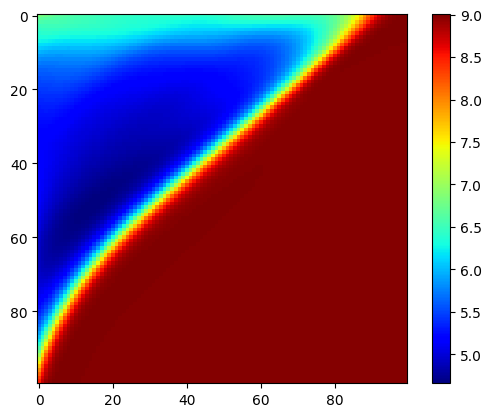

Epoch 0063  loss over 1250  batches  Loss 1 = 0.09047554 Loss 2 = 41.79849243 Loss 3 = 8.76114750


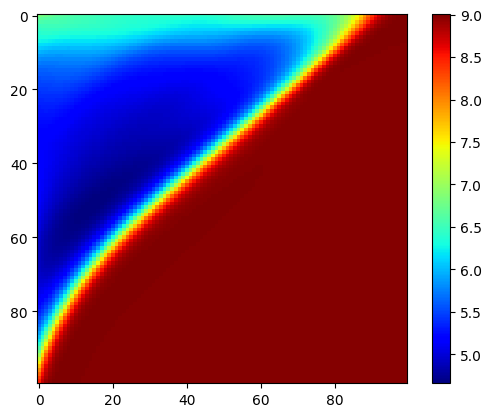

Epoch 0064  loss over 1250  batches  Loss 1 = 0.09191205 Loss 2 = 37.98480988 Loss 3 = 8.95081425


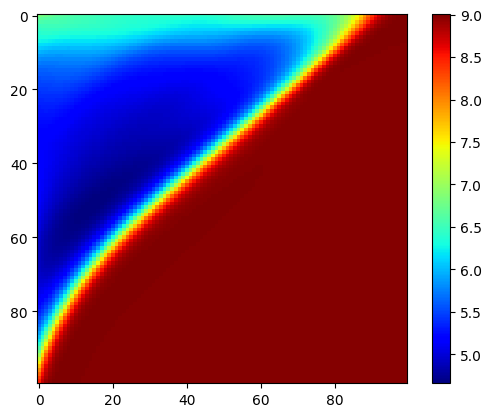

Epoch 0065  loss over 1250  batches  Loss 1 = 0.09049243 Loss 2 = 37.78921890 Loss 3 = 8.84922600


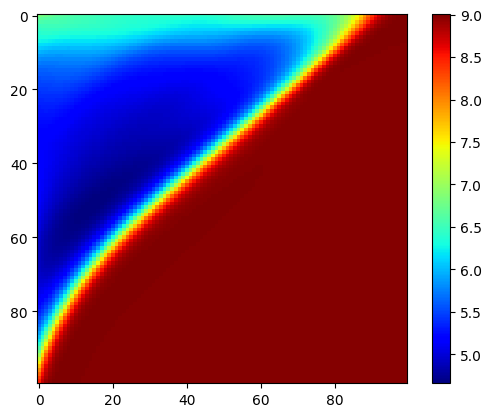

Epoch 0066  loss over 1250  batches  Loss 1 = 0.08305512 Loss 2 = 33.94506073 Loss 3 = 9.01937199


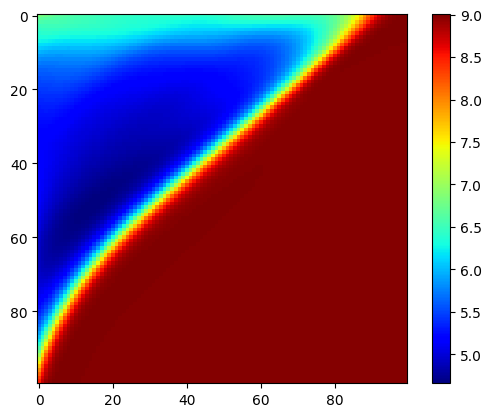

Epoch 0067  loss over 1250  batches  Loss 1 = 0.08549054 Loss 2 = 30.40669823 Loss 3 = 9.01061058


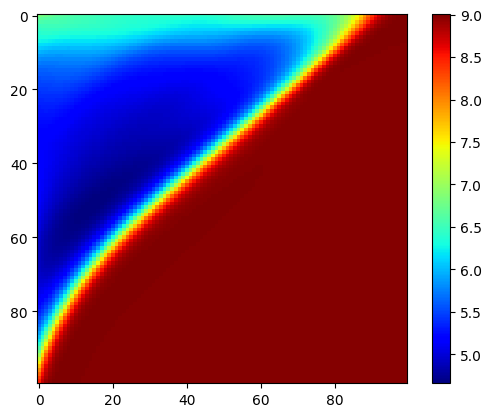

Epoch 0068  loss over 1250  batches  Loss 1 = 0.09133118 Loss 2 = 32.81140900 Loss 3 = 8.57748985


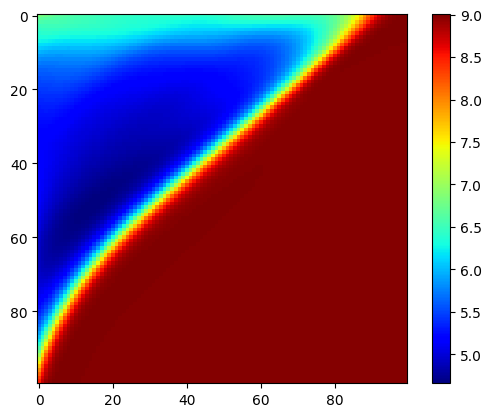

Epoch 0069  loss over 1250  batches  Loss 1 = 0.08437743 Loss 2 = 28.40525436 Loss 3 = 8.46591949


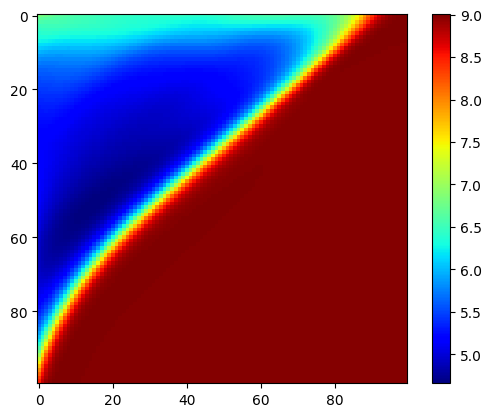

Epoch 0070  loss over 1250  batches  Loss 1 = 0.08522210 Loss 2 = 28.94179153 Loss 3 = 7.85607910


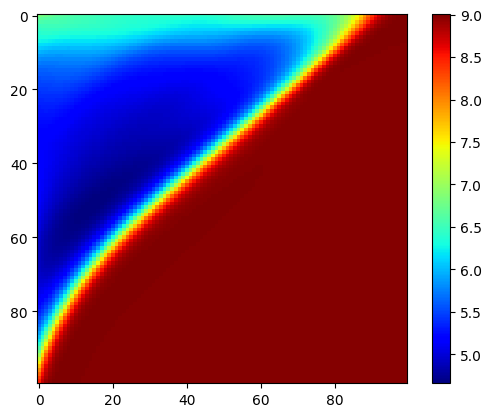

Epoch 0071  loss over 1250  batches  Loss 1 = 0.08292181 Loss 2 = 27.88429260 Loss 3 = 7.56380606


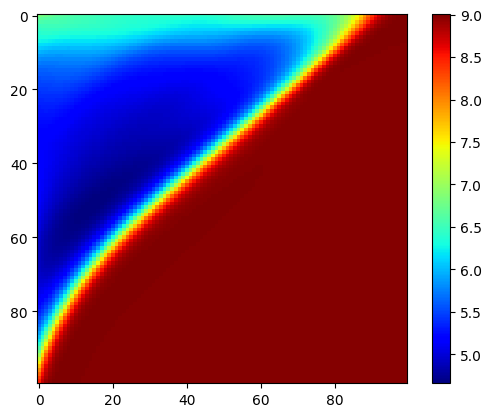

Epoch 0072  loss over 1250  batches  Loss 1 = 0.09148275 Loss 2 = 30.41931343 Loss 3 = 7.36791039


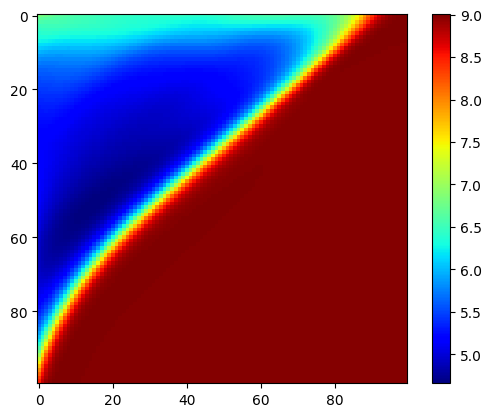

Epoch 0073  loss over 1250  batches  Loss 1 = 0.09127671 Loss 2 = 31.28346062 Loss 3 = 7.50189590


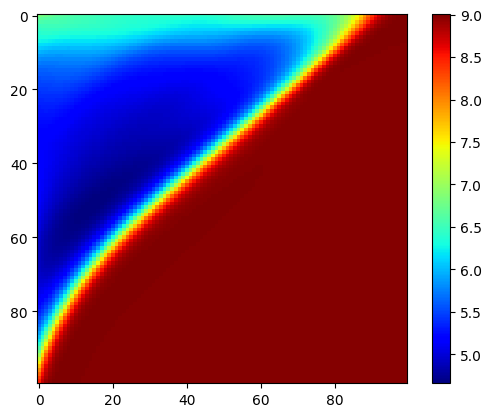

Epoch 0074  loss over 1250  batches  Loss 1 = 0.08328557 Loss 2 = 28.13503647 Loss 3 = 7.38505268


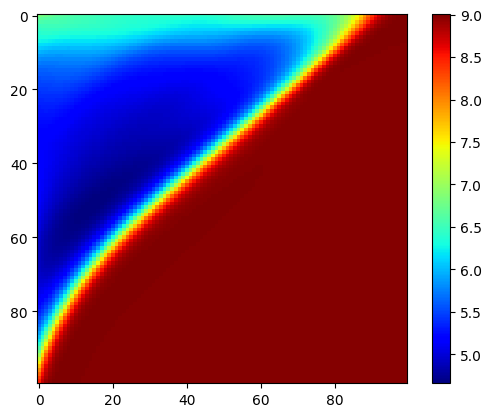

Epoch 0075  loss over 1250  batches  Loss 1 = 0.07346804 Loss 2 = 24.65680695 Loss 3 = 7.64033222


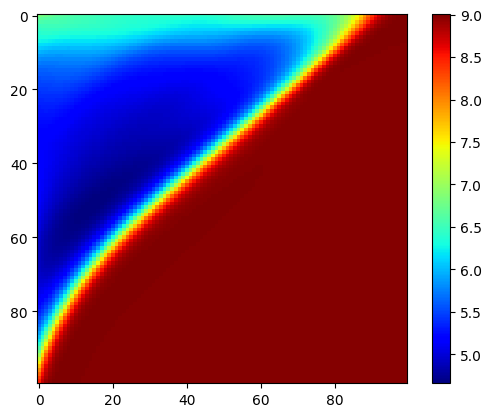

Epoch 0076  loss over 1250  batches  Loss 1 = 0.07336141 Loss 2 = 23.68868828 Loss 3 = 7.95764875


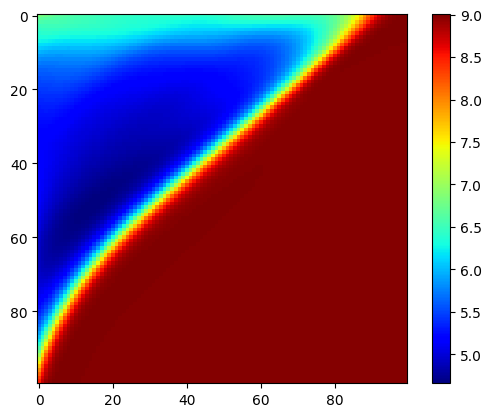

Epoch 0077  loss over 1250  batches  Loss 1 = 0.08326285 Loss 2 = 25.90987206 Loss 3 = 8.10164928


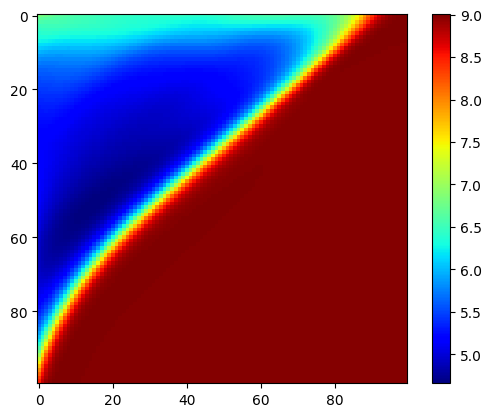

Epoch 0078  loss over 1250  batches  Loss 1 = 0.09174832 Loss 2 = 25.80378342 Loss 3 = 7.92092848


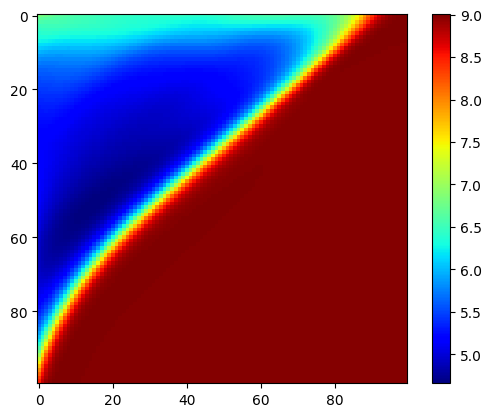

Epoch 0079  loss over 1250  batches  Loss 1 = 0.08041639 Loss 2 = 23.24005699 Loss 3 = 7.17738724


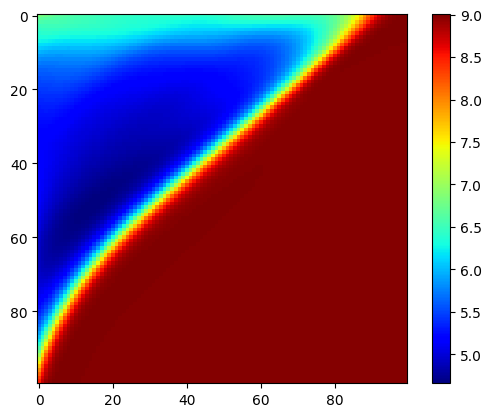

Epoch 0080  loss over 1250  batches  Loss 1 = 0.08156111 Loss 2 = 25.90753937 Loss 3 = 6.34812450


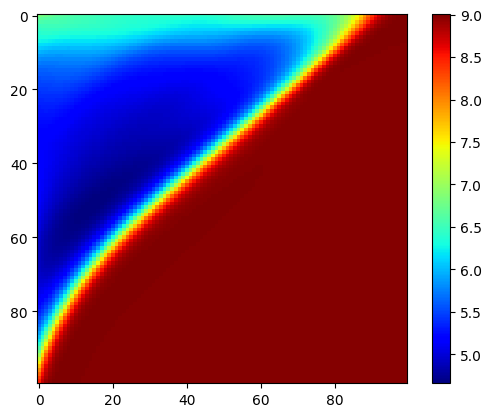

Epoch 0081  loss over 1250  batches  Loss 1 = 0.09287788 Loss 2 = 28.16878319 Loss 3 = 6.24158049


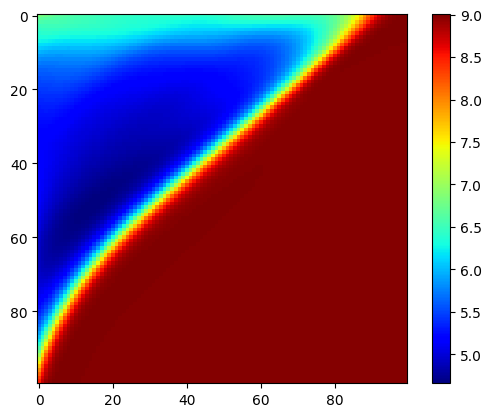

Epoch 0082  loss over 1250  batches  Loss 1 = 0.09867034 Loss 2 = 31.86597252 Loss 3 = 5.25466490


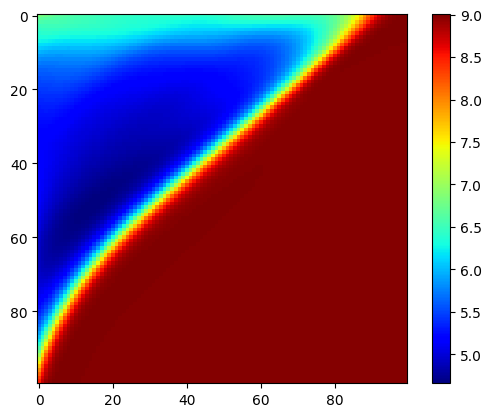

Epoch 0083  loss over 1250  batches  Loss 1 = 0.10472731 Loss 2 = 30.96348000 Loss 3 = 4.24325275


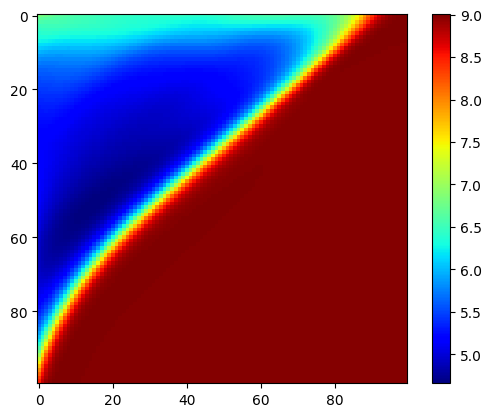

Epoch 0084  loss over 1250  batches  Loss 1 = 0.09186019 Loss 2 = 27.13583183 Loss 3 = 3.34270573


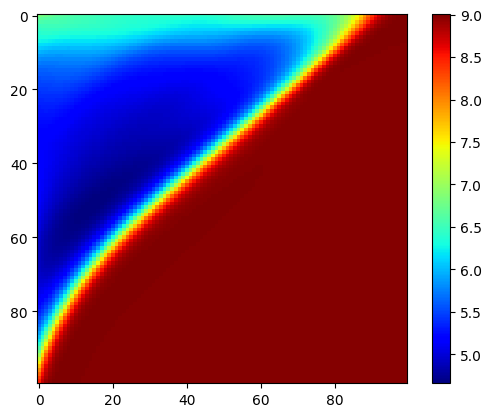

Epoch 0085  loss over 1250  batches  Loss 1 = 0.08154072 Loss 2 = 26.01619530 Loss 3 = 2.76157641


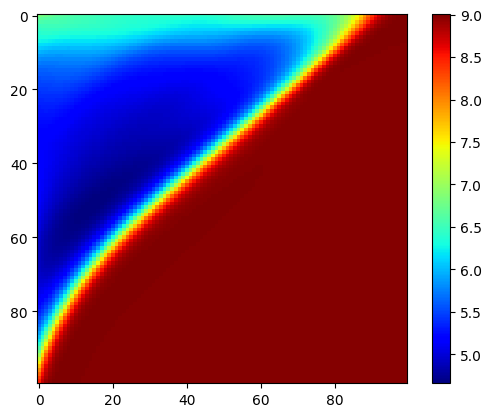

Epoch 0086  loss over 1250  batches  Loss 1 = 0.07074752 Loss 2 = 26.89860725 Loss 3 = 2.56635118


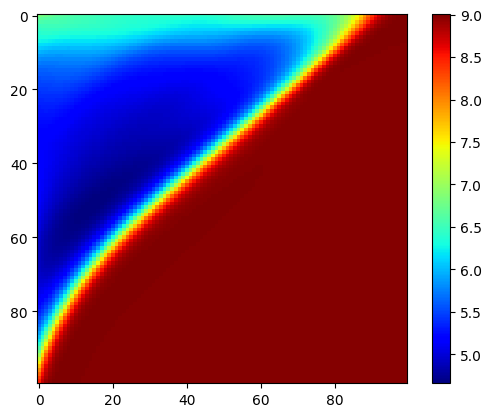

Epoch 0087  loss over 1250  batches  Loss 1 = 0.07114353 Loss 2 = 26.73313522 Loss 3 = 2.33945656


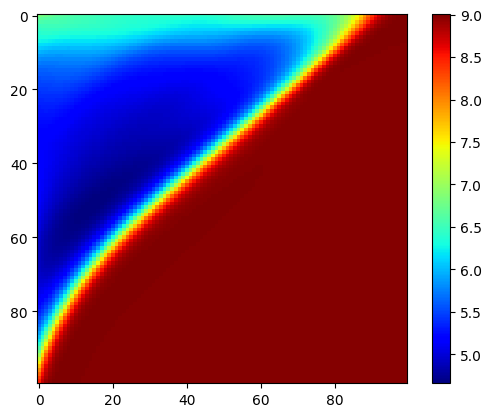

Epoch 0088  loss over 1250  batches  Loss 1 = 0.07510402 Loss 2 = 25.72261620 Loss 3 = 2.13499618


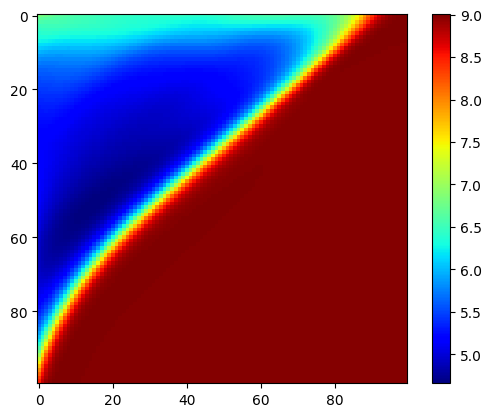

Epoch 0089  loss over 1250  batches  Loss 1 = 0.08242562 Loss 2 = 24.23242950 Loss 3 = 2.07062960


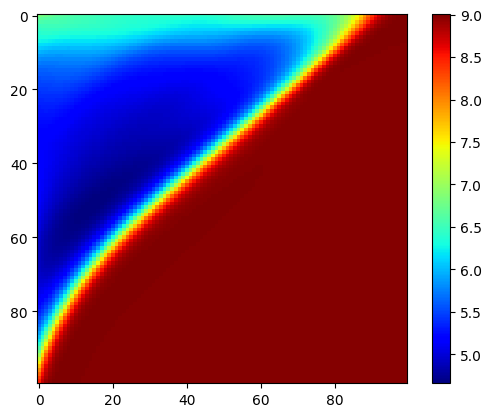

Epoch 0090  loss over 1250  batches  Loss 1 = 0.10220534 Loss 2 = 29.77210426 Loss 3 = 2.16976953


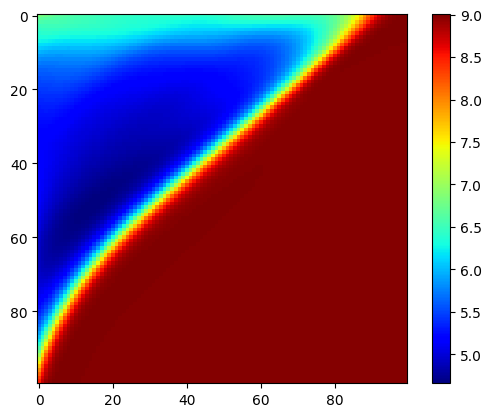

Epoch 0091  loss over 1250  batches  Loss 1 = 0.11251066 Loss 2 = 31.53396416 Loss 3 = 2.18426013


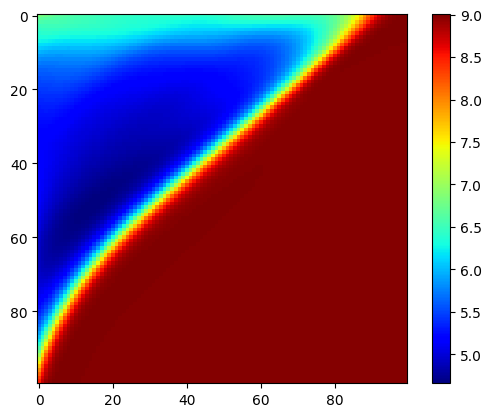

Epoch 0092  loss over 1250  batches  Loss 1 = 0.11719986 Loss 2 = 39.98913574 Loss 3 = 2.74214125


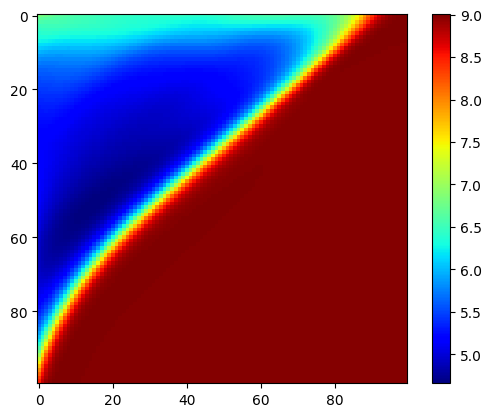

Epoch 0093  loss over 1250  batches  Loss 1 = 0.12101682 Loss 2 = 41.40212631 Loss 3 = 2.00996494


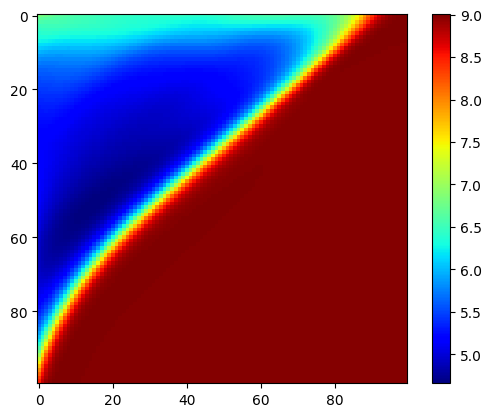

Epoch 0094  loss over 1250  batches  Loss 1 = 0.09852283 Loss 2 = 36.35652542 Loss 3 = 1.75945961


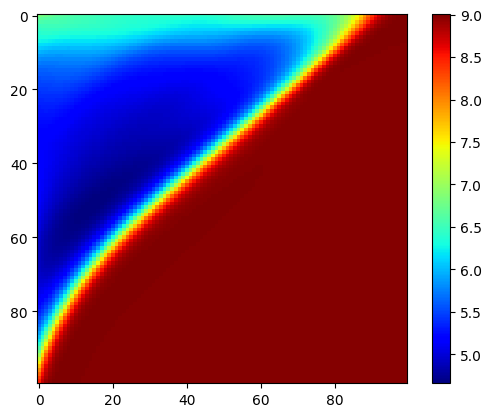

Epoch 0095  loss over 1250  batches  Loss 1 = 0.09970241 Loss 2 = 41.64261627 Loss 3 = 1.50759220


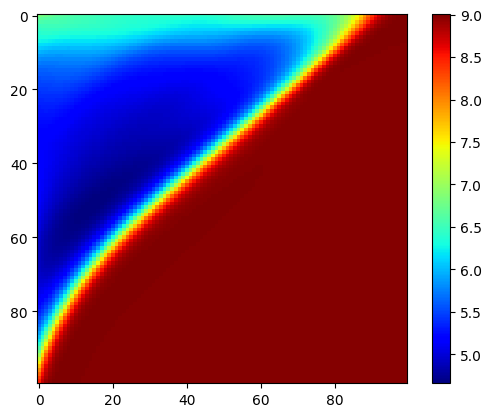

Epoch 0096  loss over 1250  batches  Loss 1 = 0.10503368 Loss 2 = 46.66726685 Loss 3 = 1.51446617


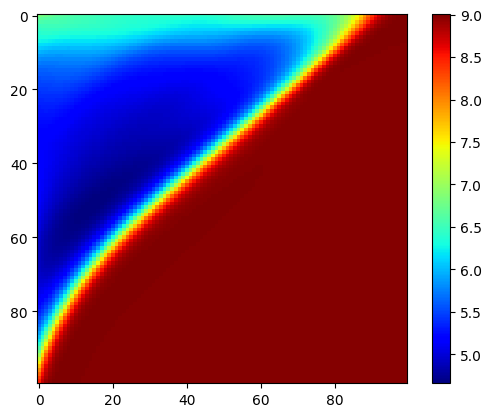

Epoch 0097  loss over 1250  batches  Loss 1 = 0.10320272 Loss 2 = 52.27273941 Loss 3 = 1.66468465


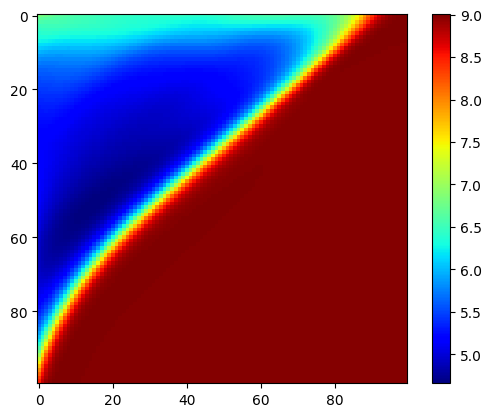

Epoch 0098  loss over 1250  batches  Loss 1 = 0.10101752 Loss 2 = 58.90708923 Loss 3 = 1.85499585


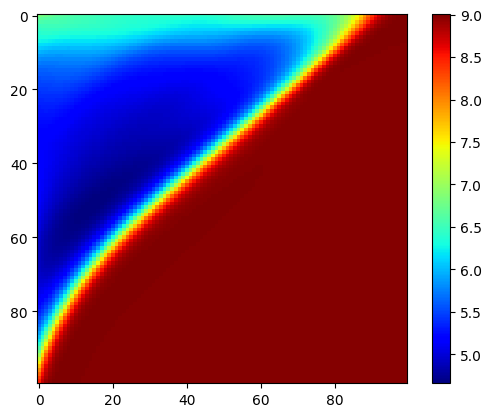

Epoch 0099  loss over 1250  batches  Loss 1 = 0.10542436 Loss 2 = 59.59823227 Loss 3 = 1.86079741
Time:  5902.640017417027
min =  100000


In [273]:
start = timeit.default_timer()
min = 100000;
batches = int(len(X_train_no_Y)/batch_size)
training_epochs = 100
model = tf.keras.models.load_model('h5_files/FC_87.keras')
opt1.learning_rate.assign(0.0003)
opt2.learning_rate.assign(0.0002)
opt3.learning_rate.assign(0.0001)
for epoch in range(training_epochs):
    losses1 = 0
    losses2 = 0
    losses3 = 0
    for j in range(batches):
#    for j in range(1):
        index1 = np.random.randint(X_train1.shape[0], size=batch_size)
        index2 = np.random.randint(X_train_no_Y.shape[0], size=batch_size)
        index3 = np.random.randint(X_train3.shape[0], size=batch_size)
        X_b = tf.gather(X_train1_t, index1)
        Y_b = tf.gather(Y_train1_t, index1)
        X_c = tf.gather(X_train_no_Y_t, index2)
        X_e = tf.gather(X_train3_t, index3)
        Y_e = tf.gather(Y_train3_t, index3)
        
        loss1, loss2, loss3 = train_step(X_b, Y_b, X_c, X_e, Y_e)
        losses1 = losses1 + loss1
        losses2 = losses2 + loss2
        losses3 = losses3 + loss3
        
    Y_VAL = model(X_test_t, training=False)
    fig = plt.figure()
    im = plt.imshow(np.reshape(Y_VAL, (100, 100)), cmap='jet', interpolation='nearest')
    cbar = plt.colorbar(im)
    plt.show()
    filename = 'h5_files/FC_' + str(epoch) + '.keras'
    model.save(filename)
    
    #if losses1/batches + 0.2*losses2/batches < min:
    #    min = losses1/batches + 0.2*losses2/batches



    if epoch%1 == 0: #or losses1/batches < min:
        print("Epoch %.4d " % epoch, "loss over", batches, " batches ", "Loss 1 = %.8f" % (losses1/batches), "Loss 2 = %.8f" % (losses2/batches), "Loss 3 = %.8f" % (losses3/batches))
    
stop = timeit.default_timer()


print('Time: ', stop - start) 
print('min = ', min)


2026-03-23 22:01:50.773425: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


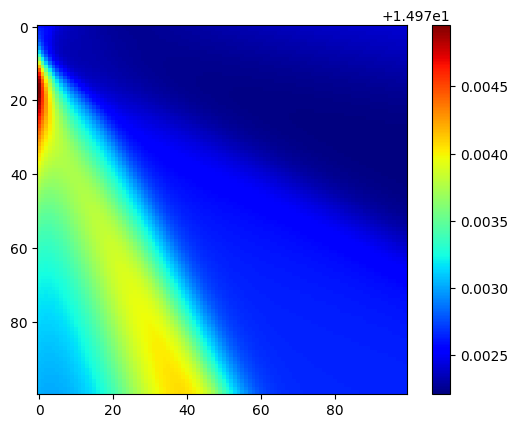

Epoch 0000  loss over 1250  batches  Loss 1 = 15.23389244 Loss 2 = 124.11420441 Loss 3 = 114.15644073


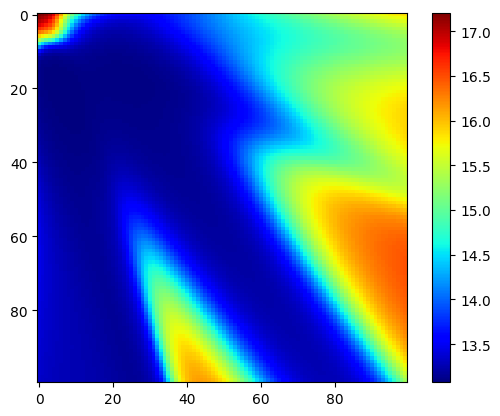

Epoch 0001  loss over 1250  batches  Loss 1 = 10.28666019 Loss 2 = 254.67495728 Loss 3 = 114.66304016


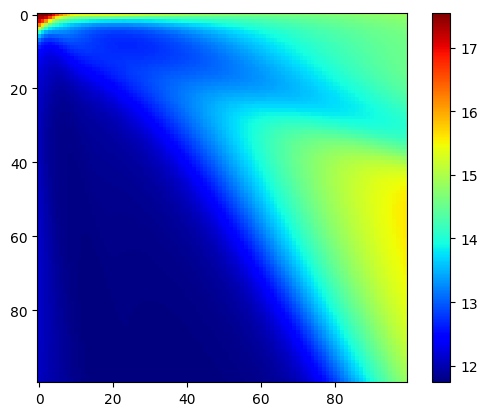

Epoch 0002  loss over 1250  batches  Loss 1 = 6.23305893 Loss 2 = 455.72302246 Loss 3 = 120.45004272


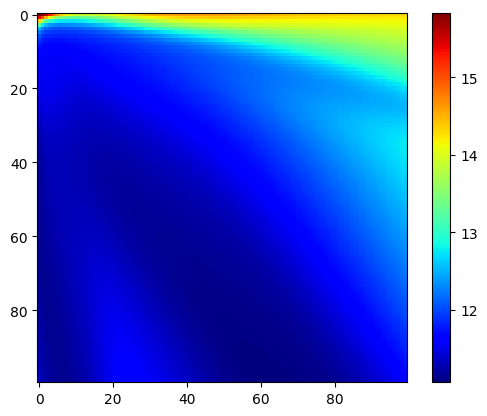

Epoch 0003  loss over 1250  batches  Loss 1 = 4.73409605 Loss 2 = 491.77548218 Loss 3 = 126.30310822


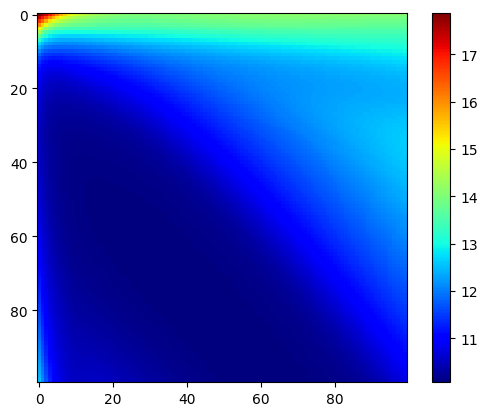

Epoch 0004  loss over 1250  batches  Loss 1 = 4.29770279 Loss 2 = 452.49157715 Loss 3 = 131.04750061


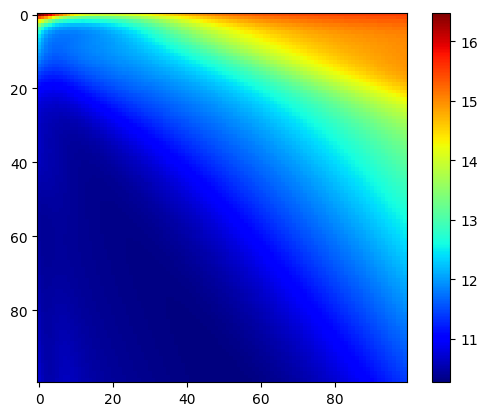

Epoch 0005  loss over 1250  batches  Loss 1 = 4.23852015 Loss 2 = 418.13677979 Loss 3 = 131.66104126


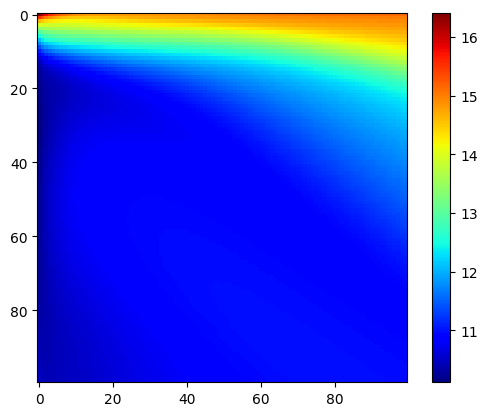

Epoch 0006  loss over 1250  batches  Loss 1 = 4.17801523 Loss 2 = 366.58078003 Loss 3 = 127.62532043


KeyboardInterrupt: 

In [115]:
start = timeit.default_timer()
min = 100000;
batches = int(len(X_train_no_Y)/batch_size)
training_epochs = 100
#model = tf.keras.models.load_model('h5_files/FC_5.keras')
opt1.learning_rate.assign(0.0006)
opt2.learning_rate.assign(0.0002)
opt3.learning_rate.assign(0.0004)
for epoch in range(training_epochs):
    losses1 = 0
    losses2 = 0
    losses3 = 0
    for j in range(batches):
#    for j in range(1):
        index1 = np.random.randint(X_train1.shape[0], size=batch_size)
        index2 = np.random.randint(X_train_no_Y.shape[0], size=batch_size)
        index3 = np.random.randint(X_train3.shape[0], size=batch_size)
        X_b = tf.gather(X_train1_t, index1)
        Y_b = tf.gather(Y_train1_t, index1)
        X_c = tf.gather(X_train_no_Y_t, index2)
        X_e = tf.gather(X_train3_t, index3)
        Y_e = tf.gather(Y_train3_t, index3)
        #tf.print(X_b)
        #tf.print(Y_b)
        #tf.print(X_e)
        #tf.print(Y_e)
        
        loss1, loss2, loss3 = train_step(X_b, Y_b, X_c, X_e, Y_e)
        #print(loss3)
        losses1 = losses1 + loss1
        losses2 = losses2 + loss2
        losses3 = losses3 + loss3
        
    Y_VAL = model(X_test_t, training=False)
    fig = plt.figure()
    im = plt.imshow(np.reshape(Y_VAL, (100, 100)), cmap='jet', interpolation='nearest')
    cbar = plt.colorbar(im)
    plt.show()
    filename = 'h5_files/FC_' + str(epoch) + '.keras'
    model.save(filename)
    
    #if losses1/batches + 0.2*losses2/batches < min:
    #    min = losses1/batches + 0.2*losses2/batches



    if epoch%1 == 0: #or losses1/batches < min:
        print("Epoch %.4d " % epoch, "loss over", batches, " batches ", "Loss 1 = %.8f" % (losses1/batches), "Loss 2 = %.8f" % (losses2/batches), "Loss 3 = %.8f" % (losses3/batches))
    
stop = timeit.default_timer()


print('Time: ', stop - start) 
print('min = ', min)


In [42]:
np.savetxt('FKE_LV_bound.txt', LV)

In [85]:
with tf.GradientTape() as tape: 
    tape.watch(X_grids)
    model = tf.keras.models.load_model('h5_files/FC_716.keras')
    y_pred = model(X_grids, training=True)
    y_pred_t = tf.transpose(y_pred)                      
    grad_u = tape.gradient(y_pred_t, X_grids)        
    #print(grad_u.shape)

row_norms = tf.norm(grad_u, axis=1)
#print(row_norms)

max_index = tf.argmax(row_norms)
print(f"the max gradient norm is {row_norms[max_index]} taken at ")
print(X_grids[max_index,:])
# U_I1 = grad_u[...,0]       
#         U_I3 = grad_u[...,1]       
#         U_theta1 = grad_u[...,2]       
#         U_theta3 = grad_u[...,3]     


the max gradient norm is 14.684704780578613 taken at 
tf.Tensor([0.81632656 0.5102041  2.7569082  1.2181685 ], shape=(4,), dtype=float32)


In [87]:
with tf.GradientTape() as tape: 
    tape.watch(X_grids)
    model = tf.keras.models.load_model('h5_files/FC_716.keras')
    y_pred = model(X_grids, training=True)
    y_pred_t = tf.transpose(y_pred)                      
    grad_u = tape.gradient(y_pred_t, X_grids)        
    #print(grad_u.shape)

row_norms = tf.norm(grad_u, axis=1)
#print(row_norms)

max_index = tf.argmax(row_norms)
print(f"the max gradient norm is {row_norms[max_index]} taken at ")
print(X_grids[max_index,:])
# U_I1 = grad_u[...,0]       
#         U_I3 = grad_u[...,1]       
#         U_theta1 = grad_u[...,2]       
#         U_theta3 = grad_u[...,3]     


the max gradient norm is 14.532071113586426 taken at 
tf.Tensor([0.89743596 0.64102566 2.8193781  1.2083046 ], shape=(4,), dtype=float32)
